In [1]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '9g') \
    .config('spark.driver.memory', '9g') \
    .getOrCreate()

In [2]:
query=f'''
    select * from CRONOX.DBO.OTROSABADO
	    where  lote IN(
'BASE 2026-05-01'
,'INVENTARIO'
)and 
CAMPAÑA='Mayo 2026'




'''
df_ref = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

print(df_ref.columns)

['DNI_CLIENTE', 'LOTE', 'EJECUTIVO', 'TIPIFICACION', 'TODO', 'RECORRIDO', 'CEF', 'CNE', 'NOC', 'SG', 'DNOG', 'DGEST', 'INTENTOS_DISC', 'INTENTOS', 'I_CET', 'I_NCET', 'VENTA', 'Semana', 'FECHA', 'HORA', 'MODALIDAD', 'CELULAR', 'NIVEL_1', 'NIVEL_2', 'CAMPAÑA', 'OFERTA_ACEPTADA', 'estado_venta', 'FECHA_VENTA', 'PROVEEDOR', 'ESTADO_CLIENTE', 'ALTA_DEMANDA_PRIORIZADO', 'VENTA_DESEMBOLSADO', 'MONTO_DESEMBOLSADO', 'RANGO_MONTO_OFERTA_CREDICASH', 'RANGO_MONTO_TARGET_OFERTA_ELECTRO', 'NOMBRE_COMPLETO', 'OBS_FCC', 'SEMAFORO', 'REGION', 'TIENDA_IR', 'PERFIL', 'PLAZO', 'TASA', 'CME_DISPONIBLE', 'SCORE_TELEFONO', 'MARCA_PD', 'MSI', 'FLG_CREDICASH', 'GRUPO_SEGMENTO', 'PRODUCTO_EXTERNO', 'PROPENSION_ELECTRO', 'PROPENSION_CREDICASH', 'FLG_CRUCE_RECURRENTE', 'ALTA_DEMANDA', 'DEMANDA', 'PRIORIDAD', 'FRESCURA', 'INTENSIDAD_MAX', 'ORIGEN_CELULAR', 'SITUACION_LABORAL', 'TIPO_ZONA', 'estado', 'RANGO_SUELDO', 'RANGO_EDAD', 'promedio_intentos', 'FLG_AAHH']


In [ ]:
['DNI_CLIENTE', 'LOTE', 'EJECUTIVO', 'TIPIFICACION', 'TODO', 'RECORRIDO', 'CEF', 'CNE', 'NOC', 'SG', 'DNOG', 'DGEST', 'INTENTOS_DISC', 'INTENTOS', 'I_CET', 'I_NCET', 'VENTA', 'Semana', 'FECHA', 'HORA', 'MODALIDAD', 'CELULAR', 'NIVEL_1', 'NIVEL_2', 'CAMPAÑA', 'OFERTA_ACEPTADA', 'estado_venta', 'FECHA_VENTA', 'PROVEEDOR', 'ESTADO_CLIENTE', 'ALTA_DEMANDA_PRIORIZADO', 'VENTA_DESEMBOLSADO', 'MONTO_DESEMBOLSADO', 'RANGO_MONTO_OFERTA_CREDICASH', 'RANGO_MONTO_TARGET_OFERTA_ELECTRO', 'NOMBRE_COMPLETO', 'OBS_FCC', 'SEMAFORO', 'REGION', 'TIENDA_IR', 'PERFIL', 'PLAZO', 'TASA', 'CME_DISPONIBLE', 'SCORE_TELEFONO', 'MARCA_PD', 'MSI', 'FLG_CREDICASH', 'GRUPO_SEGMENTO', 'PRODUCTO_EXTERNO', 'PROPENSION_ELECTRO', 'PROPENSION_CREDICASH', 'FLG_CRUCE_RECURRENTE', 'ALTA_DEMANDA', 'DEMANDA', 'PRIORIDAD', 'FRESCURA', 'INTENSIDAD_MAX', 'ORIGEN_CELULAR', 'FLG_AAHH']fec


Resumen 80% de ventas por día:


,dia,tiendas_para_80,pct_acum_80
30,2026-05-04,31,0.806452
79,2026-05-05,37,0.814286
130,2026-05-06,38,0.802469
190,2026-05-07,44,0.801724
245,2026-05-08,32,0.808824
278,2026-05-09,20,0.807692
318,2026-05-11,30,0.807018
347,2026-05-12,18,0.815789
382,2026-05-13,28,0.810345
424,2026-05-14,31,0.803030


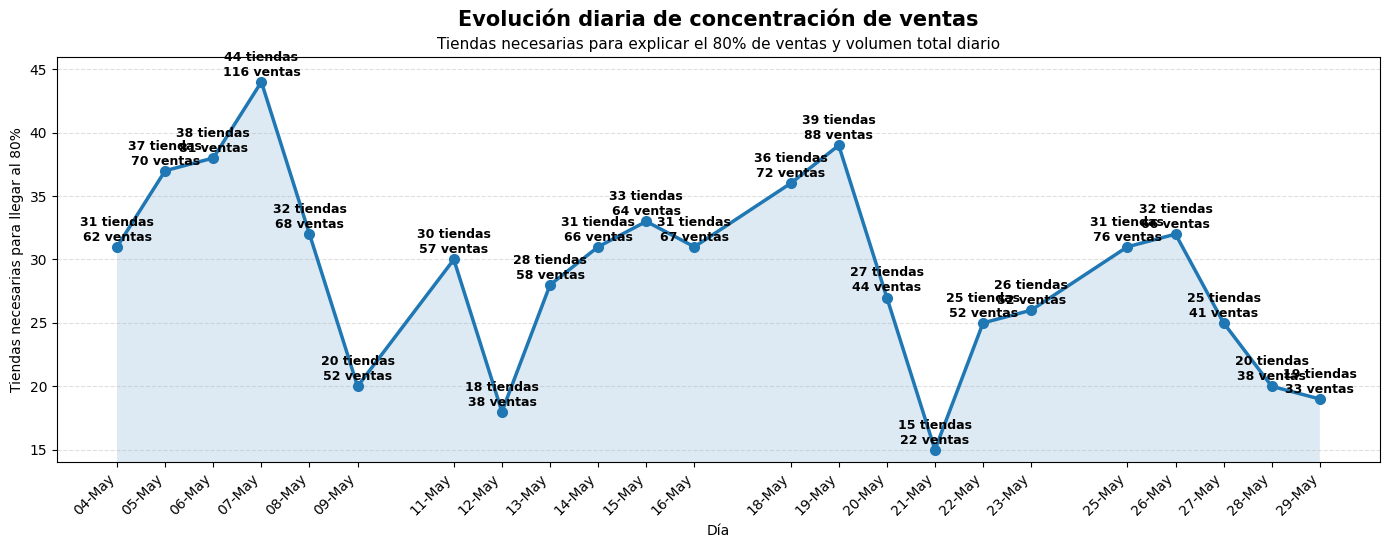

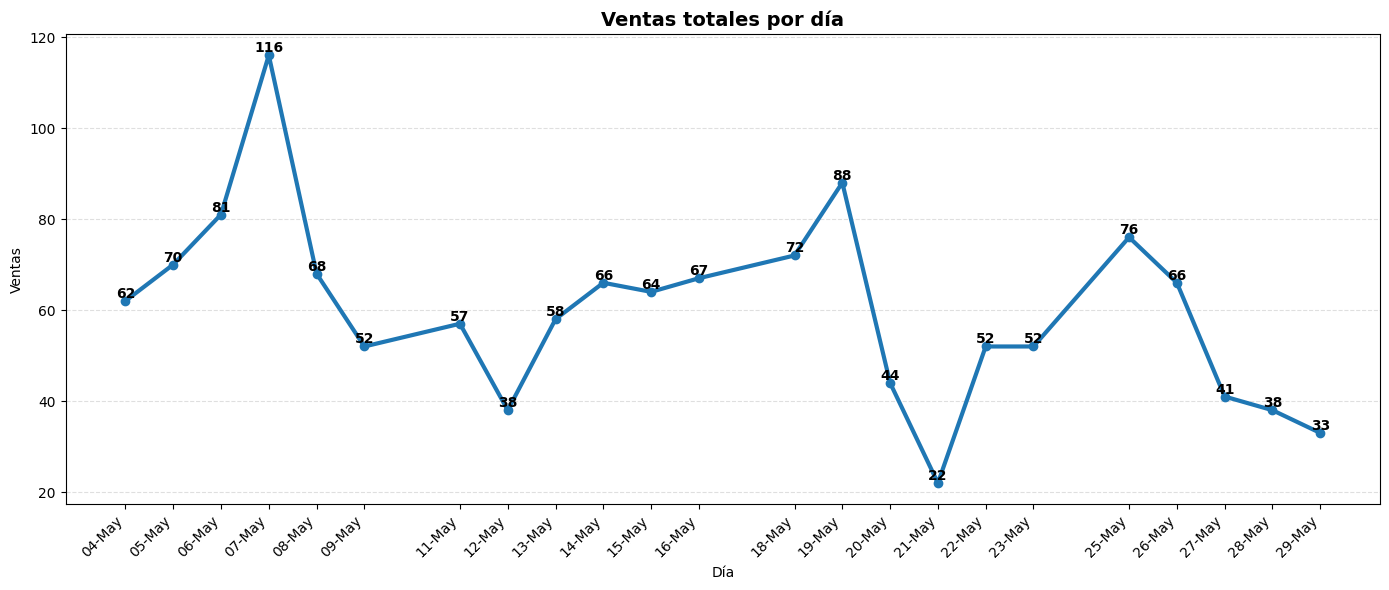

RESUMEN EVOLUCIÓN VENTAS DIARIAS
Día inicial: 2026-05-04
Día actual: 2026-05-29
Tiendas para explicar 80%: 31 → 19
Variación tiendas: -12
Ventas totales: 62 → 33
Variación ventas: -29


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# =====================================================
# CONFIGURACIÓN
# =====================================================
COL_FECHA = "FECHA_VENTA"
COL_VALOR = "VENTA"
COL_TIENDA = "TIENDA_IR"

# =====================================================
# 1) PREPARAR DATA DIARIA EN PYSPARK
# =====================================================
df_base_ventas = (
    df_ref
    .withColumn(COL_FECHA, F.to_date(F.col(COL_FECHA)))
    .withColumn("dia", F.to_date(F.col(COL_FECHA)))
    .withColumn(
        COL_TIENDA,
        F.when(F.col(COL_TIENDA).isNull(), F.lit("SIN_TIENDA"))
         .otherwise(F.col(COL_TIENDA))
    )
)

df_dia_ventas = (
    df_base_ventas
    .groupBy("dia", COL_TIENDA)
    .agg(F.sum(COL_VALOR).alias("ventas"))
)

df_pd_ventas = df_dia_ventas.toPandas()

# =====================================================
# 2) LIMPIEZA EN PANDAS
# =====================================================
df_pd_ventas[COL_TIENDA] = df_pd_ventas[COL_TIENDA].fillna("SIN_TIENDA")
df_pd_ventas["ventas"] = pd.to_numeric(df_pd_ventas["ventas"], errors="coerce").fillna(0)
df_pd_ventas["dia"] = pd.to_datetime(df_pd_ventas["dia"])

df_pd_ventas = df_pd_ventas[
    (df_pd_ventas["dia"].notna()) &
    (df_pd_ventas["ventas"] > 0)
].copy()

# =====================================================
# 3) CALCULAR PARETO POR DÍA
# =====================================================
df_pd_ventas = df_pd_ventas.sort_values(
    ["dia", "ventas"],
    ascending=[True, False]
).reset_index(drop=True)

df_pd_ventas["total_dia"] = df_pd_ventas.groupby("dia")["ventas"].transform("sum")
df_pd_ventas["pct"] = df_pd_ventas["ventas"] / df_pd_ventas["total_dia"]
df_pd_ventas["pct_acum"] = df_pd_ventas.groupby("dia")["pct"].cumsum()

df_pd_ventas["rank"] = df_pd_ventas.groupby("dia")["ventas"].rank(
    method="first",
    ascending=False
)

# =====================================================
# 4) RESUMEN: TIENDAS QUE EXPLICAN EL 80% DE VENTAS
# =====================================================
df_cruce_80_ventas = (
    df_pd_ventas[df_pd_ventas["pct_acum"] >= 0.8]
    .groupby("dia")
    .head(1)[["dia", "rank", "pct_acum"]]
    .rename(columns={
        "rank": "tiendas_para_80",
        "pct_acum": "pct_acum_80"
    })
)

df_resumen_80_ventas = df_cruce_80_ventas.copy()
df_resumen_80_ventas["tiendas_para_80"] = df_resumen_80_ventas["tiendas_para_80"].astype(int)

print("Resumen 80% de ventas por día:")
display(df_resumen_80_ventas)

# =====================================================
# 5) VENTAS TOTALES POR DÍA
# =====================================================
df_ventas_dia = (
    df_pd_ventas
    .groupby("dia")["ventas"]
    .sum()
    .reset_index(name="ventas_totales")
)

df_graf = df_resumen_80_ventas.merge(
    df_ventas_dia,
    on="dia",
    how="left"
)

df_graf["dia"] = pd.to_datetime(df_graf["dia"])
df_graf = df_graf.sort_values("dia").reset_index(drop=True)

# =====================================================
# 6) GRÁFICO: EVOLUCIÓN DIARIA DE CONCENTRACIÓN
# =====================================================
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    df_graf["dia"],
    df_graf["tiendas_para_80"],
    marker="o",
    linewidth=2.5,
    markersize=7
)

ax.fill_between(
    df_graf["dia"],
    df_graf["tiendas_para_80"],
    df_graf["tiendas_para_80"].min() - 1,
    alpha=0.15
)

for dia_x, tiendas_y, ventas_y in zip(
    df_graf["dia"],
    df_graf["tiendas_para_80"],
    df_graf["ventas_totales"]
):
    ax.text(
        dia_x,
        tiendas_y + 0.25,
        f"{int(tiendas_y)} tiendas\n{ventas_y:,.0f} ventas",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

y_min = df_graf["tiendas_para_80"].min() - 1
y_max = df_graf["tiendas_para_80"].max() + 2
ax.set_ylim(y_min, y_max)

ax.set_title(
    "Evolución diaria de concentración de ventas",
    fontsize=15,
    fontweight="bold",
    pad=22
)

ax.text(
    0.5,
    1.01,
    "Tiendas necesarias para explicar el 80% de ventas y volumen total diario",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11
)

ax.set_xlabel("Día")
ax.set_ylabel("Tiendas necesarias para llegar al 80%")

ax.set_xticks(df_graf["dia"])
ax.set_xticklabels(
    [d.strftime("%d-%b") for d in df_graf["dia"]],
    rotation=45,
    ha="right"
)

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# =====================================================
# 7) GRÁFICO: VENTAS TOTALES POR DÍA
# =====================================================
plt.figure(figsize=(14, 6))

plt.plot(
    df_ventas_dia["dia"],
    df_ventas_dia["ventas_totales"],
    marker="o",
    linewidth=3
)

for x, y in zip(df_ventas_dia["dia"], df_ventas_dia["ventas_totales"]):
    plt.text(
        x,
        y,
        f"{y:,.0f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.title("Ventas totales por día", fontsize=14, fontweight="bold")
plt.xlabel("Día")
plt.ylabel("Ventas")

plt.xticks(
    df_ventas_dia["dia"],
    [d.strftime("%d-%b") for d in df_ventas_dia["dia"]],
    rotation=45,
    ha="right"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# =====================================================
# 8) RESUMEN EJECUTIVO
# =====================================================
primera_fecha = df_graf.iloc[0]
ultima_fecha = df_graf.iloc[-1]

var_tiendas = int(ultima_fecha["tiendas_para_80"] - primera_fecha["tiendas_para_80"])
var_ventas = ultima_fecha["ventas_totales"] - primera_fecha["ventas_totales"]

print("====================================================")
print("RESUMEN EVOLUCIÓN VENTAS DIARIAS")
print("====================================================")
print(f"Día inicial: {primera_fecha['dia'].date()}")
print(f"Día actual: {ultima_fecha['dia'].date()}")
print(f"Tiendas para explicar 80%: {int(primera_fecha['tiendas_para_80'])} → {int(ultima_fecha['tiendas_para_80'])}")
print(f"Variación tiendas: {var_tiendas:+}")
print(f"Ventas totales: {primera_fecha['ventas_totales']:,.0f} → {ultima_fecha['ventas_totales']:,.0f}")
print(f"Variación ventas: {var_ventas:+,.0f}")

In [3]:
print(df_ref.count())
print(df_ref.dropDuplicates(['DNI_CLIENTE']).count())
    

167042
167042


In [4]:
df_ref=df_ref.withColumn('lote_01',F.when(F.col('lote')=='REINGRESO',F.lit('04.BASE REGULAR'))
    .when(F.col('frescura')=='0','02. FRESCURA CERO')
    .when(F.col('grupo_segmento')=='R',F.lit('03.BASE CLIENTE'))
    .when(F.col('lote')=='INVENTARIO','01.INVENTARIO')
    .otherwise(F.lit('04.BASE REGULAR'))
)

In [5]:
df_ref.dropDuplicates(['dni_cliente']).groupBy('lote_01') \
    .count() \
    .orderBy('lote_01') \
    .show(30, truncate=False)

+-----------------+-----+
|lote_01          |count|
+-----------------+-----+
|01.INVENTARIO    |89024|
|02. FRESCURA CERO|9404 |
|03.BASE CLIENTE  |13568|
|04.BASE REGULAR  |55046|
+-----------------+-----+



## ventas

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# =====================================================
# CONFIGURACIÓN
# =====================================================
COL_FECHA = "FECHA_VENTA"
COL_VALOR = "VENTA"
COL_TIENDA = "TIENDA_IR"

top_n = 100


# =====================================================
# 1) PREPARAR DATA SEMANAL EN PYSPARK
# =====================================================

df_base_ventas = (
    df_ref
    .withColumn(COL_FECHA, F.to_date(F.col(COL_FECHA)))
    .withColumn(
        "semana",
        F.date_trunc("week", F.col(COL_FECHA)).cast("date")
    )
    .withColumn(
        COL_TIENDA,
        F.when(F.col(COL_TIENDA).isNull(), F.lit("SIN_TIENDA"))
         .otherwise(F.col(COL_TIENDA))
    )
)

df_semana_ventas = (
    df_base_ventas
    .groupBy("semana", COL_TIENDA)
    .agg(F.sum(COL_VALOR).alias("ventas"))
)

df_pd_ventas = df_semana_ventas.toPandas()

In [7]:



# =====================================================
# 2) LIMPIEZA EN PANDAS
# =====================================================

df_pd_ventas[COL_TIENDA] = df_pd_ventas[COL_TIENDA].fillna("SIN_TIENDA")
df_pd_ventas["ventas"] = pd.to_numeric(df_pd_ventas["ventas"], errors="coerce").fillna(0)
df_pd_ventas["semana"] = pd.to_datetime(df_pd_ventas["semana"])

df_pd_ventas = df_pd_ventas[df_pd_ventas["ventas"] > 0].copy()


# =====================================================
# 3) CALCULAR PARETO POR SEMANA
# =====================================================

df_pd_ventas = df_pd_ventas.sort_values(
    ["semana", "ventas"],
    ascending=[True, False]
).reset_index(drop=True)

df_pd_ventas["total_semana"] = df_pd_ventas.groupby("semana")["ventas"].transform("sum")
df_pd_ventas["pct"] = df_pd_ventas["ventas"] / df_pd_ventas["total_semana"]
df_pd_ventas["pct_acum"] = df_pd_ventas.groupby("semana")["pct"].cumsum()

df_pd_ventas["rank"] = df_pd_ventas.groupby("semana")["ventas"].rank(
    method="first",
    ascending=False
)


# =====================================================
# 4) RESUMEN: TIENDAS QUE EXPLICAN EL 80% DE VENTAS
# =====================================================

df_cruce_80_ventas = (
    df_pd_ventas[df_pd_ventas["pct_acum"] >= 0.8]
    .groupby("semana")
    .head(1)[["semana", "rank", "pct_acum"]]
    .rename(columns={
        "rank": "tiendas_para_80",
        "pct_acum": "pct_acum_80"
    })
)

df_resumen_80_ventas = df_cruce_80_ventas.copy()
df_resumen_80_ventas["tiendas_para_80"] = df_resumen_80_ventas["tiendas_para_80"].astype(int)

print("Resumen 80% de ventas por semana:")
display(df_resumen_80_ventas)



Resumen 80% de ventas por semana:


,semana,tiendas_para_80,pct_acum_80
56,2026-05-04,57,0.805869


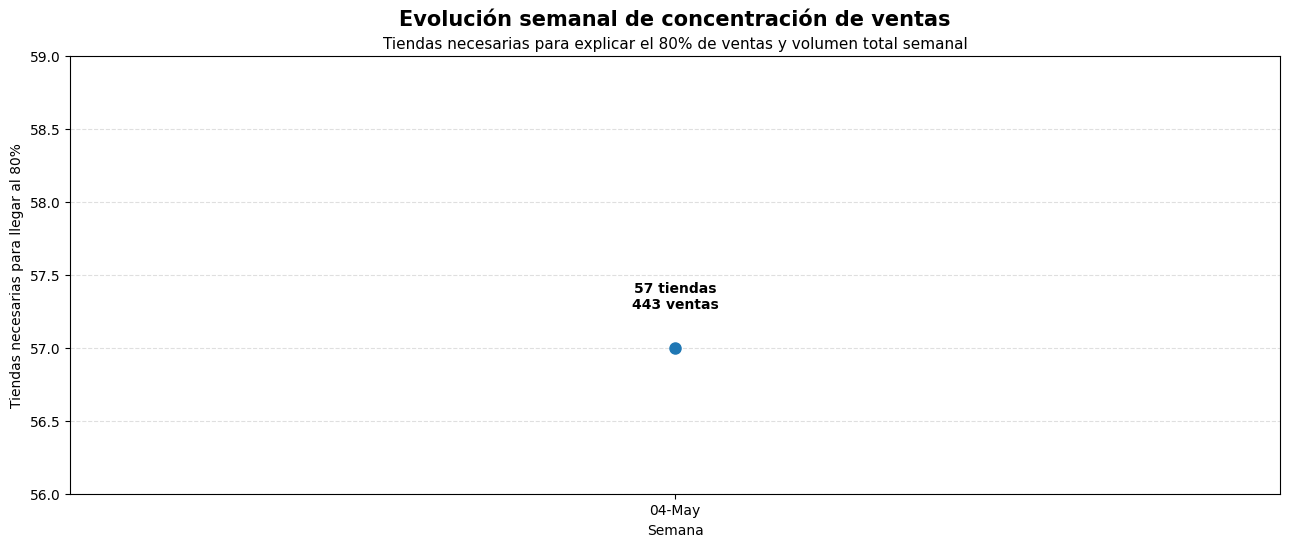

RESUMEN EVOLUCIÓN VENTAS
Semana inicial: 2026-05-04
Semana actual: 2026-05-04
Tiendas para explicar 80%: 57 → 57
Variación tiendas: +0
Ventas totales: 443 → 443
Variación ventas: +0


In [8]:
# =====================================================
# 5) GRÁFICO: EVOLUCIÓN SEMANAL DE CONCENTRACIÓN DE VENTAS + VENTAS TOTALES
# =====================================================

# 5.1) Ventas totales por semana
df_ventas_semana = (
    df_pd_ventas
    .groupby("semana")["ventas"]
    .sum()
    .reset_index(name="ventas_totales")
)

# 5.2) Unir tiendas para 80% + ventas totales
df_graf = df_resumen_80_ventas.merge(
    df_ventas_semana,
    on="semana",
    how="left"
)

df_graf["semana"] = pd.to_datetime(df_graf["semana"])

# 5.3) Gráfico
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    df_graf["semana"],
    df_graf["tiendas_para_80"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

ax.fill_between(
    df_graf["semana"],
    df_graf["tiendas_para_80"],
    df_graf["tiendas_para_80"].min() - 1,
    alpha=0.15
)

# Etiquetas: tiendas + ventas totales
for semana_x, tiendas_y, ventas_y in zip(
    df_graf["semana"],
    df_graf["tiendas_para_80"],
    df_graf["ventas_totales"]
):
    ax.text(
        semana_x,
        tiendas_y + 0.25,
        f"{int(tiendas_y)} tiendas\n{ventas_y:,.0f} ventas",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Ajustar eje Y
y_min = df_graf["tiendas_para_80"].min() - 1
y_max = df_graf["tiendas_para_80"].max() + 2
ax.set_ylim(y_min, y_max)

# Títulos
ax.set_title(
    "Evolución semanal de concentración de ventas",
    fontsize=15,
    fontweight="bold",
    pad=22
)

ax.text(
    0.5,
    1.01,
    "Tiendas necesarias para explicar el 80% de ventas y volumen total semanal",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11
)

# Ejes
ax.set_xlabel("Semana")
ax.set_ylabel("Tiendas necesarias para llegar al 80%")

ax.set_xticks(df_graf["semana"])
ax.set_xticklabels(
    [d.strftime("%d-%b") for d in df_graf["semana"]],
    rotation=0
)

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


# =====================================================
# 5.4) RESUMEN EJECUTIVO
# =====================================================

primera_semana = df_graf.iloc[0]
ultima_semana = df_graf.iloc[-1]

var_tiendas = int(ultima_semana["tiendas_para_80"] - primera_semana["tiendas_para_80"])
var_ventas = ultima_semana["ventas_totales"] - primera_semana["ventas_totales"]

print("====================================================")
print("RESUMEN EVOLUCIÓN VENTAS")
print("====================================================")
print(f"Semana inicial: {primera_semana['semana'].date()}")
print(f"Semana actual: {ultima_semana['semana'].date()}")
print(f"Tiendas para explicar 80%: {int(primera_semana['tiendas_para_80'])} → {int(ultima_semana['tiendas_para_80'])}")
print(f"Variación tiendas: {var_tiendas:+}")
print(f"Ventas totales: {primera_semana['ventas_totales']:,.0f} → {ultima_semana['ventas_totales']:,.0f}")
print(f"Variación ventas: {var_ventas:+,.0f}")

In [ ]:
asssss

Resumen 80% de ventas por día:


,dia,tiendas_para_80,pct_acum_80
30,2026-05-04,31,0.806452
79,2026-05-05,37,0.814286
130,2026-05-06,38,0.802469
190,2026-05-07,44,0.801724
245,2026-05-08,32,0.808824
277,2026-05-09,19,0.804348


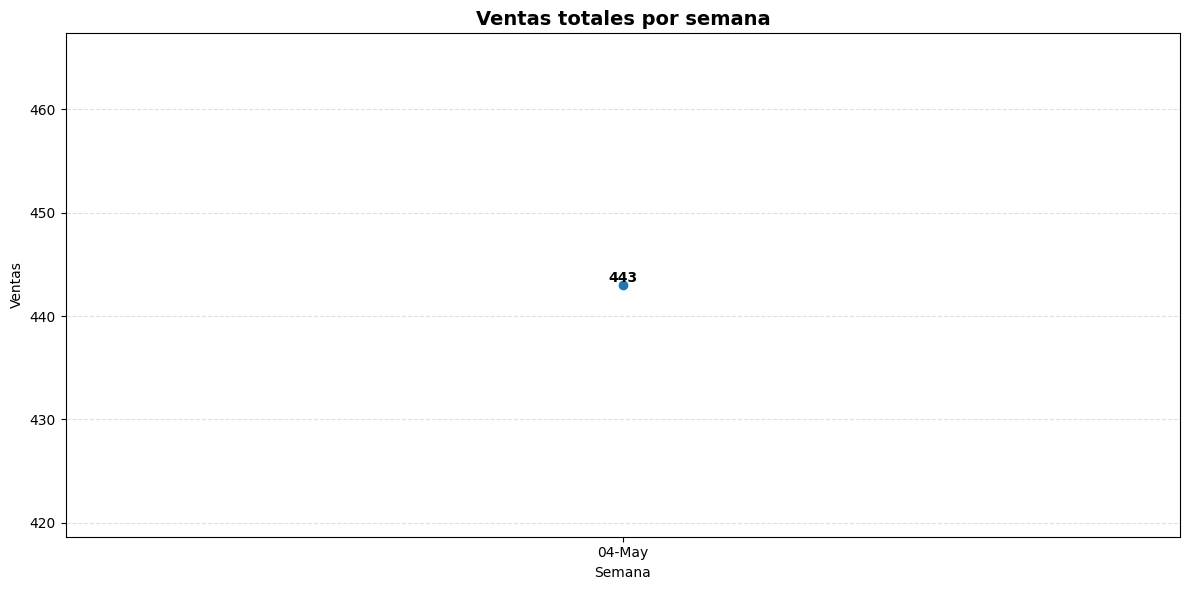

In [9]:
plt.figure(figsize=(12,6))

plt.plot(
    df_ventas_semana["semana"],
    df_ventas_semana["ventas_totales"],
    marker="o",
    linewidth=3
)

for x, y in zip(df_ventas_semana["semana"], df_ventas_semana["ventas_totales"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontweight="bold")

plt.title("Ventas totales por semana", fontsize=14, fontweight="bold")
plt.xlabel("Semana")
plt.ylabel("Ventas")

plt.xticks(df_ventas_semana["semana"],
           [d.strftime("%d-%b") for d in df_ventas_semana["semana"]])

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

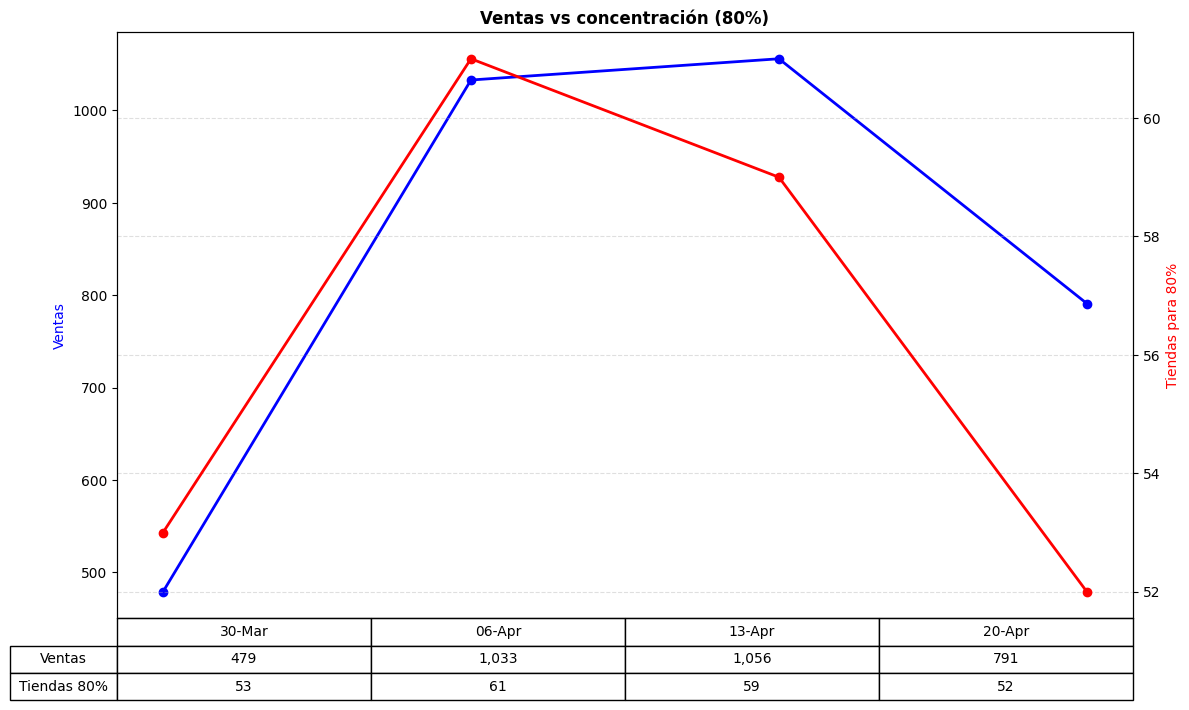

In [96]:
fig, ax1 = plt.subplots(figsize=(12,7))

# =========================
# GRÁFICO
# =========================

# ventas
ax1.plot(
    df_ventas_semana["semana"],
    df_ventas_semana["ventas_totales"],
    color="blue",
    marker="o",
    linewidth=2,
    label="Ventas"
)
ax1.set_ylabel("Ventas", color="blue")

# tiendas
ax2 = ax1.twinx()
ax2.plot(
    df_graf["semana"],
    df_graf["tiendas_para_80"],
    color="red",
    marker="o",
    linewidth=2,
    label="Tiendas 80%"
)
ax2.set_ylabel("Tiendas para 80%", color="red")

# formato eje X
fechas = df_graf["semana"]
labels = [d.strftime("%d-%b") for d in fechas]

ax1.set_xticks(fechas)
ax1.set_xticklabels(labels)

plt.title("Ventas vs concentración (80%)", fontweight="bold")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)

# =========================
# TABLA ABAJO 🔥
# =========================

# preparar datos tabla
tabla = [
    [f"{v:,.0f}" for v in df_ventas_semana["ventas_totales"]],
    [f"{int(t)}" for t in df_graf["tiendas_para_80"]]
]

filas = ["Ventas", "Tiendas 80%"]

# agregar tabla
table = plt.table(
    cellText=tabla,
    rowLabels=filas,
    colLabels=labels,
    cellLoc="center",
    rowLoc="center",
    loc="bottom"
)

# tamaño tabla
table.scale(1, 1.5)

# ajustar espacio
plt.subplots_adjust(bottom=0.25)

plt.tight_layout()
plt.show()

,semana,tiendas_para_80,pct_acum_80,ventas_totales,total_tiendas,tiendas_20,pct_tiendas_80,pct_tiendas_20
0,2026-03-30,53,0.805846,479,101,48,0.524752,0.475248
1,2026-04-06,61,0.802517,1033,108,47,0.564815,0.435185
2,2026-04-13,59,0.805871,1056,107,48,0.551402,0.448598
3,2026-04-20,52,0.800253,791,101,49,0.514851,0.485149


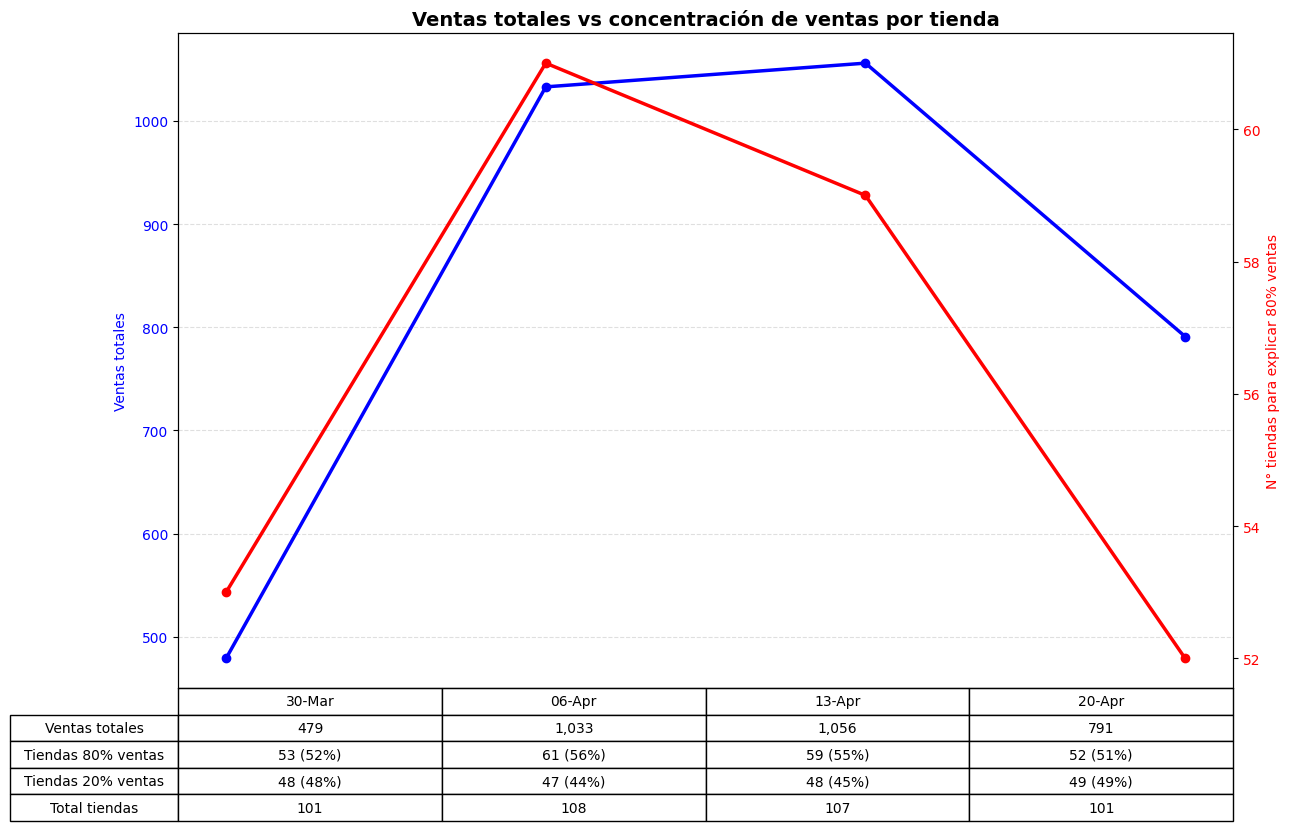

RESUMEN EJECUTIVO
Semana inicial: 2026-03-30
Semana actual: 2026-04-20
Ventas totales: 479 → 791
Tiendas que explican el 80%: 53 → 52
Tiendas que explican el 20% restante: 48 → 49
Total tiendas: 101 → 101


In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# BASES NECESARIAS:
# df_pd_ventas debe tener:
# semana, TIENDA_IR, ventas, pct, pct_acum, rank
# =====================================================

# =====================================================
# 1) VENTAS TOTALES POR SEMANA
# =====================================================

df_ventas_semana = (
    df_pd_ventas
    .groupby("semana")["ventas"]
    .sum()
    .reset_index(name="ventas_totales")
)

# =====================================================
# 2) TIENDAS QUE EXPLICAN EL 80% DE VENTAS
# =====================================================

df_resumen_80_ventas = (
    df_pd_ventas[df_pd_ventas["pct_acum"] >= 0.8]
    .groupby("semana")
    .head(1)[["semana", "rank", "pct_acum"]]
    .rename(columns={
        "rank": "tiendas_para_80",
        "pct_acum": "pct_acum_80"
    })
)

df_resumen_80_ventas["tiendas_para_80"] = (
    df_resumen_80_ventas["tiendas_para_80"].astype(int)
)

# =====================================================
# 3) TOTAL DE TIENDAS POR SEMANA
# =====================================================

df_total_tiendas = (
    df_pd_ventas
    .groupby("semana")[COL_TIENDA]
    .nunique()
    .reset_index(name="total_tiendas")
)

# =====================================================
# 4) ARMAR DATA FINAL DEL GRÁFICO
# =====================================================

df_graf = (
    df_resumen_80_ventas
    .merge(df_ventas_semana, on="semana", how="left")
    .merge(df_total_tiendas, on="semana", how="left")
)

df_graf["semana"] = pd.to_datetime(df_graf["semana"])

df_graf["tiendas_20"] = (
    df_graf["total_tiendas"] - df_graf["tiendas_para_80"]
)

df_graf["pct_tiendas_80"] = (
    df_graf["tiendas_para_80"] / df_graf["total_tiendas"]
)

df_graf["pct_tiendas_20"] = (
    df_graf["tiendas_20"] / df_graf["total_tiendas"]
)

df_graf = df_graf.sort_values("semana").reset_index(drop=True)

display(df_graf)

# =====================================================
# 5) GRÁFICO VENTAS VS CONCENTRACIÓN 80%
# =====================================================

fig, ax1 = plt.subplots(figsize=(13, 8))

# -----------------------------
# Línea ventas totales
# -----------------------------
ax1.plot(
    df_graf["semana"],
    df_graf["ventas_totales"],
    color="blue",
    marker="o",
    linewidth=2.5,
    label="Ventas totales"
)

ax1.set_ylabel("Ventas totales", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# -----------------------------
# Línea tiendas 80%
# -----------------------------
ax2 = ax1.twinx()

ax2.plot(
    df_graf["semana"],
    df_graf["tiendas_para_80"],
    color="red",
    marker="o",
    linewidth=2.5,
    label="Tiendas 80%"
)

ax2.set_ylabel("N° tiendas para explicar 80% ventas", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# -----------------------------
# Eje X
# -----------------------------
labels = [d.strftime("%d-%b") for d in df_graf["semana"]]

ax1.set_xticks(df_graf["semana"])
ax1.set_xticklabels(labels)

# -----------------------------
# Título y grid
# -----------------------------
plt.title(
    "Ventas totales vs concentración de ventas por tienda",
    fontsize=14,
    fontweight="bold"
)

ax1.grid(axis="y", linestyle="--", alpha=0.4)

# =====================================================
# 6) TABLA INFERIOR
# =====================================================

tabla = [
    [f"{v:,.0f}" for v in df_graf["ventas_totales"]],
    [
        f"{int(t)} ({p:.0%})"
        for t, p in zip(df_graf["tiendas_para_80"], df_graf["pct_tiendas_80"])
    ],
    [
        f"{int(t)} ({p:.0%})"
        for t, p in zip(df_graf["tiendas_20"], df_graf["pct_tiendas_20"])
    ],
    [f"{int(t)}" for t in df_graf["total_tiendas"]]
]

filas = [
    "Ventas totales",
    "Tiendas 80% ventas",
    "Tiendas 20% ventas",
    "Total tiendas"
]

table = plt.table(
    cellText=tabla,
    rowLabels=filas,
    colLabels=labels,
    cellLoc="center",
    rowLoc="center",
    loc="bottom"
)

table.scale(1, 1.5)

plt.subplots_adjust(bottom=0.32)
plt.tight_layout()
plt.show()

# =====================================================
# 7) RESUMEN EJECUTIVO
# =====================================================

primera = df_graf.iloc[0]
ultima = df_graf.iloc[-1]

print("====================================================")
print("RESUMEN EJECUTIVO")
print("====================================================")
print(f"Semana inicial: {primera['semana'].date()}")
print(f"Semana actual: {ultima['semana'].date()}")
print(f"Ventas totales: {primera['ventas_totales']:,.0f} → {ultima['ventas_totales']:,.0f}")
print(f"Tiendas que explican el 80%: {int(primera['tiendas_para_80'])} → {int(ultima['tiendas_para_80'])}")
print(f"Tiendas que explican el 20% restante: {int(primera['tiendas_20'])} → {int(ultima['tiendas_20'])}")
print(f"Total tiendas: {int(primera['total_tiendas'])} → {int(ultima['total_tiendas'])}")

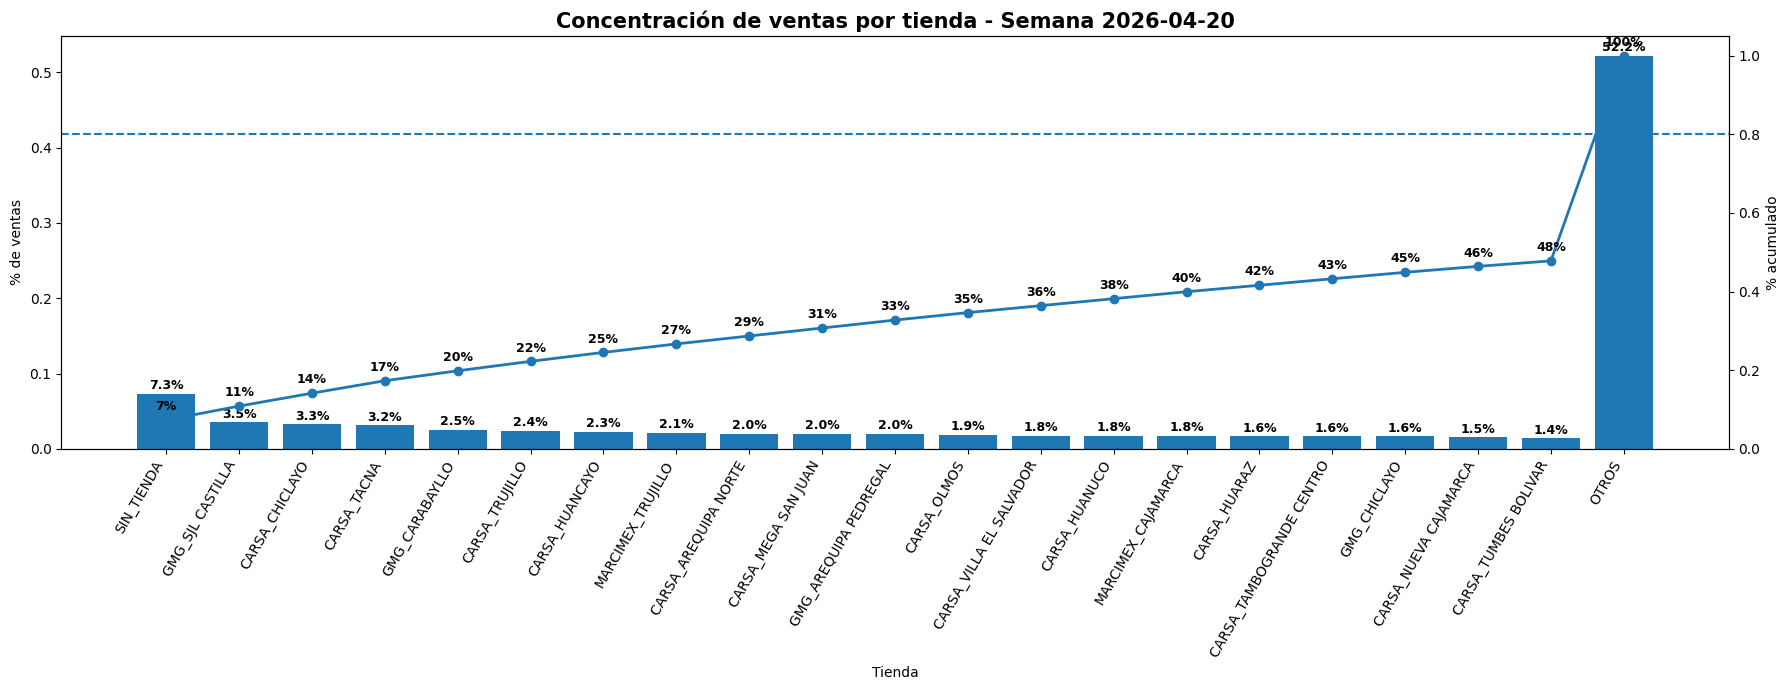

Tiendas que más subieron participación en ventas:


semana,TIENDA_IR,2026-04-13 00:00:00,2026-04-20 00:00:00,variacion_pct
107,SIN_TIENDA,0.043561,0.073325,0.029764
77,CARSA_VILLA EL SALVADOR,0.006629,0.017699,0.011070
67,CARSA_TACNA,0.020833,0.031606,0.010772
87,GMG_HUACHO,0.001894,0.011378,0.009484
26,CARSA_CHICLAYO,0.023674,0.032870,0.009196
56,CARSA_OLMOS,0.010417,0.018963,0.008547
92,GMG_SJL CASTILLA,0.029356,0.035398,0.006042
54,CARSA_NAZCA,0.002841,0.008850,0.006009
28,CARSA_CHIMBOTE AGUIRRE,0.005682,0.011378,0.005696
106,MOTO GO_JAEN,0.008523,0.013906,0.005384


Tiendas que más bajaron participación en ventas:


semana,TIENDA_IR,2026-04-13 00:00:00,2026-04-20 00:00:00,variacion_pct
34,CARSA_HUACHO,0.005682,0.000000,-0.005682
42,CARSA_ICA,0.016098,0.010114,-0.005985
90,GMG_MINKA,0.012311,0.006321,-0.005989
91,GMG_PUENTE PIEDRA,0.012311,0.006321,-0.005989
24,CARSA_CHEPEN,0.008523,0.002528,-0.005994
47,CARSA_JULIACA,0.008523,0.002528,-0.005994
15,CARSA_BARRANCA,0.007576,0.001264,-0.006312
96,GMG_VES,0.014205,0.007585,-0.006619
32,CARSA_COMAS BELAUNDE,0.014205,0.006321,-0.007883
48,CARSA_LA MERCED,0.009470,0.001264,-0.008205


Top 10 tiendas por semana en ventas:


,semana,TIENDA_IR,ventas,pct,pct_acum,rank
0,2026-03-30,SIN_TIENDA,72,0.150313,0.150313,1.0
1,2026-03-30,CARSA_OLMOS,12,0.025052,0.175365,2.0
2,2026-03-30,MARCIMEX_TRUJILLO,11,0.022965,0.198330,3.0
3,2026-03-30,MARCIMEX_HUAMACHUCO,10,0.020877,0.219207,4.0
4,2026-03-30,CARSA_HUANCAYO,10,0.020877,0.240084,5.0
5,2026-03-30,CARSA_AYACUCHO,9,0.018789,0.258873,6.0
6,2026-03-30,MARCIMEX_CAJAMARCA,9,0.018789,0.277662,7.0
7,2026-03-30,CARSA_SECHURA,9,0.018789,0.296451,8.0
8,2026-03-30,CARSA_CAMANA,8,0.016701,0.313152,9.0
9,2026-03-30,CARSA_MOYOBAMBA,8,0.016701,0.329854,10.0


RESUMEN PARA ENVIAR
Semana evaluada: 2026-04-20
52 tiendas explican aproximadamente el 80% de las ventas.
Total de tiendas con ventas: 101
Eso representa el 51.5% del total de tiendas.
Las primeras 20 tiendas concentran el 47.8% de las ventas.
El resto de tiendas concentran el 52.2% de las ventas.


In [98]:


# =====================================================
# 7) TOP 20 TIENDAS + OTROS
# =====================================================

top_detalle = 20

df_sem_actual = (
    df_pd_ventas[df_pd_ventas["semana"] == semana_actual]
    .sort_values("ventas", ascending=False)
    .copy()
)

df_top = df_sem_actual.head(top_detalle).copy()

df_otros = pd.DataFrame({
    COL_TIENDA: ["OTROS"],
    "ventas": [df_sem_actual.iloc[top_detalle:]["ventas"].sum()]
})

df_top_otros = pd.concat(
    [df_top[[COL_TIENDA, "ventas"]], df_otros],
    ignore_index=True
)

df_top_otros["pct"] = df_top_otros["ventas"] / df_top_otros["ventas"].sum()
df_top_otros["pct_acum"] = df_top_otros["pct"].cumsum()

x_pos = np.arange(len(df_top_otros))

fig, ax1 = plt.subplots(figsize=(18, 7))

bars = ax1.bar(
    x_pos,
    df_top_otros["pct"]
)

ax1.set_title(
    f"Concentración de ventas por tienda - Semana {semana_actual.date()}",
    fontsize=15,
    fontweight="bold"
)

ax1.set_ylabel("% de ventas")
ax1.set_xlabel("Tienda")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(
    df_top_otros[COL_TIENDA],
    rotation=60,
    ha="right"
)

for i, bar in enumerate(bars):
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.002,
        f"{h:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

ax2 = ax1.twinx()

ax2.plot(
    x_pos,
    df_top_otros["pct_acum"],
    marker="o",
    linewidth=2
)

ax2.set_ylabel("% acumulado")
ax2.set_ylim(0, 1.05)

for i, y in enumerate(df_top_otros["pct_acum"]):
    ax2.text(
        i,
        y + 0.025,
        f"{y:.0%}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

ax2.axhline(
    0.8,
    linestyle="--",
    linewidth=1.5
)

plt.tight_layout()
plt.show()


# =====================================================
# 8) COMPARACIÓN SEMANA ACTUAL VS SEMANA ANTERIOR
# =====================================================

semanas = sorted(df_pd_ventas["semana"].unique())

if len(semanas) >= 2:
    sem_anterior = semanas[-2]
    sem_actual = semanas[-1]

    df_comp = df_pd_ventas[df_pd_ventas["semana"].isin([sem_anterior, sem_actual])].copy()

    df_pivot = df_comp.pivot_table(
        index=COL_TIENDA,
        columns="semana",
        values="pct",
        fill_value=0
    ).reset_index()

    df_pivot["variacion_pct"] = df_pivot[sem_actual] - df_pivot[sem_anterior]
    df_pivot = df_pivot.sort_values("variacion_pct", ascending=False)

    print("Tiendas que más subieron participación en ventas:")
    display(df_pivot.head(15))

    print("Tiendas que más bajaron participación en ventas:")
    display(df_pivot.tail(15))

else:
    print("Solo hay una semana de información. No se puede comparar contra semana anterior.")


# =====================================================
# 9) TOP 10 VENTAS POR SEMANA
# =====================================================

df_top10_ventas = (
    df_pd_ventas[df_pd_ventas["rank"] <= 10]
    .sort_values(["semana", "rank"])
    [["semana", COL_TIENDA, "ventas", "pct", "pct_acum", "rank"]]
)

print("Top 10 tiendas por semana en ventas:")
display(df_top10_ventas)


# =====================================================
# 10) MENSAJE RESUMEN PARA TU REPORTE
# =====================================================

ultima_semana = df_resumen_80_ventas["semana"].max()

tiendas_80_actual = int(
    df_resumen_80_ventas.loc[
        df_resumen_80_ventas["semana"] == ultima_semana,
        "tiendas_para_80"
    ].iloc[0]
)

total_tiendas_actual = df_pd_ventas[df_pd_ventas["semana"] == ultima_semana][COL_TIENDA].nunique()

pct_top20 = df_top_otros.loc[df_top_otros[COL_TIENDA] != "OTROS", "pct"].sum()
pct_otros = df_top_otros.loc[df_top_otros[COL_TIENDA] == "OTROS", "pct"].iloc[0]

print("====================================================")
print("RESUMEN PARA ENVIAR")
print("====================================================")
print(f"Semana evaluada: {ultima_semana.date()}")
print(f"{tiendas_80_actual} tiendas explican aproximadamente el 80% de las ventas.")
print(f"Total de tiendas con ventas: {total_tiendas_actual}")
print(f"Eso representa el {tiendas_80_actual / total_tiendas_actual:.1%} del total de tiendas.")
print(f"Las primeras {top_detalle} tiendas concentran el {pct_top20:.1%} de las ventas.")
print(f"El resto de tiendas concentran el {pct_otros:.1%} de las ventas.")

## recorrido

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# =====================================================
# CONFIGURACIÓN
# =====================================================
COL_FECHA = "FECHA"        # cambia por tu columna real de fecha
COL_TIENDA = "TIENDA_IR"
COL_VALOR = "RECORRIDO"

top_n = 100


# =====================================================
# 1) PREPARAR DATA SEMANAL EN PYSPARK
# =====================================================

df_base = (
    df_ref
    .withColumn(COL_FECHA, F.to_date(F.col(COL_FECHA)))
    .withColumn(
        "semana",
        F.date_trunc("week", F.col(COL_FECHA)).cast("date")
    )
    .withColumn(
        COL_TIENDA,
        F.when(F.col(COL_TIENDA).isNull(), F.lit("SIN_TIENDA"))
         .otherwise(F.col(COL_TIENDA))
    )
)

df_semana = (
    df_base
    .groupBy("semana", COL_TIENDA)
    .agg(F.sum(COL_VALOR).alias("recorrido"))
)

df_pd = df_semana.toPandas()


# =====================================================
# 2) LIMPIEZA EN PANDAS
# =====================================================

df_pd[COL_TIENDA] = df_pd[COL_TIENDA].fillna("SIN_TIENDA")
df_pd["recorrido"] = pd.to_numeric(df_pd["recorrido"], errors="coerce").fillna(0)
df_pd["semana"] = pd.to_datetime(df_pd["semana"])

df_pd = df_pd[df_pd["recorrido"] > 0].copy()


# =====================================================
# 3) CALCULAR PARETO POR SEMANA
# =====================================================

df_pd = df_pd.sort_values(
    ["semana", "recorrido"],
    ascending=[True, False]
).reset_index(drop=True)

df_pd["total_semana"] = df_pd.groupby("semana")["recorrido"].transform("sum")
df_pd["pct"] = df_pd["recorrido"] / df_pd["total_semana"]
df_pd["pct_acum"] = df_pd.groupby("semana")["pct"].cumsum()

df_pd["rank"] = df_pd.groupby("semana")["recorrido"].rank(
    method="first",
    ascending=False
)


# =====================================================
# 4) RESUMEN: TIENDAS QUE EXPLICAN EL 80%
# =====================================================

df_80 = (
    df_pd[df_pd["pct_acum"] <= 0.8]
    .groupby("semana")
    .size()
    .reset_index(name="tiendas_hasta_80")
)

# Ajuste: sumar 1 tienda adicional para cruzar el 80%
df_cruce_80 = (
    df_pd[df_pd["pct_acum"] >= 0.8]
    .groupby("semana")
    .head(1)[["semana", "rank", "pct_acum"]]
    .rename(columns={
        "rank": "tiendas_para_80",
        "pct_acum": "pct_acum_80"
    })
)

df_resumen_80 = df_cruce_80.copy()
df_resumen_80["tiendas_para_80"] = df_resumen_80["tiendas_para_80"].astype(int)

print("Resumen 80% por semana:")
display(df_resumen_80)




Resumen 80% por semana:


,semana,tiendas_para_80,pct_acum_80
55,2026-03-30,56,0.802615
163,2026-04-06,56,0.800818
268,2026-04-13,53,0.805476
376,2026-04-20,53,0.803740


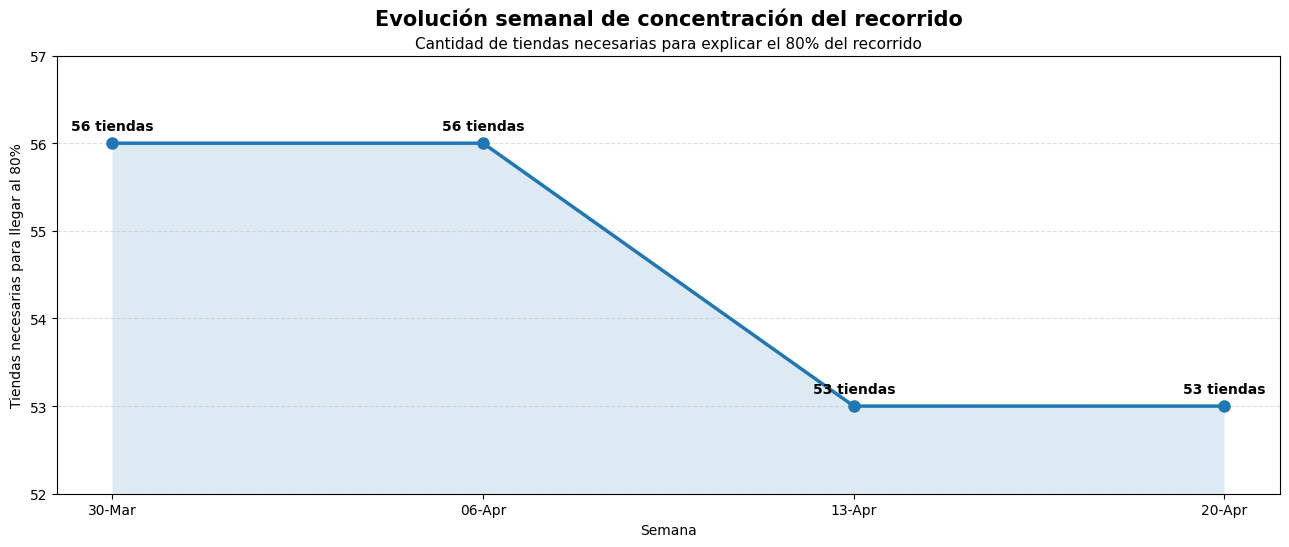

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# =====================================================
# CONFIGURACIÓN
# =====================================================
COL_FECHA = "FECHA"        # cambia por tu columna real de fecha
COL_TIENDA = "TIENDA_IR"
COL_VALOR = "RECORRIDO"

top_n = 100


# =====================================================
# 1) PREPARAR DATA SEMANAL EN PYSPARK
# =====================================================

df_base = (
    df_ref
    .withColumn(COL_FECHA, F.to_date(F.col(COL_FECHA)))
    .withColumn(
        "semana",
        F.date_trunc("week", F.col(COL_FECHA)).cast("date")
    )
    .withColumn(
        COL_TIENDA,
        F.when(F.col(COL_TIENDA).isNull(), F.lit("SIN_TIENDA"))
         .otherwise(F.col(COL_TIENDA))
    )
)

df_semana = (
    df_base
    .groupBy("semana", COL_TIENDA)
    .agg(F.sum(COL_VALOR).alias("recorrido"))
)

df_pd = df_semana.toPandas()


# =====================================================
# 2) LIMPIEZA EN PANDAS
# =====================================================

df_pd[COL_TIENDA] = df_pd[COL_TIENDA].fillna("SIN_TIENDA")
df_pd["recorrido"] = pd.to_numeric(df_pd["recorrido"], errors="coerce").fillna(0)
df_pd["semana"] = pd.to_datetime(df_pd["semana"])

df_pd = df_pd[df_pd["recorrido"] > 0].copy()


# =====================================================
# 3) CALCULAR PARETO POR SEMANA
# =====================================================

df_pd = df_pd.sort_values(
    ["semana", "recorrido"],
    ascending=[True, False]
).reset_index(drop=True)

df_pd["total_semana"] = df_pd.groupby("semana")["recorrido"].transform("sum")
df_pd["pct"] = df_pd["recorrido"] / df_pd["total_semana"]
df_pd["pct_acum"] = df_pd.groupby("semana")["pct"].cumsum()

df_pd["rank"] = df_pd.groupby("semana")["recorrido"].rank(
    method="first",
    ascending=False
)


# =====================================================
# 4) RESUMEN: TIENDAS QUE EXPLICAN EL 80%
# =====================================================

df_80 = (
    df_pd[df_pd["pct_acum"] <= 0.8]
    .groupby("semana")
    .size()
    .reset_index(name="tiendas_hasta_80")
)

# Ajuste: sumar 1 tienda adicional para cruzar el 80%
df_cruce_80 = (
    df_pd[df_pd["pct_acum"] >= 0.8]
    .groupby("semana")
    .head(1)[["semana", "rank", "pct_acum"]]
    .rename(columns={
        "rank": "tiendas_para_80",
        "pct_acum": "pct_acum_80"
    })
)

df_resumen_80 = df_cruce_80.copy()
df_resumen_80["tiendas_para_80"] = df_resumen_80["tiendas_para_80"].astype(int)

print("Resumen 80% por semana:")
display(df_resumen_80)





# =====================================================
# 5) GRÁFICO: EVOLUCIÓN DE TIENDAS PARA LLEGAR AL 80%
# =====================================================

df_graf = df_resumen_80.copy()
df_graf["semana"] = pd.to_datetime(df_graf["semana"])

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    df_graf["semana"],
    df_graf["tiendas_para_80"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

ax.fill_between(
    df_graf["semana"],
    df_graf["tiendas_para_80"],
    df_graf["tiendas_para_80"].min() - 1,
    alpha=0.15
)

for x, y in zip(df_graf["semana"], df_graf["tiendas_para_80"]):
    ax.text(
        x,
        y + 0.12,
        f"{int(y)} tiendas",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

y_min = df_graf["tiendas_para_80"].min() - 1
y_max = df_graf["tiendas_para_80"].max() + 1
ax.set_ylim(y_min, y_max)

ax.set_title(
    "Evolución semanal de concentración del recorrido",
    fontsize=15,
    fontweight="bold",
    pad=22
)

ax.text(
    0.5,
    1.01,
    "Cantidad de tiendas necesarias para explicar el 80% del recorrido",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11
)

ax.set_xlabel("Semana")
ax.set_ylabel("Tiendas necesarias para llegar al 80%")

ax.set_xticks(df_graf["semana"])
ax.set_xticklabels(
    [d.strftime("%d-%b") for d in df_graf["semana"]],
    rotation=0
)

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

,semana,tiendas_para_80,pct_acum_80,recorrido_total,total_tiendas,tiendas_20,pct_tiendas_80,pct_tiendas_20
0,2026-03-30,56,0.802615,18127,108,52,0.518519,0.481481
1,2026-04-06,56,0.800818,45210,108,52,0.518519,0.481481
2,2026-04-13,53,0.805476,61869,108,55,0.490741,0.509259
3,2026-04-20,53,0.803740,94757,108,55,0.490741,0.509259


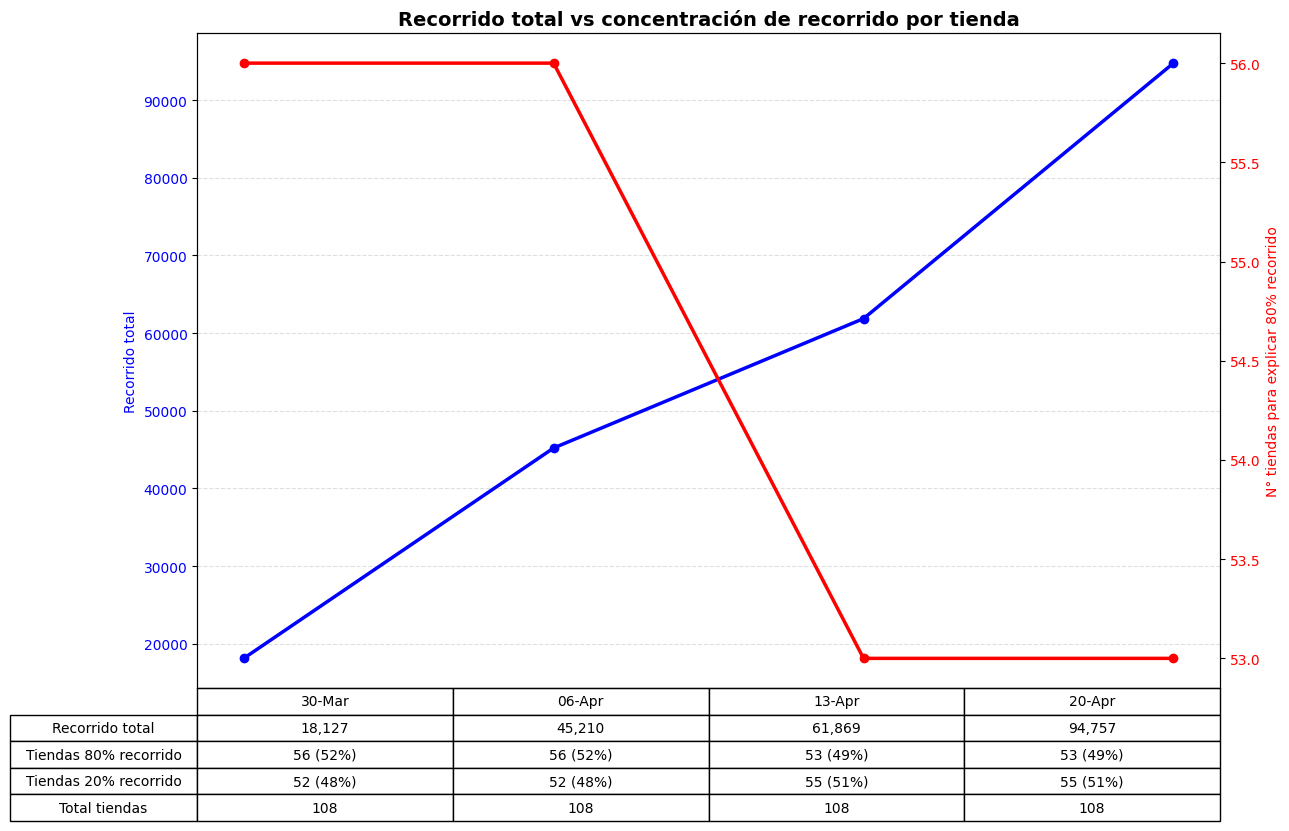

RESUMEN EJECUTIVO - RECORRIDO
Semana inicial: 2026-03-30
Semana actual: 2026-04-20
Recorrido total: 18,127 → 94,757
Tiendas que explican el 80%: 56 → 53
Tiendas que explican el 20% restante: 52 → 55
Total tiendas: 108 → 108


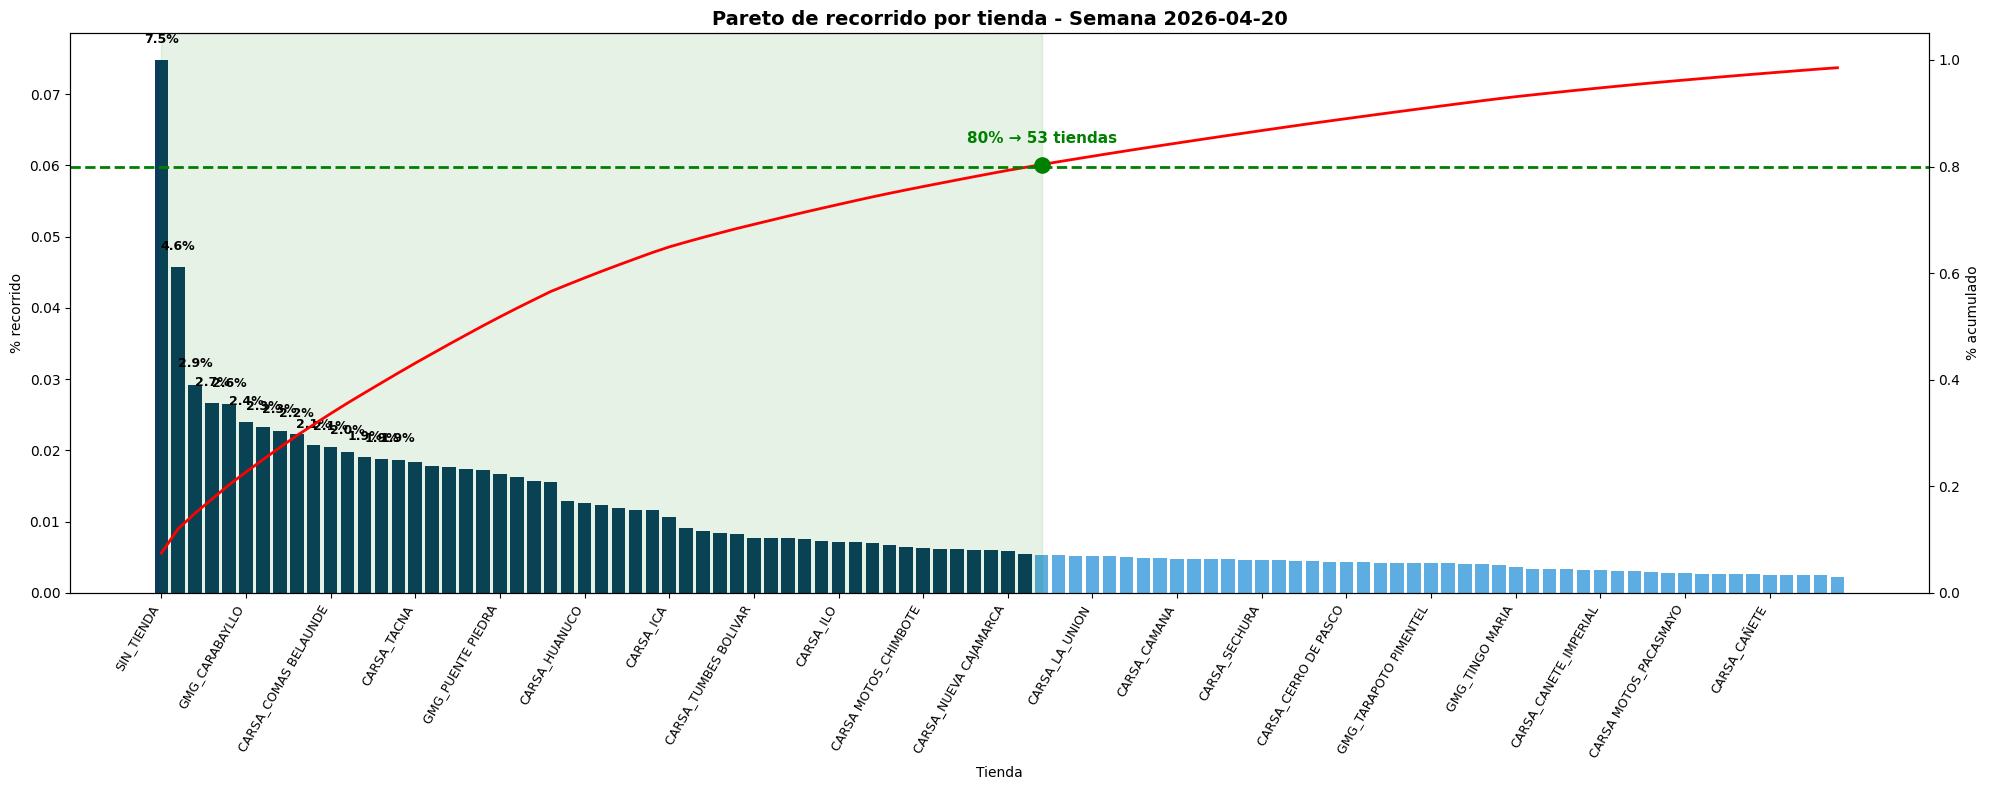

In [58]:
# =====================================================
# 6) PARETO DE LA ÚLTIMA SEMANA
# =====================================================

semana_actual = df_pd["semana"].max()

df_plot = (
    df_pd[df_pd["semana"] == semana_actual]
    .sort_values("recorrido", ascending=False)
    .head(top_n)
    .copy()
)

x_pos = np.arange(len(df_plot))

bar_colors = [
    "#0B3C5D" if y <= 0.8 else "#5DADE2"
    for y in df_plot["pct_acum"]
]

fig, ax1 = plt.subplots(figsize=(20, 8))

bars = ax1.bar(x_pos, df_plot["pct"], color=bar_colors)

ax1.set_ylabel("% recorrido")
ax1.set_xlabel("Tienda")

step = max(1, len(df_plot) // 20)

ax1.set_xticks(x_pos[::step])
ax1.set_xticklabels(
    df_plot[COL_TIENDA].iloc[::step],
    rotation=60,
    ha="right",
    fontsize=9
)

for i, bar in enumerate(bars):
    if i < 15:
        h = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.002,
            f"{h:.1%}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

ax2 = ax1.twinx()
ax2.plot(x_pos, df_plot["pct_acum"], color="red", linewidth=2)

ax2.set_ylim(0, 1.05)
ax2.set_ylabel("% acumulado")

ax2.axhline(0.8, color="green", linestyle="--", linewidth=2)

idx_80 = np.argmax(df_plot["pct_acum"].values >= 0.8)

ax2.scatter(
    x_pos[idx_80],
    df_plot["pct_acum"].iloc[idx_80],
    color="green",
    s=120,
    zorder=5
)

ax2.text(
    x_pos[idx_80],
    df_plot["pct_acum"].iloc[idx_80] + 0.04,
    f"80% → {idx_80 + 1} tiendas",
    ha="center",
    fontsize=11,
    fontweight="bold",
    color="green"
)

ax1.axvspan(0, idx_80, alpha=0.1, color="green")

plt.title(
    f"Pareto de recorrido por tienda - Semana {semana_actual.date()}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [60]:

# =====================================================
# 7) COMPARACIÓN SEMANA ACTUAL VS SEMANA ANTERIOR
# =====================================================

semanas = sorted(df_pd["semana"].unique())

if len(semanas) >= 2:
    sem_anterior = semanas[-2]
    sem_actual = semanas[-1]

    df_comp = df_pd[df_pd["semana"].isin([sem_anterior, sem_actual])].copy()

    df_pivot = df_comp.pivot_table(
        index=COL_TIENDA,
        columns="semana",
        values="pct",
        fill_value=0
    ).reset_index()

    df_pivot["variacion_pct"] = df_pivot[sem_actual] - df_pivot[sem_anterior]

    df_pivot = df_pivot.sort_values("variacion_pct", ascending=False)

    print("Tiendas que más subieron participación:")
    display(df_pivot.head(15))

    print("Tiendas que más bajaron participación:")
    display(df_pivot.tail(15))

else:
    print("Solo hay una semana de información. No se puede comparar contra semana anterior.")


# =====================================================
# 8) TOP 10 POR SEMANA
# =====================================================

df_top10 = (
    df_pd[df_pd["rank"] <= 10]
    .sort_values(["semana", "rank"])
    [["semana", COL_TIENDA, "recorrido", "pct", "pct_acum", "rank"]]
)

print("Top 10 tiendas por semana:")
display(df_top10)


# =====================================================
# 9) MENSAJE RESUMEN PARA TU REPORTE
# =====================================================

ultima_semana = df_resumen_80["semana"].max()
tiendas_80_actual = int(
    df_resumen_80.loc[
        df_resumen_80["semana"] == ultima_semana,
        "tiendas_para_80"
    ].iloc[0]
)

total_tiendas_actual = df_pd[df_pd["semana"] == ultima_semana][COL_TIENDA].nunique()

print("====================================================")
print("RESUMEN PARA ENVIAR")
print("====================================================")
print(f"Semana evaluada: {ultima_semana.date()}")
print(f"{tiendas_80_actual} tiendas explican aproximadamente el 80% del recorrido.")
print(f"Total de tiendas con recorrido: {total_tiendas_actual}")
print(f"Eso representa el {tiendas_80_actual / total_tiendas_actual:.1%} del total de tiendas.")

Tiendas que más subieron participación:


semana,TIENDA_IR,2026-04-13 00:00:00,2026-04-20 00:00:00,variacion_pct
107,SIN_TIENDA,0.046566,0.074802,0.028236
67,CARSA_TACNA,0.013496,0.018342,0.004845
77,CARSA_VILLA EL SALVADOR,0.016309,0.019059,0.002751
12,CARSA_AREQUIPA NORTE,0.026588,0.029254,0.002665
74,CARSA_TRUJILLO,0.019832,0.022289,0.002456
95,GMG_VENTANILLA,0.005980,0.008242,0.002262
105,MOTO GO_CUSCO HONDA,0.009407,0.011598,0.002191
30,CARSA_CHULUCANAS,0.006950,0.008738,0.001788
84,GMG_CHICLAYO,0.014013,0.015746,0.001732
33,CARSA_CUSCO CENTRO,0.011233,0.012875,0.001642


Tiendas que más bajaron participación:


semana,TIENDA_IR,2026-04-13 00:00:00,2026-04-20 00:00:00,variacion_pct
4,CARSA MOTOS_PUCALLPA,0.005706,0.004095,-0.001611
56,CARSA_OLMOS,0.013981,0.012358,-0.001623
44,CARSA_IQUITOS,0.005835,0.004179,-0.001656
1,CARSA MOTOS_IQUITOS,0.005980,0.004095,-0.001886
20,CARSA_CASAGRANDE,0.006255,0.004337,-0.001918
31,CARSA_COMAS,0.021901,0.019830,-0.002071
42,CARSA_ICA,0.012834,0.010606,-0.002227
47,CARSA_JULIACA,0.007096,0.004855,-0.002241
104,MARCIMEX_TRUJILLO,0.024229,0.020748,-0.003481
91,GMG_PUENTE PIEDRA,0.021707,0.016695,-0.005012


Top 10 tiendas por semana:


,semana,TIENDA_IR,recorrido,pct,pct_acum,rank
0,2026-03-30,SIN_TIENDA,972,0.053622,0.053622,1.0
1,2026-03-30,GMG_SJL CASTILLA,698,0.038506,0.092128,2.0
2,2026-03-30,CARSA_AREQUIPA NORTE,575,0.031721,0.123848,3.0
3,2026-03-30,CARSA_HUANCAYO,547,0.030176,0.154024,4.0
4,2026-03-30,CARSA_OLMOS,432,0.023832,0.177856,5.0
5,2026-03-30,CARSA_TRUJILLO,409,0.022563,0.200419,6.0
6,2026-03-30,GMG_VMT,396,0.021846,0.222265,7.0
7,2026-03-30,MARCIMEX_TRUJILLO,390,0.021515,0.243780,8.0
8,2026-03-30,CARSA_AYACUCHO,371,0.020467,0.264247,9.0
9,2026-03-30,CARSA_MEGA SAN JUAN,362,0.019970,0.284217,10.0


RESUMEN PARA ENVIAR
Semana evaluada: 2026-04-20
53 tiendas explican aproximadamente el 80% del recorrido.
Total de tiendas con recorrido: 108
Eso representa el 49.1% del total de tiendas.


In [64]:
query=f'''
    select
    *
    from cronox.dbo.borrar_alfcc_reporte_sql
    where FECHA>='2026-04-01'
'''
df_ref = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

print(df_ref.columns)

['DNI_CLIENTE', 'LOTE', 'EJECUTIVO', 'TIPIFICACION', 'TODO', 'RECORRIDO', 'CEF', 'CNE', 'NOC', 'SG', 'DNOG', 'DGEST', 'INTENTOS_DISC', 'INTENTOS', 'I_CET', 'I_NCET', 'VENTA', 'Semana', 'FECHA', 'HORA', 'MODALIDAD', 'CELULAR', 'NIVEL_1', 'NIVEL_2', 'CAMPAÑA', 'OFERTA_ACEPTADA', 'estado_venta', 'FECHA_VENTA', 'PROVEEDOR', 'ESTADO_CLIENTE', 'ALTA_DEMANDA_PRIORIZADO', 'VENTA_DESEMBOLSADO', 'MONTO_DESEMBOLSADO', 'RANGO_MONTO_OFERTA_CREDICASH', 'RANGO_MONTO_TARGET_OFERTA_ELECTRO', 'NOMBRE_COMPLETO', 'OBS_FCC', 'SEMAFORO', 'REGION', 'TIENDA_IR', 'PERFIL', 'PLAZO', 'TASA', 'CME_DISPONIBLE', 'SCORE_TELEFONO', 'MARCA_PD', 'MSI', 'FLG_CREDICASH', 'GRUPO_SEGMENTO', 'PRODUCTO_EXTERNO', 'PROPENSION_ELECTRO', 'PROPENSION_CREDICASH', 'FLG_CRUCE_RECURRENTE', 'ALTA_DEMANDA', 'DEMANDA', 'PRIORIDAD', 'FRESCURA', 'INTENSIDAD_MAX', 'ORIGEN_CELULAR', 'FLG_AAHH']


In [ ]:
['DNI_CLIENTE', 'LOTE', 'EJECUTIVO', 'TIPIFICACION', 'TODO', 'RECORRIDO', 'CEF', 'CNE', 'NOC', 'SG', 'DNOG', 'DGEST', 'INTENTOS_DISC', 'INTENTOS', 'I_CET', 'I_NCET', 'VENTA', 'Semana', 'FECHA', 'HORA', 'MODALIDAD', 'CELULAR', 'NIVEL_1', 'NIVEL_2', 'CAMPAÑA', 'OFERTA_ACEPTADA', 'estado_venta', 'FECHA_VENTA', 'PROVEEDOR', 'ESTADO_CLIENTE', 'ALTA_DEMANDA_PRIORIZADO', 'VENTA_DESEMBOLSADO', 'MONTO_DESEMBOLSADO', 'RANGO_MONTO_OFERTA_CREDICASH', 'RANGO_MONTO_TARGET_OFERTA_ELECTRO', 'NOMBRE_COMPLETO', 'OBS_FCC', 'SEMAFORO', 'REGION', 'TIENDA_IR', 'PERFIL', 'PLAZO', 'TASA', 'CME_DISPONIBLE', 'SCORE_TELEFONO', 'MARCA_PD', 'MSI', 'FLG_CREDICASH', 'GRUPO_SEGMENTO', 'PRODUCTO_EXTERNO', 'PROPENSION_ELECTRO', 'PROPENSION_CREDICASH', 'FLG_CRUCE_RECURRENTE', 'ALTA_DEMANDA', 'DEMANDA', 'PRIORIDAD', 'FRESCURA', 'INTENSIDAD_MAX', 'ORIGEN_CELULAR', 'FLG_AAHH']fech


In [ ]:

# =====================================================
# 1) PREPARAR DATA SEMANAL EN PYSPARK
# =====================================================

df_base = (
    df_ref
    .withColumn(COL_FECHA, F.to_date(F.col(COL_FECHA)))
    .withColumn(
        "semana",
        F.date_trunc("week", F.col(COL_FECHA)).cast("date")
    )
    .withColumn(
        COL_TIENDA,
        F.when(F.col(COL_TIENDA).isNull(), F.lit("SIN_TIENDA"))
         .otherwise(F.col(COL_TIENDA))
    )
)


df_semana = (
    df_base
    .groupBy("semana", COL_TIENDA)
    .agg(F.sum(COL_VALOR).alias("recorrido"))
)

df_pd = df_semana.toPandas()

In [49]:
df_ref.groupBy("semana", "TIENDA_IR").agg(F.sum("VENTA").alias("ventas")).show()

+------+--------------------+------+
|semana|           TIENDA_IR|ventas|
+------+--------------------+------+
|     3|       CARSA_MANCHAY|    11|
|     3|CARSA_AREQUIPA NORTE|    18|
|     3|        CARSA_HUARAZ|    12|
|     1|         CARSA_TARMA|     8|
|     1|         CARSA_COMAS|     2|
|     1|      CARSA_AGUAYTIA|     5|
|     3|   GMG_PUENTE PIEDRA|    15|
|     2|       CARSA_MANCHAY|    12|
|     2|     GMG_TINGO MARIA|    13|
|     1|        MARCIMEX_ICA|     7|
|     4|      MARCIMEX_PISCO|     4|
|     1|CARSA_PUERTO MALD...|     5|
|     3|      CARSA_HUANCAYO|    25|
|     2|      GMG_CARABAYLLO|    19|
|     1|CARSA_CHIMBOTE AG...|     1|
|     3|         GMG_CHINCHA|     5|
|     2|    CARSA_YURIMAGUAS|     3|
|     1|      CARSA_LA_UNION|     3|
|     1|    CARSA_CASAGRANDE|     7|
|     2| CARSA_MEGA SAN JUAN|    16|
+------+--------------------+------+
only showing top 20 rows


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# =====================================================
# 1) AGRUPAR VENTAS POR SEMANA Y TIENDA
# =====================================================
df_ventas_tienda = (
    df_ref.groupBy("semana", "TIENDA_IR")
    .agg(F.sum("VENTA").alias("ventas"))
    .toPandas()
)

# =====================================================
# 2) LIMPIEZA
# =====================================================
df_ventas_tienda["semana"] = pd.to_datetime(df_ventas_tienda["semana"])
df_ventas_tienda["TIENDA_IR"] = df_ventas_tienda["TIENDA_IR"].fillna("SIN_TIENDA")
df_ventas_tienda["ventas"] = pd.to_numeric(
    df_ventas_tienda["ventas"], errors="coerce"
).fillna(0)

# =====================================================
# 3) CALCULAR TIENDAS NECESARIAS PARA LLEGAR AL 80%
# =====================================================
resumen = []

for semana, df_sem in df_ventas_tienda.groupby("semana"):

    df_sem = df_sem.sort_values("ventas", ascending=False).reset_index(drop=True)

    total_ventas = df_sem["ventas"].sum()

    if total_ventas == 0:
        tiendas_80 = 0
        ventas_total = 0
        ventas_80 = 0
    else:
        df_sem["pct"] = df_sem["ventas"] / total_ventas
        df_sem["pct_acum"] = df_sem["pct"].cumsum()

        idx_80 = np.argmax(df_sem["pct_acum"].values >= 0.8)

        tiendas_80 = idx_80 + 1
        ventas_total = total_ventas
        ventas_80 = df_sem.loc[:idx_80, "ventas"].sum()

    resumen.append({
        "semana": semana,
        "tiendas_para_80": tiendas_80,
        "ventas_total": ventas_total,
        "ventas_80": ventas_80
    })

df_resumen_80_ventas = pd.DataFrame(resumen).sort_values("semana")

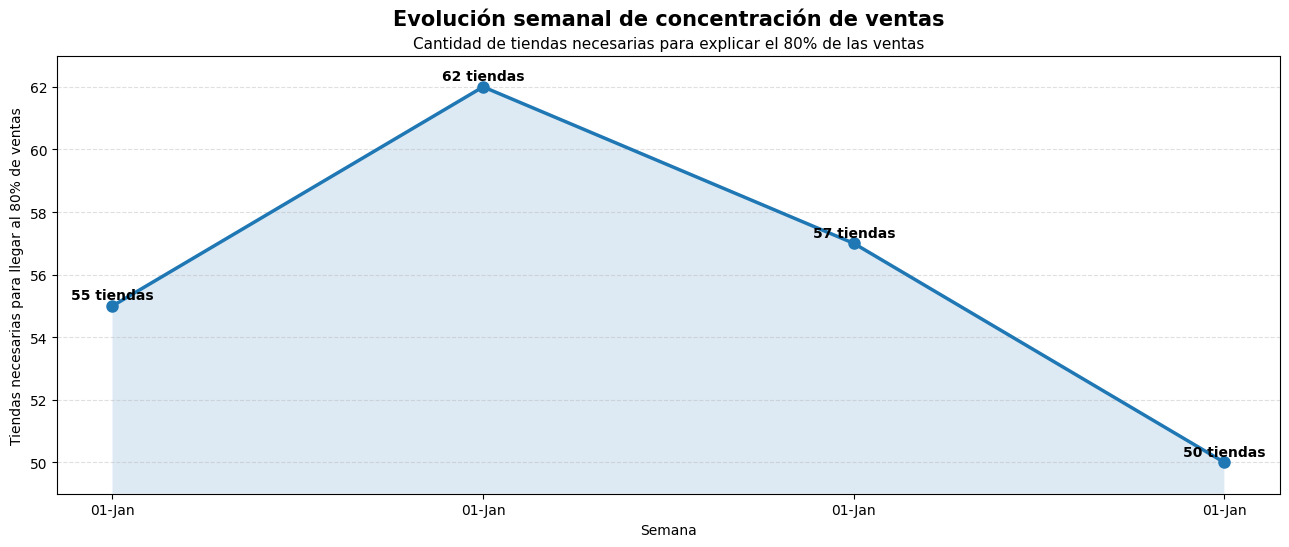

In [45]:
# =====================================================
# 4) GRÁFICO EVOLUCIÓN SEMANAL - VENTAS
# =====================================================
df_graf = df_resumen_80_ventas.copy()

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    df_graf["semana"],
    df_graf["tiendas_para_80"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

ax.fill_between(
    df_graf["semana"],
    df_graf["tiendas_para_80"],
    df_graf["tiendas_para_80"].min() - 1,
    alpha=0.15
)

for x, y in zip(df_graf["semana"], df_graf["tiendas_para_80"]):
    ax.text(
        x,
        y + 0.12,
        f"{int(y)} tiendas",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

y_min = df_graf["tiendas_para_80"].min() - 1
y_max = df_graf["tiendas_para_80"].max() + 1
ax.set_ylim(y_min, y_max)

ax.set_title(
    "Evolución semanal de concentración de ventas",
    fontsize=15,
    fontweight="bold",
    pad=22
)

ax.text(
    0.5,
    1.01,
    "Cantidad de tiendas necesarias para explicar el 80% de las ventas",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11
)

ax.set_xlabel("Semana")
ax.set_ylabel("Tiendas necesarias para llegar al 80% de ventas")

ax.set_xticks(df_graf["semana"])
ax.set_xticklabels(
    [d.strftime("%d-%b") for d in df_graf["semana"]],
    rotation=0
)

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# =====================================================
# CONFIGURACIÓN
# =====================================================
COL_FECHA = "FECHA"        # cambia por tu columna real de fecha
COL_FECHA_venta = "FECHA"        # cambia por tu columna real de fecha
COL_TIENDA = "TIENDA_IR"
COL_VALOR = "RECORRIDO"

top_n = 100


# =====================================================
# 1) PREPARAR DATA SEMANAL EN PYSPARK
# =====================================================

df_base = (
    df_ref
    .withColumn(COL_FECHA, F.to_date(F.col(COL_FECHA)))
    .withColumn(
        "semana",
        F.date_trunc("week", F.col(COL_FECHA)).cast("date")
    )
    .withColumn(
        COL_TIENDA,
        F.when(F.col(COL_TIENDA).isNull(), F.lit("SIN_TIENDA"))
         .otherwise(F.col(COL_TIENDA))
    )
)


df_semana = (
    df_base
    .groupBy("semana", COL_TIENDA)
    .agg(F.sum(COL_VALOR).alias("recorrido"))
)

df_pd = df_semana.toPandas()


# =====================================================
# 2) LIMPIEZA EN PANDAS
# =====================================================

df_pd[COL_TIENDA] = df_pd[COL_TIENDA].fillna("SIN_TIENDA")
df_pd["recorrido"] = pd.to_numeric(df_pd["recorrido"], errors="coerce").fillna(0)
df_pd["semana"] = pd.to_datetime(df_pd["semana"])

df_pd = df_pd[df_pd["recorrido"] > 0].copy()


# =====================================================
# 3) CALCULAR PARETO POR SEMANA
# =====================================================

df_pd = df_pd.sort_values(
    ["semana", "recorrido"],
    ascending=[True, False]
).reset_index(drop=True)

df_pd["total_semana"] = df_pd.groupby("semana")["recorrido"].transform("sum")
df_pd["pct"] = df_pd["recorrido"] / df_pd["total_semana"]
df_pd["pct_acum"] = df_pd.groupby("semana")["pct"].cumsum()

df_pd["rank"] = df_pd.groupby("semana")["recorrido"].rank(
    method="first",
    ascending=False
)


# =====================================================
# 4) RESUMEN: TIENDAS QUE EXPLICAN EL 80%
# =====================================================

df_80 = (
    df_pd[df_pd["pct_acum"] <= 0.8]
    .groupby("semana")
    .size()
    .reset_index(name="tiendas_hasta_80")
)

# Ajuste: sumar 1 tienda adicional para cruzar el 80%
df_cruce_80 = (
    df_pd[df_pd["pct_acum"] >= 0.8]
    .groupby("semana")
    .head(1)[["semana", "rank", "pct_acum"]]
    .rename(columns={
        "rank": "tiendas_para_80",
        "pct_acum": "pct_acum_80"
    })
)

df_resumen_80 = df_cruce_80.copy()
df_resumen_80["tiendas_para_80"] = df_resumen_80["tiendas_para_80"].astype(int)

print("Resumen 80% por semana:")
display(df_resumen_80)



Resumen 80% por semana:


,semana,tiendas_para_80,pct_acum_80
55,2026-03-30,56,0.802615
163,2026-04-06,56,0.800818
268,2026-04-13,53,0.805476
376,2026-04-20,53,0.803740


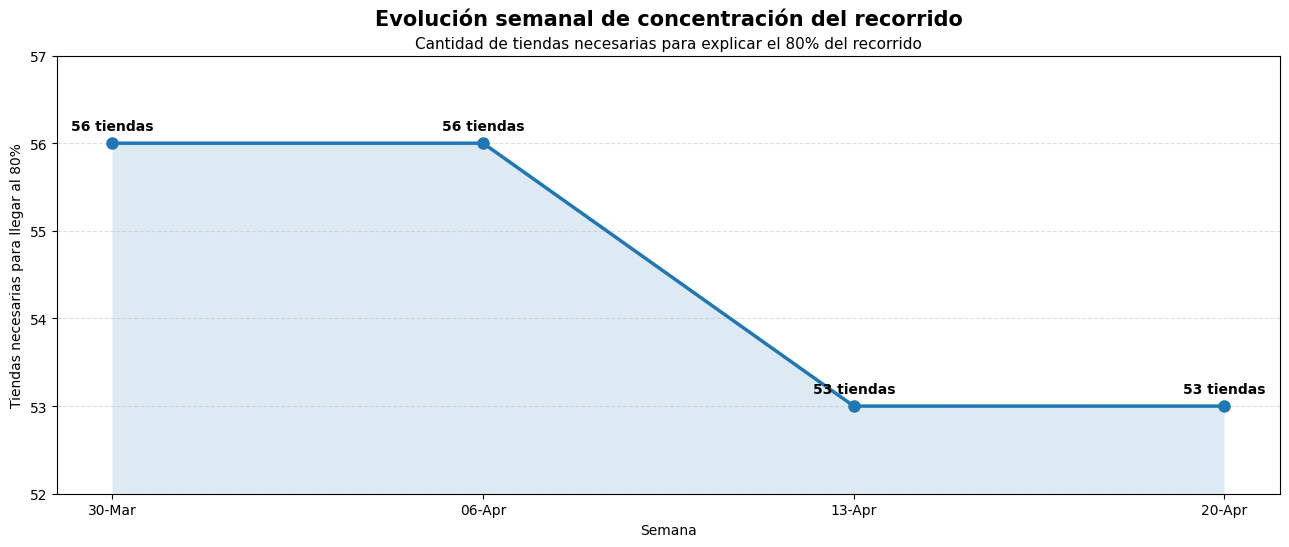

In [31]:
df_graf = df_resumen_80.copy()
df_graf["semana"] = pd.to_datetime(df_graf["semana"])

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    df_graf["semana"],
    df_graf["tiendas_para_80"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

ax.fill_between(
    df_graf["semana"],
    df_graf["tiendas_para_80"],
    df_graf["tiendas_para_80"].min() - 1,
    alpha=0.15
)

for x, y in zip(df_graf["semana"], df_graf["tiendas_para_80"]):
    ax.text(
        x,
        y + 0.12,
        f"{int(y)} tiendas",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

y_min = df_graf["tiendas_para_80"].min() - 1
y_max = df_graf["tiendas_para_80"].max() + 1
ax.set_ylim(y_min, y_max)

ax.set_title(
    "Evolución semanal de concentración del recorrido",
    fontsize=15,
    fontweight="bold",
    pad=22
)

ax.text(
    0.5,
    1.01,
    "Cantidad de tiendas necesarias para explicar el 80% del recorrido",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11
)

ax.set_xlabel("Semana")
ax.set_ylabel("Tiendas necesarias para llegar al 80%")

ax.set_xticks(df_graf["semana"])
ax.set_xticklabels(
    [d.strftime("%d-%b") for d in df_graf["semana"]],
    rotation=0
)

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

En el recorrido hemos mejorado la concentración operativa
ya que ahora  mejor tienda explican el  80% del recorrido 

Teniendo mayor oportunidad en recorrer tiendas de menor aporte.

In [34]:
top_n=60

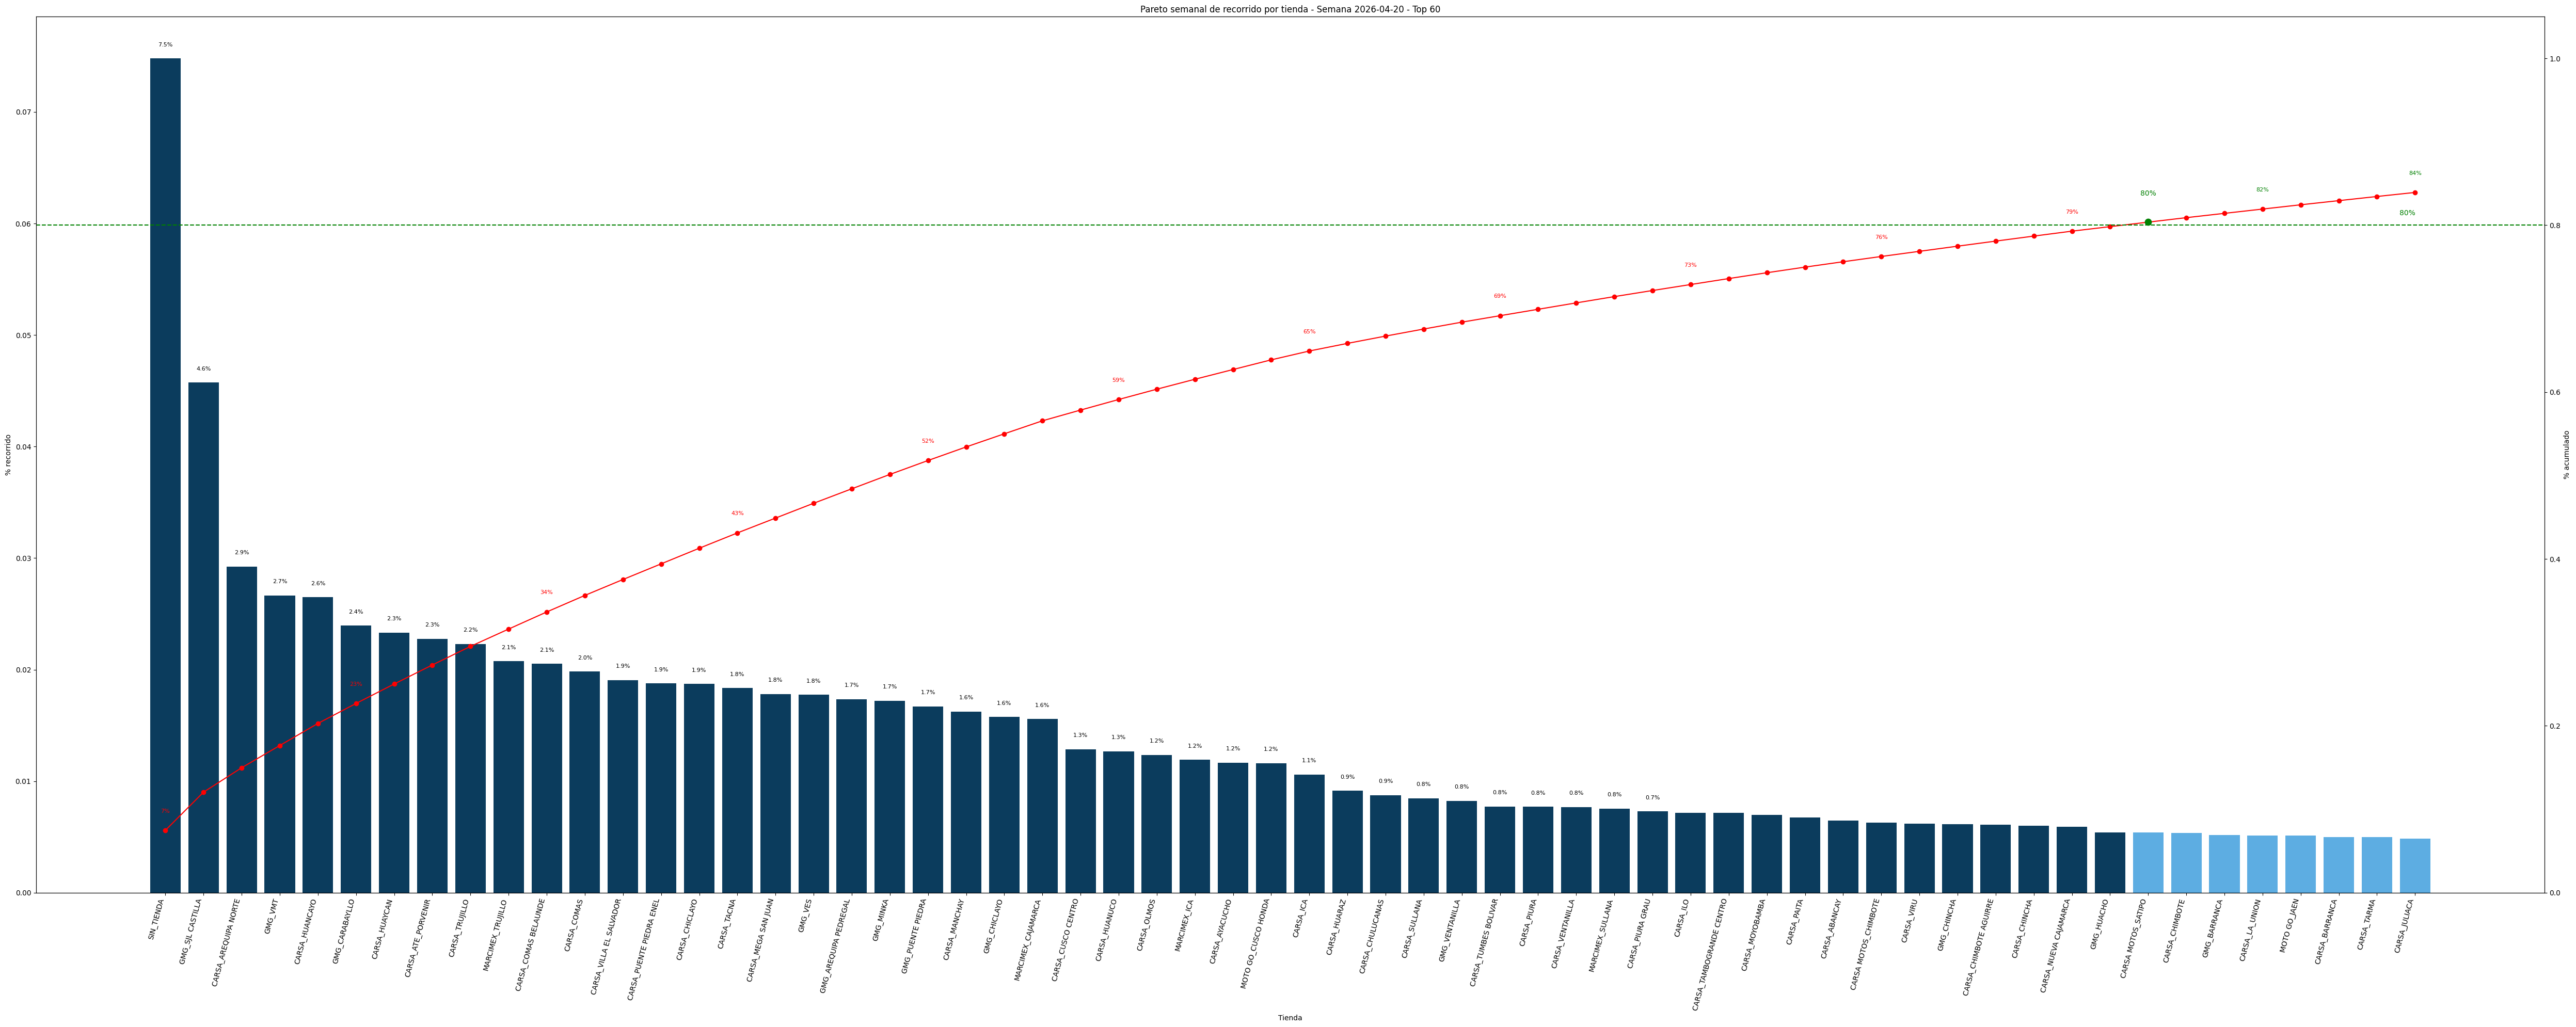

In [37]:



# =====================================================
# 6) PARETO DE LA ÚLTIMA SEMANA
# =====================================================

semana_actual = df_pd["semana"].max()

df_plot = (
    df_pd[df_pd["semana"] == semana_actual]
    .sort_values("recorrido", ascending=False)
    .head(top_n)
    .copy()
)

x = np.arange(len(df_plot))

fig, ax1 = plt.subplots(figsize=(50, 20))

bar_colors = [
    "#0B3C5D" if y <= 0.8 else "#5DADE2"
    for y in df_plot["pct_acum"]
]

bars = ax1.bar(x, df_plot["pct"], color=bar_colors)

ax1.set_ylabel("% recorrido")
ax1.set_xlabel("Tienda")
ax1.set_xticks(x)
ax1.set_xticklabels(df_plot[COL_TIENDA], rotation=75, ha="right")

for i, bar in enumerate(bars):
    if i < 40:
        h = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.001,
            f"{h:.1%}",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax2 = ax1.twinx()
ax2.plot(x, df_plot["pct_acum"], color="red", marker="o", linewidth=1.5)
ax2.set_ylabel("% acumulado")
ax2.set_ylim(0, 1.05)

ax2.axhline(0.8, color="green", linestyle="--", linewidth=1.5)
ax2.text(len(df_plot) - 1, 0.81, "80%", color="green", ha="right", va="bottom")

idx_80 = np.argmax(df_plot["pct_acum"].values >= 0.8)

ax2.scatter(
    x[idx_80],
    df_plot["pct_acum"].iloc[idx_80],
    s=80,
    color="green",
    zorder=5
)

ax2.text(
    x[idx_80],
    df_plot["pct_acum"].iloc[idx_80] + 0.03,
    f"{df_plot['pct_acum'].iloc[idx_80]:.0%}",
    ha="center",
    va="bottom",
    fontsize=10,
    color="green"
)

for i, y in enumerate(df_plot["pct_acum"]):
    if i % 5 == 0 or i == len(df_plot) - 1:
        color_txt = "red" if y <= 0.8 else "green"
        ax2.text(
            i,
            y + 0.02,
            f"{y:.0%}",
            ha="center",
            va="bottom",
            fontsize=8,
            color=color_txt
        )

plt.title(f"Pareto semanal de recorrido por tienda - Semana {semana_actual.date()} - Top {top_n}")
plt.tight_layout()
plt.show()


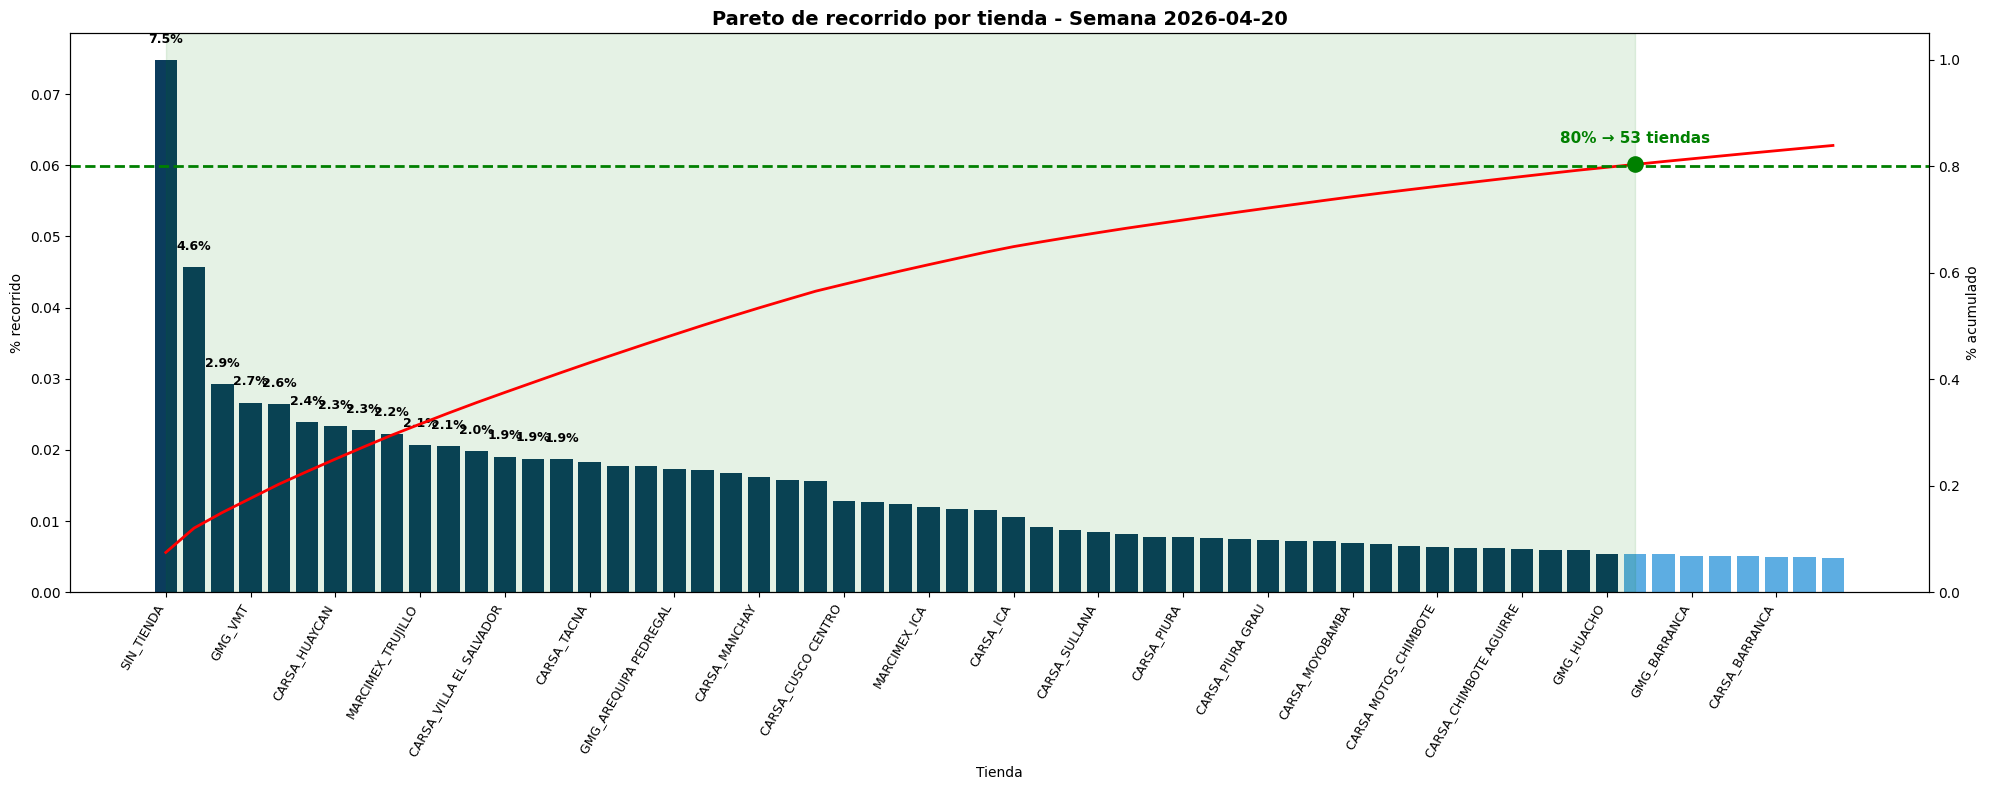

In [38]:
fig, ax1 = plt.subplots(figsize=(20, 8))

# BARRAS
bars = ax1.bar(x, df_plot["pct"], color=bar_colors)

ax1.set_ylabel("% recorrido")
ax1.set_xlabel("Tienda")

# 🔥 reducir etiquetas en X (solo algunas)
step = max(1, len(df_plot)//20)

ax1.set_xticks(x[::step])
ax1.set_xticklabels(
    df_plot[COL_TIENDA].iloc[::step],
    rotation=60,
    ha="right",
    fontsize=9
)

# 🔥 SOLO TOP 15 etiquetas
for i, bar in enumerate(bars):
    if i < 15:
        h = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.002,
            f"{h:.1%}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

# LINEA PARETO
ax2 = ax1.twinx()
ax2.plot(x, df_plot["pct_acum"], color="red", linewidth=2)

ax2.set_ylim(0, 1.05)
ax2.set_ylabel("% acumulado")

# 🔥 Línea 80%
ax2.axhline(0.8, color="green", linestyle="--", linewidth=2)

# 🔥 Punto clave 80%
idx_80 = np.argmax(df_plot["pct_acum"].values >= 0.8)

ax2.scatter(
    x[idx_80],
    df_plot["pct_acum"].iloc[idx_80],
    color="green",
    s=120,
    zorder=5
)

ax2.text(
    x[idx_80],
    df_plot["pct_acum"].iloc[idx_80] + 0.04,
    f"80% → {idx_80+1} tiendas",
    ha="center",
    fontsize=11,
    fontweight="bold",
    color="green"
)

# 🔥 sombreado zona 80%
ax1.axvspan(0, idx_80, alpha=0.1, color="green")

# TÍTULO
plt.title(
    f"Pareto de recorrido por tienda - Semana {semana_actual.date()}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [40]:


# =====================================================
# 7) COMPARACIÓN SEMANA ACTUAL VS SEMANA ANTERIOR
# =====================================================

semanas = sorted(df_pd["semana"].unique())

if len(semanas) >= 2:
    sem_anterior = semanas[-2]
    sem_actual = semanas[-1]

    df_comp = df_pd[df_pd["semana"].isin([sem_anterior, sem_actual])].copy()

    df_pivot = df_comp.pivot_table(
        index=COL_TIENDA,
        columns="semana",
        values="pct",
        fill_value=0
    ).reset_index()

    df_pivot["variacion_pct"] = df_pivot[sem_actual] - df_pivot[sem_anterior]

    df_pivot = df_pivot.sort_values("variacion_pct", ascending=False)

    print("Tiendas que más subieron participación:")
    display(df_pivot.head(15))

    print("Tiendas que más bajaron participación:")
    display(df_pivot.tail(15))

else:
    print("Solo hay una semana de información. No se puede comparar contra semana anterior.")


Tiendas que más subieron participación:


semana,TIENDA_IR,2026-04-13 00:00:00,2026-04-20 00:00:00,variacion_pct
107,SIN_TIENDA,0.046566,0.074802,0.028236
67,CARSA_TACNA,0.013496,0.018342,0.004845
77,CARSA_VILLA EL SALVADOR,0.016309,0.019059,0.002751
12,CARSA_AREQUIPA NORTE,0.026588,0.029254,0.002665
74,CARSA_TRUJILLO,0.019832,0.022289,0.002456
95,GMG_VENTANILLA,0.005980,0.008242,0.002262
105,MOTO GO_CUSCO HONDA,0.009407,0.011598,0.002191
30,CARSA_CHULUCANAS,0.006950,0.008738,0.001788
84,GMG_CHICLAYO,0.014013,0.015746,0.001732
33,CARSA_CUSCO CENTRO,0.011233,0.012875,0.001642


Tiendas que más bajaron participación:


semana,TIENDA_IR,2026-04-13 00:00:00,2026-04-20 00:00:00,variacion_pct
4,CARSA MOTOS_PUCALLPA,0.005706,0.004095,-0.001611
56,CARSA_OLMOS,0.013981,0.012358,-0.001623
44,CARSA_IQUITOS,0.005835,0.004179,-0.001656
1,CARSA MOTOS_IQUITOS,0.005980,0.004095,-0.001886
20,CARSA_CASAGRANDE,0.006255,0.004337,-0.001918
31,CARSA_COMAS,0.021901,0.019830,-0.002071
42,CARSA_ICA,0.012834,0.010606,-0.002227
47,CARSA_JULIACA,0.007096,0.004855,-0.002241
104,MARCIMEX_TRUJILLO,0.024229,0.020748,-0.003481
91,GMG_PUENTE PIEDRA,0.021707,0.016695,-0.005012


In [ ]:


# =====================================================
# 8) TOP 10 POR SEMANA
# =====================================================

df_top10 = (
    df_pd[df_pd["rank"] <= 10]
    .sort_values(["semana", "rank"])
    [["semana", COL_TIENDA, "recorrido", "pct", "pct_acum", "rank"]]
)

print("Top 10 tiendas por semana:")
display(df_top10)


# =====================================================
# 9) MENSAJE RESUMEN PARA TU REPORTE
# =====================================================

ultima_semana = df_resumen_80["semana"].max()
tiendas_80_actual = int(
    df_resumen_80.loc[
        df_resumen_80["semana"] == ultima_semana,
        "tiendas_para_80"
    ].iloc[0]
)

total_tiendas_actual = df_pd[df_pd["semana"] == ultima_semana][COL_TIENDA].nunique()

print("====================================================")
print("RESUMEN PARA ENVIAR")
print("====================================================")
print(f"Semana evaluada: {ultima_semana.date()}")
print(f"{tiendas_80_actual} tiendas explican aproximadamente el 80% del recorrido.")
print(f"Total de tiendas con recorrido: {total_tiendas_actual}")
print(f"Eso representa el {tiendas_80_actual / total_tiendas_actual:.1%} del total de tiendas.")

Tiendas que más subieron participación:


semana,TIENDA_IR,2026-04-13 00:00:00,2026-04-20 00:00:00,variacion_pct
107,SIN_TIENDA,0.046566,0.074802,0.028236
67,CARSA_TACNA,0.013496,0.018342,0.004845
77,CARSA_VILLA EL SALVADOR,0.016309,0.019059,0.002751
12,CARSA_AREQUIPA NORTE,0.026588,0.029254,0.002665
74,CARSA_TRUJILLO,0.019832,0.022289,0.002456
95,GMG_VENTANILLA,0.005980,0.008242,0.002262
105,MOTO GO_CUSCO HONDA,0.009407,0.011598,0.002191
30,CARSA_CHULUCANAS,0.006950,0.008738,0.001788
84,GMG_CHICLAYO,0.014013,0.015746,0.001732
33,CARSA_CUSCO CENTRO,0.011233,0.012875,0.001642


Tiendas que más bajaron participación:


semana,TIENDA_IR,2026-04-13 00:00:00,2026-04-20 00:00:00,variacion_pct
4,CARSA MOTOS_PUCALLPA,0.005706,0.004095,-0.001611
56,CARSA_OLMOS,0.013981,0.012358,-0.001623
44,CARSA_IQUITOS,0.005835,0.004179,-0.001656
1,CARSA MOTOS_IQUITOS,0.005980,0.004095,-0.001886
20,CARSA_CASAGRANDE,0.006255,0.004337,-0.001918
31,CARSA_COMAS,0.021901,0.019830,-0.002071
42,CARSA_ICA,0.012834,0.010606,-0.002227
47,CARSA_JULIACA,0.007096,0.004855,-0.002241
104,MARCIMEX_TRUJILLO,0.024229,0.020748,-0.003481
91,GMG_PUENTE PIEDRA,0.021707,0.016695,-0.005012


Top 10 tiendas por semana:


,semana,TIENDA_IR,recorrido,pct,pct_acum,rank
0,2026-03-30,SIN_TIENDA,972,0.053622,0.053622,1.0
1,2026-03-30,GMG_SJL CASTILLA,698,0.038506,0.092128,2.0
2,2026-03-30,CARSA_AREQUIPA NORTE,575,0.031721,0.123848,3.0
3,2026-03-30,CARSA_HUANCAYO,547,0.030176,0.154024,4.0
4,2026-03-30,CARSA_OLMOS,432,0.023832,0.177856,5.0
5,2026-03-30,CARSA_TRUJILLO,409,0.022563,0.200419,6.0
6,2026-03-30,GMG_VMT,396,0.021846,0.222265,7.0
7,2026-03-30,MARCIMEX_TRUJILLO,390,0.021515,0.243780,8.0
8,2026-03-30,CARSA_AYACUCHO,371,0.020467,0.264247,9.0
9,2026-03-30,CARSA_MEGA SAN JUAN,362,0.019970,0.284217,10.0


RESUMEN PARA ENVIAR
Semana evaluada: 2026-04-20
53 tiendas explican aproximadamente el 80% del recorrido.
Total de tiendas con recorrido: 108
Eso representa el 49.1% del total de tiendas.


In [2]:
fecha_mes_base='2026-04-01'
tipi_cond1='DINERS'
tipi_cond2='xx'
tipi_cond3='xx'
tb_tipolofia='tTipologia_Diners_PPD'
servidor_01=21
tipi_cod='cod'
tipi_resp_cod='P'
tipi_descrip='[NIVEL 4]'
tipi_estado='[NIVEL 2]'
tipi_resp_estado='NO CONTACTO'
tipi_subdescripcion='[NIVEL 3]'
tnum_tb='tNumeroDiners'
tnum_dni='NumDoc'
tlista_generada='borrar_prestamo_dinner'
get_base=since_base_maestra_pp_dinners


df_vicidial=since_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_cond3,tb_tipolofia,servidor_01,tipi_cod,
tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado,tnum_tb,tnum_dni)

In [37]:
print(df_ref.columns)

['DNI_CLIENTE', 'LOTE', 'EJECUTIVO', 'TIPIFICACION', 'TODO', 'RECORRIDO', 'CEF', 'CNE', 'NOC', 'SG', 'DNOG', 'DGEST', 'INTENTOS_DISC', 'INTENTOS', 'I_CET', 'I_NCET', 'VENTA', 'Semana', 'FECHA', 'HORA', 'MODALIDAD', 'CELULAR', 'NIVEL_1', 'NIVEL_2', 'CAMPAÑA', 'OFERTA_ACEPTADA', 'estado_venta', 'FECHA_VENTA', 'PROVEEDOR', 'ESTADO_CLIENTE', 'ALTA_DEMANDA_PRIORIZADO', 'VENTA_DESEMBOLSADO', 'MONTO_DESEMBOLSADO', 'RANGO_MONTO_OFERTA_CREDICASH', 'RANGO_MONTO_TARGET_OFERTA_ELECTRO', 'NOMBRE_COMPLETO', 'OBS_FCC', 'SEMAFORO', 'REGION', 'TIENDA_IR', 'PERFIL', 'PLAZO', 'TASA', 'CME_DISPONIBLE', 'SCORE_TELEFONO', 'MARCA_PD', 'MSI', 'FLG_CREDICASH', 'GRUPO_SEGMENTO', 'PRODUCTO_EXTERNO', 'PROPENSION_ELECTRO', 'PROPENSION_CREDICASH', 'FLG_CRUCE_RECURRENTE', 'ALTA_DEMANDA', 'DEMANDA', 'PRIORIDAD', 'FRESCURA', 'INTENSIDAD_MAX', 'ORIGEN_CELULAR', 'FLG_AAHH']


In [3]:
df_ref.show()

+-----------+----------+--------------------+--------------------+----+---------+----+----+----+----+----+-----+-------------+--------+-----+------+-----+------+----------+--------+---------+---------+--------------------+------------------+----------+---------------+------------+-----------+---------+--------------+-----------------------+------------------+------------------+----------------------------+---------------------------------+--------------------+-------+-----------+------+--------------------+------+-----+----+--------------+--------------+--------------------+----+-------------+--------------+--------------------+------------------+--------------------+--------------------+------------+-------+---------+--------+--------------+--------------+------------+
|DNI_CLIENTE|      LOTE|           EJECUTIVO|        TIPIFICACION|TODO|RECORRIDO| CEF| CNE| NOC|  SG|DNOG|DGEST|INTENTOS_DISC|INTENTOS|I_CET|I_NCET|VENTA|Semana|     FECHA|    HORA|MODALIDAD|  CELULAR|             NIVEL

In [14]:
from pyspark.sql import functions as F

df_ref = df_ref.withColumn(
    "dia_semana",
    F.date_format("FECHA", "u")  # 1=lunes ... 7=domingo
)

df_ref = df_ref.filter(F.col("dia_semana") != "7")  # eliminar domingos

df_ref = df_ref.withColumn(
    "semana",
    F.date_trunc("week", F.col("FECHA"))
)

In [15]:
df_semana = (
    df_ref.groupBy("semana", "TIENDA_IR")
    .agg(F.sum("RECORRIDO").alias("recorrido"))
)


In [16]:
df_pd = df_semana.toPandas()

SparkUpgradeException: [INCONSISTENT_BEHAVIOR_CROSS_VERSION.DATETIME_PATTERN_RECOGNITION] You may get a different result due to the upgrading to Spark >= 3.0:
Fail to recognize 'u' pattern in the DateTimeFormatter.
1) You can set "spark.sql.legacy.timeParserPolicy" to "LEGACY" to restore the behavior before Spark 3.0.
2) You can form a valid datetime pattern with the guide from 'https://spark.apache.org/docs/latest/sql-ref-datetime-pattern.html'. SQLSTATE: 42K0B

In [12]:
df_pd = df_pd.sort_values(["semana", "recorrido"], ascending=[True, False])

df_pd["pct"] = df_pd.groupby("semana")["recorrido"].transform(lambda x: x / x.sum())
df_pd["pct_acum"] = df_pd.groupby("semana")["pct"].cumsum()

NameError: name 'df_pd' is not defined

In [ ]:
# df_tienda = df_ref.groupBy("TIENDA_IR") \
#     .agg(F.sum("VENTA").alias("ventas")) \
#     .orderBy(F.col("ventas").desc())

In [ ]:
df_pd= df_ref.toPandas()

In [ ]:
# ruta_archivo = os.path.join(ruta_csv, 'resuemn.xlsx')
# df_ref_pd.to_excel(ruta_archivo, index=False)

In [9]:
df_pd = df_pd.sort_values(by="ventas", ascending=False)

df_pd["pct"] = df_pd["ventas"] / df_pd["ventas"].sum()
df_pd["pct_acum"] = df_pd["pct"].cumsum()

NameError: name 'df_pd' is not defined

In [10]:
df_80 = df_pd[df_pd["pct_acum"] <= 0.8]

num_tiendas_80 = len(df_80)
total_tiendas = len(df_pd)

print(num_tiendas_80, total_tiendas)

68 114


In [14]:
df_pd = df_pd.copy()

df_pd["TIENDA_IR"] = df_pd["TIENDA_IR"].fillna("SIN_TIENDA")
df_pd["ventas"] = pd.to_numeric(df_pd["ventas"], errors="coerce").fillna(0)

df_pd = df_pd.sort_values(by="ventas", ascending=False)

NameError: name 'df_pd' is not defined

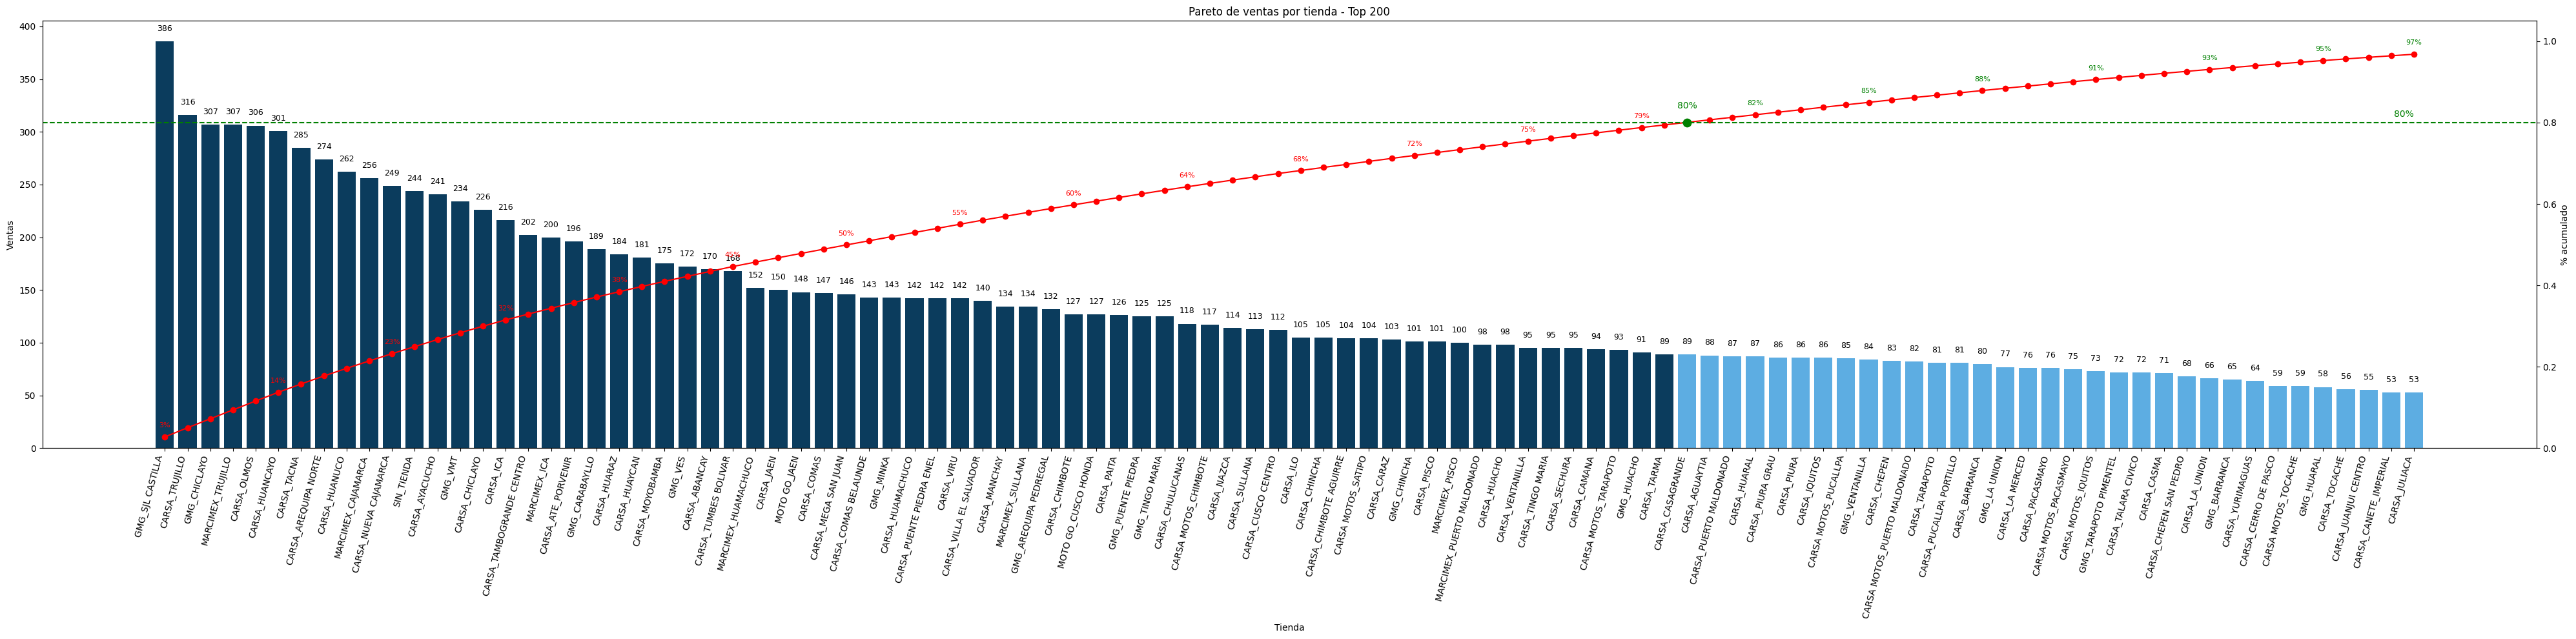

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# 1) Agrupar ventas por tienda
df_tienda = (
    df_ref.groupBy("TIENDA_IR")
      .agg(F.sum("VENTA").alias("ventas"))
      .toPandas()
)

# 2) Limpiar
df_tienda["TIENDA_IR"] = df_tienda["TIENDA_IR"].fillna("SIN_TIENDA")
df_tienda["ventas"] = pd.to_numeric(df_tienda["ventas"], errors="coerce").fillna(0)

# 3) Ordenar y calcular sobre total real
df_tienda = df_tienda.sort_values("ventas", ascending=False).reset_index(drop=True)
df_tienda["pct"] = df_tienda["ventas"] / df_tienda["ventas"].sum()
df_tienda["pct_acum"] = df_tienda["pct"].cumsum()

# 4) Top N puro, sin OTROS
top_n = 100
df_plot = df_tienda.iloc[:top_n].copy()

x = np.arange(len(df_plot))

fig, ax1 = plt.subplots(figsize=(40, 10))

# Colores de barras: rojo hasta 80%, verde después
bar_colors = ["#0B3C5D" if y <= 0.8 else "#5DADE2" for y in df_plot["pct_acum"]]

bars = ax1.bar(x, df_plot["ventas"], color=bar_colors)
ax1.set_ylabel("Ventas")
ax1.set_xlabel("Tienda")
ax1.set_xticks(x)
ax1.set_xticklabels(df_plot["TIENDA_IR"], rotation=75, ha="right")

# Etiquetas de ventas
for i, bar in enumerate(bars):
    if i < 200:
        h = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            h + 8,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="black"
        )

# Línea Pareto en rojo
ax2 = ax1.twinx()
ax2.plot(x, df_plot["pct_acum"], color="red", marker="o")
ax2.set_ylabel("% acumulado")
ax2.set_ylim(0, 1.05)

# Línea 80% en verde
ax2.axhline(0.8, color="green", linestyle="--", linewidth=1.5)
ax2.text(len(df_plot)-1, 0.81, "80%", color="green", ha="right", va="bottom", fontsize=10)

# Punto exacto donde cruza 80%
idx_80 = np.argmax(df_plot["pct_acum"].values >= 0.8)
ax2.scatter(
    x[idx_80],
    df_plot["pct_acum"].iloc[idx_80],
    s=80,
    color="green",
    zorder=5
)
ax2.text(
    x[idx_80],
    df_plot["pct_acum"].iloc[idx_80] + 0.03,
    f"{df_plot['pct_acum'].iloc[idx_80]:.0%}",
    ha="center",
    va="bottom",
    fontsize=10,
    color="green"
)


# ax2.axhline(0.8, color="#5DADE2", linestyle="--", linewidth=1.5)
# ax2.plot(x, df_plot["pct_acum"], color="#0B3C5D", marker="o")
# Etiquetas de % acumulado cada 5 puntos
for i, y in enumerate(df_plot["pct_acum"]):
    if i % 5 == 0 or i == len(df_plot)-1:
        color_txt = "red" if y <= 0.8 else "green"
        ax2.text(
            i,
            y + 0.02,
            f"{y:.0%}",
            ha="center",
            va="bottom",
            fontsize=8,
            color=color_txt
        )

plt.title("Pareto de ventas por tienda - Top 200")
plt.tight_layout()
plt.show()

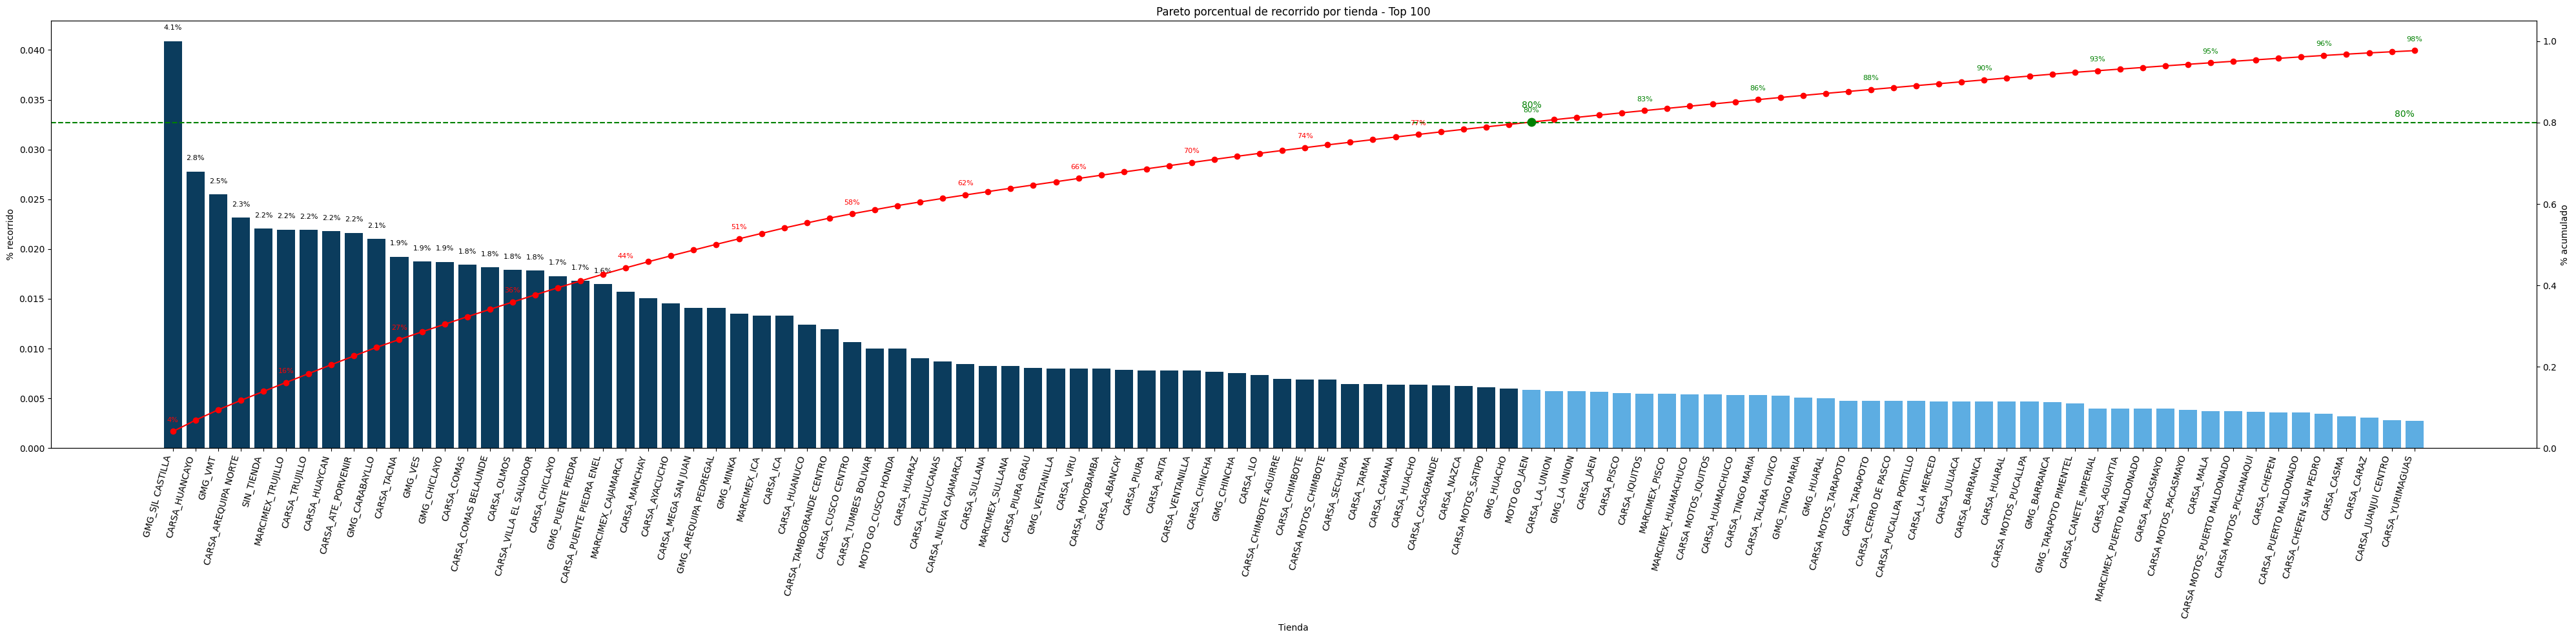

61 tiendas de 114 explican el 80% del recorrido.
Eso representa el 53.5% del total de tiendas.


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# 1) Agrupar recorrido por tienda
df_tienda = (
    df_ref.groupBy("TIENDA_IR")
    .agg(F.sum("RECORRIDO").alias("recorrido"))
    .toPandas()
)

# 2) Limpiar datos
df_tienda["TIENDA_IR"] = df_tienda["TIENDA_IR"].fillna("SIN_TIENDA")
df_tienda["recorrido"] = pd.to_numeric(df_tienda["recorrido"], errors="coerce").fillna(0)

# 3) Ordenar y calcular porcentajes
df_tienda = df_tienda.sort_values("recorrido", ascending=False).reset_index(drop=True)
df_tienda["pct"] = df_tienda["recorrido"] / df_tienda["recorrido"].sum()
df_tienda["pct_acum"] = df_tienda["pct"].cumsum()

# 4) Top N
top_n = 100
df_plot = df_tienda.iloc[:top_n].copy()

# 5) Posiciones eje X
x = np.arange(len(df_plot))

# 6) Gráfico
fig, ax1 = plt.subplots(figsize=(40, 10))

# Colores de barras
bar_colors = ["#0B3C5D" if y <= 0.8 else "#5DADE2" for y in df_plot["pct_acum"]]

bars = ax1.bar(x, df_plot["pct"], color=bar_colors)
ax1.set_ylabel("% recorrido")
ax1.set_xlabel("Tienda")
ax1.set_xticks(x)
ax1.set_xticklabels(df_plot["TIENDA_IR"], rotation=75, ha="right")

# Etiquetas de barras: primeras 20
for i, bar in enumerate(bars):
    if i < 20:
        h = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.001,
            f"{h:.1%}",
            ha="center",
            va="bottom",
            fontsize=8
        )

# Línea Pareto
ax2 = ax1.twinx()
ax2.plot(x, df_plot["pct_acum"], color="red", marker="o", linewidth=1.5)
ax2.set_ylabel("% acumulado")
ax2.set_ylim(0, 1.05)

# Línea 80%
ax2.axhline(0.8, color="green", linestyle="--", linewidth=1.5)
ax2.text(len(df_plot) - 1, 0.81, "80%", color="green", ha="right", va="bottom", fontsize=10)

# Punto exacto del 80%
idx_80 = np.argmax(df_plot["pct_acum"].values >= 0.8)
ax2.scatter(
    x[idx_80],
    df_plot["pct_acum"].iloc[idx_80],
    s=80,
    color="green",
    zorder=5
)
ax2.text(
    x[idx_80],
    df_plot["pct_acum"].iloc[idx_80] + 0.03,
    f"{df_plot['pct_acum'].iloc[idx_80]:.0%}",
    ha="center",
    va="bottom",
    fontsize=10,
    color="green"
)

# Etiquetas del acumulado cada 5 puntos
for i, y in enumerate(df_plot["pct_acum"]):
    if i % 5 == 0 or i == len(df_plot) - 1:
        color_txt = "red" if y <= 0.8 else "green"
        ax2.text(
            i,
            y + 0.02,
            f"{y:.0%}",
            ha="center",
            va="bottom",
            fontsize=8,
            color=color_txt
        )

plt.title(f"Pareto porcentual de recorrido por tienda - Top {top_n}")
plt.tight_layout()
plt.show()

# 7) Resumen numérico
n_80 = (df_tienda["pct_acum"] <= 0.8).sum() + 1
total_tiendas = len(df_tienda)

print(f"{n_80} tiendas de {total_tiendas} explican el 80% del recorrido.")
print(f"Eso representa el {n_80 / total_tiendas:.1%} del total de tiendas.")

In [43]:
print(num_tiendas_80_ventas, total_tiendas)
print(num_tiendas_80_recorrido, total_tiendas)

NameError: name 'num_tiendas_80_ventas' is not defined

In [46]:
df_tiendas.groupby("PROPENSION_CREDICASH")["VENTA"].sum()
df_tiendas.groupby("PROPENSION_ELECTRO")["VENTA"].sum()
df_tiendas.groupby("FRESCURA")["VENTA"].sum()

NameError: name 'df_tiendas' is not defined

In [47]:
import pandas as pd
import numpy as np
from pyspark.sql import functions as F

df_tienda_ventas = (
    df_ref.groupBy("TIENDA_IR")
    .agg(F.sum("VENTA").alias("ventas"))
    .toPandas()
)

df_tienda_ventas["TIENDA_IR"] = df_tienda_ventas["TIENDA_IR"].fillna("SIN_TIENDA")
df_tienda_ventas["ventas"] = pd.to_numeric(df_tienda_ventas["ventas"], errors="coerce").fillna(0)

df_tienda_ventas = df_tienda_ventas.sort_values("ventas", ascending=False).reset_index(drop=True)
df_tienda_ventas["pct"] = df_tienda_ventas["ventas"] / df_tienda_ventas["ventas"].sum()
df_tienda_ventas["pct_acum"] = df_tienda_ventas["pct"].cumsum()

num_tiendas_80_ventas = (df_tienda_ventas["pct_acum"] <= 0.8).sum() + 1
total_tiendas = len(df_tienda_ventas)

print("Tiendas que explican 80% de ventas:", num_tiendas_80_ventas)
print("Total de tiendas:", total_tiendas)
print("Participación de tiendas:", f"{num_tiendas_80_ventas/total_tiendas:.1%}")

Tiendas que explican 80% de ventas: 69
Total de tiendas: 114
Participación de tiendas: 60.5%


In [48]:
df_tienda_rec = (
    df_ref.groupBy("TIENDA_IR")
    .agg(F.sum("RECORRIDO").alias("recorrido"))
    .toPandas()
)

df_tienda_rec["TIENDA_IR"] = df_tienda_rec["TIENDA_IR"].fillna("SIN_TIENDA")
df_tienda_rec["recorrido"] = pd.to_numeric(df_tienda_rec["recorrido"], errors="coerce").fillna(0)

df_tienda_rec = df_tienda_rec.sort_values("recorrido", ascending=False).reset_index(drop=True)
df_tienda_rec["pct"] = df_tienda_rec["recorrido"] / df_tienda_rec["recorrido"].sum()
df_tienda_rec["pct_acum"] = df_tienda_rec["pct"].cumsum()

num_tiendas_80_recorrido = (df_tienda_rec["pct_acum"] <= 0.8).sum() + 1

print("Tiendas que explican 80% del recorrido:", num_tiendas_80_recorrido)
print("Total de tiendas:", total_tiendas)
print("Participación de tiendas:", f"{num_tiendas_80_recorrido/total_tiendas:.1%}")

Tiendas que explican 80% del recorrido: 61
Total de tiendas: 114
Participación de tiendas: 53.5%


In [49]:
print(num_tiendas_80_ventas, total_tiendas)
print(num_tiendas_80_recorrido, total_tiendas)

69 114
61 114


In [50]:
df_ref.groupBy("PROPENSION_CREDICASH").agg(F.sum("VENTA").alias("ventas")).orderBy("PROPENSION_CREDICASH").show()

df_ref.groupBy("PROPENSION_ELECTRO").agg(F.sum("VENTA").alias("ventas")).orderBy("PROPENSION_ELECTRO").show()

df_ref.groupBy("FRESCURA").agg(F.sum("VENTA").alias("ventas")).orderBy("FRESCURA").show()

+--------------------+------+
|PROPENSION_CREDICASH|ventas|
+--------------------+------+
|                   1|  5814|
|                   2|  2905|
|                   3|  1547|
|                   4|  1003|
|                   5|  1939|
+--------------------+------+

+------------------+------+
|PROPENSION_ELECTRO|ventas|
+------------------+------+
|              NULL|  5865|
|                 1|  3179|
|                 2|  1518|
|                 3|   764|
|                 4|   619|
|                 5|  1263|
+------------------+------+

+--------+------+
|FRESCURA|ventas|
+--------+------+
|    NULL|   351|
|       0|  1754|
|       1|  1776|
|       2|  1893|
|       3|  2144|
|       4|  5290|
+--------+------+



In [51]:
df_pd = df_ref.select(
    "PROPENSION_CREDICASH",
    "PROPENSION_ELECTRO",
    "FRESCURA",
    "VENTA"
).toPandas()

print(df_pd.groupby("PROPENSION_CREDICASH")["VENTA"].sum())
print(df_pd.groupby("PROPENSION_ELECTRO")["VENTA"].sum())
print(df_pd.groupby("FRESCURA")["VENTA"].sum())

PROPENSION_CREDICASH
1    5814
2    2905
3    1547
4    1003
5    1939
Name: VENTA, dtype: int32
PROPENSION_ELECTRO
1.0    3179
2.0    1518
3.0     764
4.0     619
5.0    1263
Name: VENTA, dtype: int32
FRESCURA
0.0    1754
1.0    1776
2.0    1893
3.0    2144
4.0    5290
Name: VENTA, dtype: int32


In [52]:
df_pd = df_ref.select(
    "PROPENSION_CREDICASH",
    "PROPENSION_ELECTRO",
    "FRESCURA",
    "VENTA"
).toPandas()

print(df_pd.groupby("PROPENSION_CREDICASH")["VENTA"].sum())
print(df_pd.groupby("PROPENSION_ELECTRO")["VENTA"].sum())
print(df_pd.groupby("FRESCURA")["VENTA"].sum())

PROPENSION_CREDICASH
1    5814
2    2905
3    1547
4    1003
5    1939
Name: VENTA, dtype: int32
PROPENSION_ELECTRO
1.0    3179
2.0    1518
3.0     764
4.0     619
5.0    1263
Name: VENTA, dtype: int32
FRESCURA
0.0    1754
1.0    1776
2.0    1893
3.0    2144
4.0    5290
Name: VENTA, dtype: int32


In [53]:
print("80 ventas:", num_tiendas_80_ventas, total_tiendas, f"{num_tiendas_80_ventas/total_tiendas:.1%}")
print("80 recorrido:", num_tiendas_80_recorrido, total_tiendas, f"{num_tiendas_80_recorrido/total_tiendas:.1%}")

80 ventas: 69 114 60.5%
80 recorrido: 61 114 53.5%


In [11]:
ratio = num_tiendas_80 / total_tiendas

TypeError: 'value' must be an instance of str or bytes, not a None

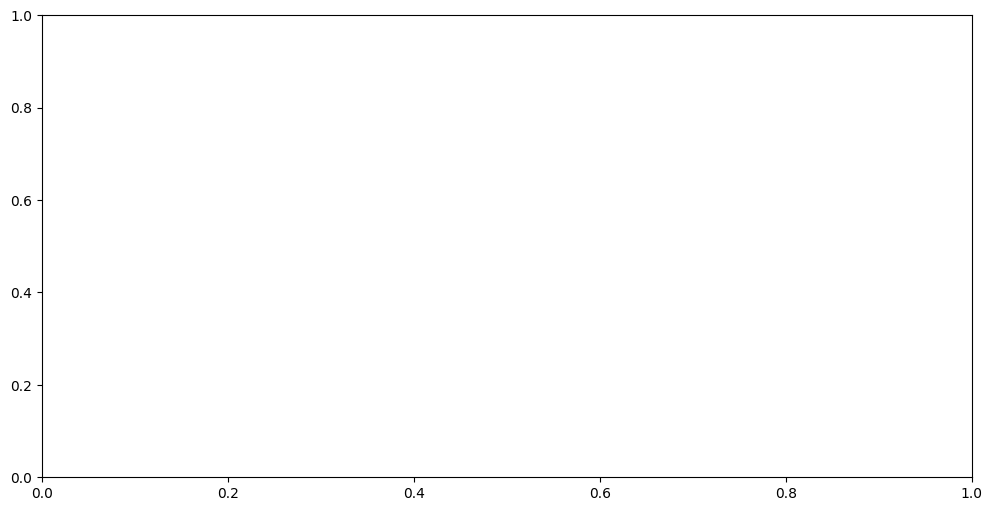

In [12]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

# barras
ax1.bar(df_pd["TIENDA_IR"], df_pd["ventas"])
ax1.set_ylabel("Ventas")
plt.xticks(rotation=90)

# línea acumulada
ax2 = ax1.twinx()
ax2.plot(df_pd["TIENDA_IR"], df_pd["pct_acum"], color="red", marker="o")
ax2.set_ylabel("% acumulado")

plt.show()

In [13]:
import numpy as np

x = np.sort(df_pd["ventas"].values)
n = len(x)

gini = (np.sum((2*np.arange(1, n+1) - n - 1) * x)) / (n * np.sum(x))

print("Gini:", gini)

Gini: 0.32560277131350485


In [5]:
print(df_ref.columns)

['DNI_CLIENTE', 'LOTE', 'EJECUTIVO', 'TIPIFICACION', 'TODO', 'RECORRIDO', 'CEF', 'CNE', 'NOC', 'SG', 'DNOG', 'DGEST', 'INTENTOS_DISC', 'INTENTOS', 'I_CET', 'I_NCET', 'VENTA', 'Semana', 'FECHA', 'HORA', 'MODALIDAD', 'CELULAR', 'NIVEL_1', 'NIVEL_2', 'CAMPAÑA', 'OFERTA_ACEPTADA', 'estado_venta', 'FECHA_VENTA', 'PROVEEDOR', 'ESTADO_CLIENTE', 'ALTA_DEMANDA_PRIORIZADO', 'VENTA_DESEMBOLSADO', 'MONTO_DESEMBOLSADO', 'RANGO_MONTO_OFERTA_CREDICASH', 'RANGO_MONTO_TARGET_OFERTA_ELECTRO', 'NOMBRE_COMPLETO', 'OBS_FCC', 'SEMAFORO', 'REGION', 'TIENDA_IR', 'PERFIL', 'PLAZO', 'TASA', 'CME_DISPONIBLE', 'SCORE_TELEFONO', 'MARCA_PD', 'MSI', 'FLG_CREDICASH', 'GRUPO_SEGMENTO', 'PRODUCTO_EXTERNO', 'PROPENSION_ELECTRO', 'PROPENSION_CREDICASH', 'FLG_CRUCE_RECURRENTE', 'ALTA_DEMANDA', 'DEMANDA', 'PRIORIDAD', 'FRESCURA', 'INTENSIDAD_MAX', 'ORIGEN_CELULAR', 'FLG_AAHH']


In [5]:
print(df_vicidial.columns)

['codigo', 'phone_number', 'vendor_lead_code', 'dial_method', 'numero_campana', 'dni_ejecutivo', 'ejecutivo', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_description', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'hora_a', 'descripcion', 'peso', 'n_mejor_resul_cli', 'n_mejor_resul_telf', 'n_ult_resul', 'mejor_codigo_cli', 'ult_codigo_cli', 'ult_call_result', 'fecha_llamada_1', 'fecha_hora_llamada_1', 'q_intentos', 'mejor_codigo_telf', 'q_intentos_telf', 'q_intentos_dia', 'q_intentos_dia_1']


In [4]:
df_vicidial=df_vicidial.filter(F.col('fecha_llamada')=='2026-04-13')

In [6]:
df_vicidial=df_vicidial.select('codigo', 'phone_number', 'vendor_lead_code', 'dial_method', 'numero_campana', 'dni_ejecutivo', 'ejecutivo', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_description', 'list_name', 'comentarios', 'fecha_llamada','hora_a', 'descripcion', 'peso', 'ult_codigo_cli', 'q_intentos', 'q_intentos_telf')



In [8]:
df_list_filtrada = df_vicidial.toPandas()
ruta_archivo = os.path.join(ruta_csv, 'tipificaciones_dinner_pp_20260413.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [2]:
    fecha_mes_base='2026-04-01'
    ls_una_vez = ['R016','R019','DC']
    ls_ocupado = ['R017','AB']
    ls_casilla = ['R018','AA']
    tipi_cond1='SAE'
    tipi_cond2='SAR'
    tipi_cond3='AGENDA'
    tb_tipolofia='tTipologia_Cencosud_PPFF'
    servidor_01=76
    tipi_cod='Codigo'
    tipi_resp_cod='R'
    tipi_descrip='DESCRIPCION'
    tipi_estado='tipo'
    tipi_resp_estado='NO GESTIONADO'
    tipi_subdescripcion='SUB_DESCRIPCION'
    tnum_tb='tNumeroCenco_Sae'
    tnum_dni='CODDOC'
    tlista_generada='borrar_prestamo_cencosud'
    get_base=since_base_maestra_cencosud_ppff



In [4]:
df_vicidial=since_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_cond3,tb_tipolofia,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado,tnum_tb,tnum_dni)


In [ ]:
df_vicidial.filter(F.col('vendor_lead_code')=='00036777').orderBy(F.col('fecha_hora_llaaada').desc()).show(11)

+------+------------+----------------+--------------------+--------------+-------------+------------------+--------------+-------------------+--------+------------------+----------------+----------------+------------+--------------------+-------------+-----+--------+--------------------+----+-----------------+------------------+-----------+----------------+--------------+------------------+---------------+--------------------+----------+-----------------+---------------+--------------+----------------+
|codigo|phone_number|vendor_lead_code|         dial_method|numero_campana|dni_ejecutivo|         ejecutivo|nombre_campana| fecha_hora_llamada|duracion|       call_result|list_description|       list_name|fecha_agenda|         comentarios|fecha_llamada|tramo|  hora_a|         descripcion|peso|n_mejor_resul_cli|n_mejor_resul_telf|n_ult_resul|mejor_codigo_cli|ult_codigo_cli|   ult_call_result|fecha_llamada_1|fecha_hora_llamada_1|q_intentos|mejor_codigo_telf|q_intentos_telf|q_intentos_dia|q_

In [4]:
df_vicidial=since_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_cond3,tb_tipolofia,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado)
print([row['descripcion' ] for row in df_vicidial.select('descripcion').distinct().collect()])


['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'SIN DESCRIPCION', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO SE ASIGNO RESULTADO A LA LLAMADA (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'GESTION EN PROCESO (AUTO)', 'NUMERO DESCONECTADO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)']


In [ ]:

# def lista_generada(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tipi_cond1,tipi_cond2,tipi_cond3,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado,tipi_subdescripcion,tnum_tb,tnum_dni,tlista_generada,get_base):

df_vicidial=since_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_cond3,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado)
df_base_vigente = get_base(spark)
df_tnumeric=since_tnumeros(spark,tnum_tb,tnum_dni)


In [ ]:
df_vicidial.withColumn(
            "vendor_lead_code",
            F.right(
                F.concat(F.lit("00000000"), F.col("vendor_lead_code")),
                F.lit(8)
            )
        )sssss

In [ ]:
def lista_generada_valentina(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tlista_generada,tb_tipolofia,tb_gestiones,tb_cliente,get_base):

    df_vicidial=since_valentina(spark,fecha_mes_base,tb_tipolofia,tb_gestiones)
    df_base_vigente = get_base(spark,fecha_mes_base)
    df_base_vigente = df_base_vigente.withColumn(
        "dni_cliente",
        F.right(
            F.concat(F.lit("00000000"), F.col("dni_cliente")),
            F.lit(8)
        )
    )
    df_tnumeric=since_tnumeros_valentina(spark,tb_cliente,fecha_mes_base)
    df_tnumeric = df_tnumeric.withColumn(
        "dni_cliente",
        F.right(
            F.concat(F.lit("00000000"), F.col("dni_cliente")),
            F.lit(8)
        )
    )

    df_mejor_telf = df_vicidial.filter(
        (F.col("duracion").isNotNull()) &
        (F.col("dni_cliente").isNotNull())
    ).select('dni_cliente','contacto','fecha_llamada','peso','codigo','cod_attempt','q_intentos_telef')

    window_spec = Window.partitionBy("dni_cliente","contacto").orderBy(F.col("peso").asc_nulls_last(),F.col("fecha_llamada").desc())
    df_mejor_telf = df_mejor_telf.withColumn("n15_mejor_tel", row_number().over(window_spec))

    window_part = Window.partitionBy("dni_cliente","contacto")

    df_mejor_telf = df_mejor_telf.withColumn(
        "mejor15_codigo_telf",
        F.max(
            F.when(F.col("n15_mejor_tel") == 1, F.col("codigo"))
        ).over(window_part)
    )

    window_spec = Window.partitionBy("dni_cliente").orderBy(F.col("peso").asc_nulls_last())
    df_mejor_telf = df_mejor_telf.withColumn("n15_mejor_cli", row_number().over(window_spec))

    window_part = Window.partitionBy("dni_cliente")

    df_mejor_telf = df_mejor_telf.withColumn(
        "mejor15_codigo_cli",
        F.max(
            F.when(F.col("n15_mejor_cli") == 1, F.col("codigo"))
        ).over(window_part)
    )

    window_spec = Window.partitionBy("dni_cliente",'contacto').orderBy(F.col("n15_mejor_tel").asc_nulls_last())
    df_mejor_telf = df_mejor_telf.withColumn("re", row_number().over(window_spec))
    df_mejor_telf=df_mejor_telf.filter(F.col('re')==1)
    df_mejor_telf=df_mejor_telf.select('dni_cliente','contacto','mejor15_codigo_cli','mejor15_codigo_telf','cod_attempt','q_intentos_telef')
    df_tnumeric=df_tnumeric.join(df_mejor_telf,['dni_cliente','contacto'],'left')

    dic_telf = {v: i+1 for i, v in enumerate(listas_tnumeros)}

    mapping_expr = F.create_map([F.lit(x) for x in chain(*dic_telf.items())])

    df_tnumeric = df_tnumeric.withColumn(
        "indice_tpo_telf",
        mapping_expr[F.col("tipo_telf")]
    )

    cod = F.col("mejor15_codigo_telf")
    attempt = F.col("cod_attempt")
    phone = F.col("contacto")

    df_tnumeric = df_tnumeric.withColumn(
        "contacto_02",
        F.when(cod.isNotNull(), 
                F.when((cod.isin(ls_una_vez) == False) & cod.isNotNull(), phone)
                .when(cod.isin(ls_casilla) & (attempt < 3) & cod.isNotNull(), phone)
                .when(cod.isin(ls_ocupado) & (attempt < 2) & cod.isNotNull(), phone)
        ).otherwise(phone)
    )

    df_tnumeric = df_tnumeric.withColumn(
        "indice_tpo_telf",
        F.when(F.col("contacto_02").isNotNull(), F.col("indice_tpo_telf"))
    )

    window_spec = Window.partitionBy("dni_cliente")

    df_tnumeric = df_tnumeric.withColumn(
        "min_numero",
        F.min("indice_tpo_telf").over(window_spec)
    )

    df_tnumeric = df_tnumeric.withColumn(
        "contacto_04",
        F.max(
            F.when((F.col("indice_tpo_telf") == F.col("min_numero")), F.col("contacto"))
            .otherwise(F.col("contacto_02"))
        ).over(window_spec)
    )

    df_tnumeric = df_tnumeric.withColumn(
        "contacto_02",
        F.when((F.col("contacto_02").isNull())&(F.col("tipo_telf")=='BBDD CEL01'), F.col("contacto_04")).otherwise(F.col("contacto_02"))
    ).drop('contacto_04')

    window_spec = Window.partitionBy("dni_cliente").orderBy(F.col("n_mejor_resul").asc_nulls_last())
    df_vicidial = df_vicidial.withColumn("ref_01", row_number().over(window_spec))
    df_vicidial = df_vicidial.filter(F.col("ref_01") == 1)
    df_vicidial=df_vicidial.select('dni_cliente', 'duracion', 'ult_codigo_result', 'fecha_llamada','mejor_codigo_cli','mejor_codigo_cli_dia','dni_ejecutivo','fecha_llamada_1')

        
    df_lista=df_tnumeric.join(df_base_vigente,['dni_cliente'],'left')
    df_lista=df_lista.join(df_vicidial,['dni_cliente'],'left')
    df_lista = df_lista.withColumn("fecha_llamada", col('fecha_llamada_1')).drop('fecha_llamada_1')

    window_spec = Window.orderBy("dni_cliente")

    df_lista = df_lista.withColumn(
        "dni_unico",
        dense_rank().over(window_spec)
    )

    query = f"""
        SELECT 
        id_banco as mejor_codigo_cli,
        nivel_1 as mejor_estado_tipi_cli,
        nivel_2 as mejor_sub_descripcion,
        nombre as mejor_descripcion_cli,
        id as mejor_peso_cli
        FROM VALENTINA.dbo.{tb_tipolofia}
        where estado='a'
        """
        
    df_tipi1=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

    df_tipi2 = df_tipi1.selectExpr(
        "mejor_codigo_cli as mejor15_codigo_cli",
        "mejor_estado_tipi_cli as mejor15_estado_tipi_cli",
        "mejor_descripcion_cli as mejor15_descripcion_cli",
        "mejor_sub_descripcion as mejor15_sub_descripcion_cli",
        "mejor_peso_cli as mejor15_peso_cli"
    )

    df_tipi3 = df_tipi1.selectExpr(
        "mejor_codigo_cli as mejor15_codigo_telf",
        "mejor_estado_tipi_cli as mejor15_estado_tipi_telf",
        "mejor_descripcion_cli as mejor15_descripcion_telf",
        "mejor_sub_descripcion as mejor15_sub_descripcion_telf",
        "mejor_peso_cli as mejor15_peso_telf"
    )

    df_tipi4 = df_tipi1.selectExpr(
        "mejor_codigo_cli as mejor_codigo_cli_dia",
        "mejor_estado_tipi_cli as mejor_estado_tipi_cli_dia",
        "mejor_descripcion_cli as mejor_descripcion_cli_dia",
        "mejor_sub_descripcion as mejor_sub_descripcion_cli_dia",
        "mejor_peso_cli as mejor_peso_cli_dia"
    )

    df_lista=df_lista.join(df_tipi1,['mejor_codigo_cli'],'left')
    df_lista=df_lista.join(df_tipi2,['mejor15_codigo_cli'],'left')
    df_lista=df_lista.join(df_tipi3,['mejor15_codigo_telf'],'left')
    df_lista=df_lista.join(df_tipi4,['mejor_codigo_cli_dia'],'left')

    window_spec = Window.partitionBy('dni_cliente','contacto').orderBy(col("fecha_llamada").desc())
    df_lista = df_lista.withColumn("ref_01", row_number().over(window_spec))
    df_lista = df_lista.filter(col("ref_01") == 1).drop('ref_01')

    query = f"""
        SELECT DISTINCT dni_cliente,contacto,retiro
        FROM (
            SELECT dni_cliente,celular as contacto,
            case
                when tipificacion in (4,5) then 'seguimiento -1'
                else 'no llamar -1'
            end as retiro
            FROM valentina.dbo.alfin_gestion
            WHERE DNI_ejecutivo!='99999999' 
            and tipificacion in ('4','5','16','17')
            and CAST(fecha AS DATE) >= DATEADD(MONTH, -1, CAST('{fecha_mes_base}' AS DATE))
            AND CAST(fecha AS DATE) < DATEADD(MONTH, 0, CAST('{fecha_mes_base}' AS DATE))
            UNION ALL
            SELECT DISTINCT dni_cliente,CELULAR as contacto, 'excluir' as retiro
            FROM valentina.dbo.Excluir_Gestion_TARGET where servicio in ('ALFIN','ALFCC')
        ) t
        """
    df_retiro_dni_contacto=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

    query = f"""
        SELECT DISTINCT contacto,retiro2
        FROM (
            SELECT celular as contacto,'indecopi' as retiro2 
            FROM valentina.dbo.alfin_indecopi where celular is not null
            UNION ALL
            select CELULAR as contacto,'retiro' as retiro2 from valentina.dbo.alfin_cel_excluir
        ) t
        """
    df_retiro_contacto=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

    query = f"""
        SELECT dni as dni_cliente ,'venta' as retiro1
        FROM VALENTINA.dbo.alfin_ventas 
        WHERE CAST(fecha AS DATE) >= DATEADD(MONTH, -1, CAST('{fecha_mes_base}' AS DATE))
        AND CAST(fecha AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))
        """
    df_retiro_dni=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

    df_lista=df_lista.join(df_retiro_dni_contacto,['contacto','dni_cliente'],'left')
    df_lista=df_lista.join(df_retiro_dni,['dni_cliente'],'left')
    df_lista=df_lista.join(df_retiro_contacto,['contacto'],'left')

    df_lista = df_lista.withColumn("retiro", when(F.col('retiro1')=='venta','venta')
                                            .when(F.col('retiro2')=='indecopi','indecopi')
                                            .when(F.col('retiro2')=='retiro','retiro')
                                            .when(F.col('retiro')=='excluir','retiro')
                                            .when(F.col('retiro')=='no llamar -1','no volver a llamar')
                                            .when(F.col('retiro')=='seguimiento -1','seguimiento')
                                            .otherwise(F.lit('no aplica'))
                                            ).drop('retiro1','retiro2')
    df_lista = df_lista.withColumn("retiro_id", when(F.col('retiro')=='venta',1)
                                            .when(F.col('retiro')=='indecopi',2)
                                            .when(F.col('retiro')=='retiro',3)
                                            .when(F.col('retiro')=='no volver a llamar',4)
                                            .when(F.col('retiro')=='seguimiento',5)
                                            .otherwise(F.lit(10))
                                            )

    df_lista = df_lista.withColumn(
        "cabecera_carga",
        F.concat_ws(",", "contacto", "cl_id", 'id_servicio', "nombre_add")
    ).drop('nombre_add')

    cols_prioridad = [
        'cabecera_carga','dni_cliente', 'contacto', 'cl_id', 'id_servicio',
    ]


    window_spec = Window.partitionBy('dni_cliente','contacto').orderBy(col("retiro_id").asc())
    df_lista = df_lista.withColumn("ref_01", row_number().over(window_spec))
    df_lista = df_lista.filter(col("ref_01") == 1).drop('ref_01','retiro_id')

    cols_existentes = [c for c in cols_prioridad if c in df_lista.columns]

    cols_restantes = [c for c in df_lista.columns if c not in cols_existentes]

    df_lista = df_lista.select(cols_existentes + cols_restantes)
    df_lista = df_lista.toDF(*[
        re.sub(r'[^a-zA-Z0-9_]', '', c)
        for c in df_lista.columns
    ])
    overwrite_table_SQL(spark,df_lista,f'{tlista_generada}',server_sa,user_sa,pwd_sa,'CRONOX')
    print(f'tabla {tlista_generada} actualizada')


In [22]:
lista_generada(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tipi_cond1,tipi_cond2,tipi_cond3,tb_tipolofia,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado,tipi_subdescripcion,tnum_tb,tnum_dni,tlista_generada,get_base)


tabla borrar_prestamo_cencosud actualizada
['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'indice', 'regimen_laboral', 'producto', 'marca', 'tea', 'retiro', 'fec_pago', 'fecha_ult_atm', 'monto_ant', 'fecha_ult_comp', 'monto_desembolsar', 'rng_saldo_tc_entre_linea_total_tc', 'disp_retiro_efect_', 'mejora_tasa', 'linea_sae', 'pct_sae', 'entidad1', 'deuda1', 'entidad2', 'deuda2', 'entidad3', 'deuda3', 'edad', 'frescura_target', 'flg_mejora', 'propension', 'tipdoc', 'fecha_envio', 'seg_monto', 'seg_tea', 'seg_edad', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso

In [ ]:
['vendor_lead_code', 'phone_number', 'title', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'comments', 'mejor_codigo_telf', 'ult_codigo_cli', 'mejor_codigo_cli', 'indice_num', 'tipo_telf', 'indice_tpo_telf', 'indice', 'regimen_laboral', 'producto', 'marca', 'tea', 'retiro', 'fec_pago', 'fecha_ult_atm', 'monto_ant', 'fecha_ult_comp', 'monto_desembolsar', 'rng_saldo_tc_entre_linea_total_tc', 'disp_retiro_efect_', 'mejora_tasa', 'linea_sae', 'pct_sae', 'entidad1', 'deuda1', 'entidad2', 'deuda2', 'entidad3', 'deuda3', 'edad', 'frescura_target', 'flg_mejora', 'propension', 'tipdoc', 'fecha_envio', 'seg_monto', 'seg_tea', 'seg_edad', 'call_result', 'tramo', 'descripcion', 'peso', 'ult_call_result', 'fecha_llamada', 'fecha_hora_llamada', 'q_intentos', 'q_intentos_telf', 'q_intentos_dia', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_descripcion_cli', 'mejor_sub_descripcion', 'mejor_peso_cli', 'ult_estado_tipi_cli', 'ult_descripcion_cli', 'ult_sub_descripcion_cli', 'ult_peso_cli', 'mejor_estado_tipi_telf', 'mejor_descripcion_telf', 'mejor_sub_descripcion_telf', 'mejor_peso_telf']

In [ ]:
# # def list02_dinners_prestamo(spark):
# fecha_mes_base='2026-04-01'
# ls_una_vez = ['AB','ADC','ADCT','B036','B037','B038']
# ls_ocupado = ['AA','B033','B034','B035','DCMX','DROP','DISPO','DONEM','NA','PDROP','QUEUE','INCALL']
# ls_casilla = ['no_hay_nada']
# tipi_cond1='DINERS'
# tipi_cond2='xx'
# tipi_cond3='xx'
# tipi_tb='tTipologia_Diners_PPD'
# servidor_01=21
# tipi_cod='cod'
# tipi_resp_cod='P'
# tipi_descrip='[NIVEL 4]'
# tipi_estado='[NIVEL 2]'
# tipi_resp_estado='NO CONTACTO'
# tipi_subdescripcion='[NIVEL 3]'
# tnum_tb='tNumeroDiners'
# tnum_dni='NUMERO_DOCUMENTO'
# tlista_generada='borrar_df_tc_pres_dinner_01'
# get_base=since_base_maestra_tc_dinners


In [ ]:
tb_gestiones='alfin_gestion'
tb_cliente='alfin_clientes'
tb_tipolofia='ALFin_tipificaciones'
fecha_mes_base='2026-04-01'
get_base=since_base_maestra_alfin
ls_una_vez=[]
ls_casilla=[]
ls_ocupado=[]
tlista_generada='borrar_df_credicash_01'
df_prueba=lista_generada_valentina(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tlista_generada,tb_tipolofia,tb_gestiones,tb_cliente,get_base)


# def lista_generada_valentina(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tlista_generada,tb_tipolofia,tb_gestiones,tb_cliente,get_base):

#     df_vicidial=since_valentina(spark,fecha_mes_base,tb_tipolofia,tb_gestiones)
#     df_base_vigente = get_base(spark,fecha_mes_base)
#     df_base_vigente = df_base_vigente.withColumn(
#         "dni_cliente",
#         F.right(
#             F.concat(F.lit("00000000"), F.col("dni_cliente")),
#             F.lit(8)
#         )
#     )
#     df_tnumeric=since_tnumeros_valentina(spark,tb_cliente,fecha_mes_base)
#     df_tnumeric = df_tnumeric.withColumn(
#         "dni_cliente",
#         F.right(
#             F.concat(F.lit("00000000"), F.col("dni_cliente")),
#             F.lit(8)
#         )
#     )

#     df_mejor_telf = df_vicidial.filter(
#         (F.col("duracion").isNotNull()) &
#         (F.col("dni_cliente").isNotNull())
#     ).select('dni_cliente','contacto','fecha_llamada','peso','codigo','cod_attempt','q_intentos_telef')

#     window_spec = Window.partitionBy("dni_cliente","contacto").orderBy(F.col("peso").asc_nulls_last(),F.col("fecha_llamada").desc())
#     df_mejor_telf = df_mejor_telf.withColumn("n15_mejor_tel", row_number().over(window_spec))

#     window_part = Window.partitionBy("dni_cliente","contacto")

#     df_mejor_telf = df_mejor_telf.withColumn(
#         "mejor15_codigo_telf",
#         F.max(
#             F.when(F.col("n15_mejor_tel") == 1, F.col("codigo"))
#         ).over(window_part)
#     )

#     window_spec = Window.partitionBy("dni_cliente").orderBy(F.col("peso").asc_nulls_last())
#     df_mejor_telf = df_mejor_telf.withColumn("n15_mejor_cli", row_number().over(window_spec))

#     window_part = Window.partitionBy("dni_cliente")

#     df_mejor_telf = df_mejor_telf.withColumn(
#         "mejor15_codigo_cli",
#         F.max(
#             F.when(F.col("n15_mejor_cli") == 1, F.col("codigo"))
#         ).over(window_part)
#     )

#     window_spec = Window.partitionBy("dni_cliente",'contacto').orderBy(F.col("n15_mejor_tel").asc_nulls_last())
#     df_mejor_telf = df_mejor_telf.withColumn("re", row_number().over(window_spec))
#     df_mejor_telf=df_mejor_telf.filter(F.col('re')==1)
#     df_mejor_telf=df_mejor_telf.select('dni_cliente','contacto','mejor15_codigo_cli','mejor15_codigo_telf','cod_attempt','q_intentos_telef')
#     df_tnumeric=df_tnumeric.join(df_mejor_telf,['dni_cliente','contacto'],'left')

#     dic_telf = {v: i+1 for i, v in enumerate(listas_tnumeros)}

#     mapping_expr = F.create_map([F.lit(x) for x in chain(*dic_telf.items())])

#     df_tnumeric = df_tnumeric.withColumn(
#         "indice_tpo_telf",
#         mapping_expr[F.col("tipo_telf")]
#     )

#     cod = F.col("mejor15_codigo_telf")
#     attempt = F.col("cod_attempt")
#     phone = F.col("contacto")

#     df_tnumeric = df_tnumeric.withColumn(
#         "contacto_02",
#         F.when(cod.isNotNull(), 
#                 F.when((cod.isin(ls_una_vez) == False) & cod.isNotNull(), phone)
#                 .when(cod.isin(ls_casilla) & (attempt < 3) & cod.isNotNull(), phone)
#                 .when(cod.isin(ls_ocupado) & (attempt < 2) & cod.isNotNull(), phone)
#         ).otherwise(phone)
#     )

#     df_tnumeric = df_tnumeric.withColumn(
#         "indice_tpo_telf",
#         F.when(F.col("contacto_02").isNotNull(), F.col("indice_tpo_telf"))
#     )

#     window_spec = Window.partitionBy("dni_cliente")

#     df_tnumeric = df_tnumeric.withColumn(
#         "min_numero",
#         F.min("indice_tpo_telf").over(window_spec)
#     )

#     df_tnumeric = df_tnumeric.withColumn(
#         "contacto_04",
#         F.max(
#             F.when((F.col("indice_tpo_telf") == F.col("min_numero")), F.col("contacto"))
#             .otherwise(F.col("contacto_02"))
#         ).over(window_spec)
#     )

#     df_tnumeric = df_tnumeric.withColumn(
#         "contacto_02",
#         F.when((F.col("contacto_02").isNull())&(F.col("tipo_telf")=='BBDD CEL01'), F.col("contacto_04")).otherwise(F.col("contacto_02"))
#     ).drop('contacto_04')

#     window_spec = Window.partitionBy("dni_cliente").orderBy(F.col("n_mejor_resul").asc_nulls_last())
#     df_vicidial = df_vicidial.withColumn("ref_01", row_number().over(window_spec))
#     df_vicidial = df_vicidial.filter(F.col("ref_01") == 1)
#     df_vicidial=df_vicidial.select('dni_cliente', 'duracion', 'ult_codigo_result', 'fecha_llamada','mejor_codigo_cli','mejor_codigo_cli_dia','dni_ejecutivo','fecha_llamada_1')

        
#     df_lista=df_tnumeric.join(df_base_vigente,['dni_cliente'],'left')
#     df_lista=df_lista.join(df_vicidial,['dni_cliente'],'left')
#     df_lista = df_lista.withColumn("fecha_llamada", col('fecha_llamada_1')).drop('fecha_llamada_1')

#     window_spec = Window.orderBy("dni_cliente")

#     df_lista = df_lista.withColumn(
#         "dni_unico",
#         dense_rank().over(window_spec)
#     )


#     query = f"""
#         SELECT 
#         id_banco as mejor_codigo_cli,
#         nivel_1 as mejor_estado_tipi_cli,
#         nivel_2 as mejor_sub_descripcion,
#         nombre as mejor_descripcion_cli,
#         id as mejor_peso_cli
#         FROM VALENTINA.dbo.ALFin_tipificaciones
#         where estado='a'
#         """
        
#     df_tipi1=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

#     df_tipi2 = df_tipi1.selectExpr(
#         "mejor_codigo_cli as mejor15_codigo_cli",
#         "mejor_estado_tipi_cli as mejor15_estado_tipi_cli",
#         "mejor_descripcion_cli as mejor15_descripcion_cli",
#         "mejor_sub_descripcion as mejor15_sub_descripcion_cli",
#         "mejor_peso_cli as mejor15_peso_cli"
#     )

#     df_tipi3 = df_tipi1.selectExpr(
#         "mejor_codigo_cli as mejor15_codigo_telf",
#         "mejor_estado_tipi_cli as mejor15_estado_tipi_telf",
#         "mejor_descripcion_cli as mejor15_descripcion_telf",
#         "mejor_sub_descripcion as mejor15_sub_descripcion_telf",
#         "mejor_peso_cli as mejor15_peso_telf"
#     )

#     df_tipi4 = df_tipi1.selectExpr(
#         "mejor_codigo_cli as mejor_codigo_cli_dia",
#         "mejor_estado_tipi_cli as mejor_estado_tipi_cli_dia",
#         "mejor_descripcion_cli as mejor_descripcion_cli_dia",
#         "mejor_sub_descripcion as mejor_sub_descripcion_cli_dia",
#         "mejor_peso_cli as mejor_peso_cli_dia"
#     )

#     df_lista=df_lista.join(df_tipi1,['mejor_codigo_cli'],'left')
#     df_lista=df_lista.join(df_tipi2,['mejor15_codigo_cli'],'left')
#     df_lista=df_lista.join(df_tipi3,['mejor15_codigo_telf'],'left')
#     df_lista=df_lista.join(df_tipi4,['mejor_codigo_cli_dia'],'left')

#     window_spec = Window.partitionBy('dni_cliente','contacto').orderBy(col("fecha_llamada").desc())
#     df_lista = df_lista.withColumn("ref_01", row_number().over(window_spec))
#     df_lista = df_lista.filter(col("ref_01") == 1).drop('ref_01')

#     query = f"""
#         SELECT DISTINCT dni_cliente,contacto,retiro
#         FROM (
#             SELECT dni_cliente,celular as contacto,
#             case
#                 when tipificacion in (4,5) then 'seguimiento -1'
#                 else 'no llamar -1'
#             end as retiro
#             FROM valentina.dbo.alfin_gestion
#             WHERE DNI_ejecutivo!='99999999' 
#             and tipificacion in ('4','5','16','17')
#             and CAST(fecha AS DATE) >= DATEADD(MONTH, -1, CAST('{fecha_mes_base}' AS DATE))
#             AND CAST(fecha AS DATE) < DATEADD(MONTH, 0, CAST('{fecha_mes_base}' AS DATE))
#             UNION ALL
#             SELECT DISTINCT dni_cliente,CELULAR as contacto, 'excluir' as retiro
#             FROM valentina.dbo.Excluir_Gestion_TARGET where servicio in ('ALFIN','ALFCC')
#         ) t
#         """
#     df_retiro_dni_contacto=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

#     query = f"""
#         SELECT DISTINCT contacto,retiro2
#         FROM (
#             SELECT celular as contacto,'indecopi' as retiro2 
#             FROM valentina.dbo.alfin_indecopi where celular is not null
#             UNION ALL
#             select CELULAR as contacto,'retiro' as retiro2 from valentina.dbo.alfin_cel_excluir
#         ) t
#         """
#     df_retiro_contacto=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

#     query = f"""
#         SELECT dni as dni_cliente ,'venta' as retiro1
#         FROM VALENTINA.dbo.alfin_ventas 
#         WHERE CAST(fecha AS DATE) >= DATEADD(MONTH, -1, CAST('{fecha_mes_base}' AS DATE))
#         AND CAST(fecha AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))
#         """
#     df_retiro_dni=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

#     df_lista=df_lista.join(df_retiro_dni_contacto,['contacto','dni_cliente'],'left')
#     df_lista=df_lista.join(df_retiro_dni,['dni_cliente'],'left')
#     df_lista=df_lista.join(df_retiro_contacto,['contacto'],'left')

#     df_lista = df_lista.withColumn("retiro", when(F.col('retiro1')=='venta','venta')
#                                             .when(F.col('retiro2')=='indecopi','indecopi')
#                                             .when(F.col('retiro2')=='retiro','retiro')
#                                             .when(F.col('retiro')=='excluir','retiro')
#                                             .when(F.col('retiro')=='no llamar -1','no volver a llamar')
#                                             .when(F.col('retiro')=='seguimiento -1','seguimiento')
#                                             .otherwise(F.lit('no aplica'))
#                                             ).drop('retiro1','retiro2')
#     df_lista = df_lista.withColumn("retiro_id", when(F.col('retiro')=='venta',1)
#                                             .when(F.col('retiro')=='indecopi',2)
#                                             .when(F.col('retiro')=='retiro',3)
#                                             .when(F.col('retiro')=='no volver a llamar',4)
#                                             .when(F.col('retiro')=='seguimiento',5)
#                                             .otherwise(F.lit(10))
#                                             )

#     df_lista = df_lista.withColumn(
#         "cabecera_carga",
#         F.concat_ws(",", "contacto", "cl_id", 'id_servicio', "nombre_add")
#     ).drop('nombre_add')

#     cols_prioridad = [
#         'cabecera_carga','dni_cliente', 'contacto', 'cl_id', 'id_servicio',
#     ]


#     window_spec = Window.partitionBy('dni_cliente','contacto').orderBy(col("retiro_id").asc())
#     df_lista = df_lista.withColumn("ref_01", row_number().over(window_spec))
#     df_lista = df_lista.filter(col("ref_01") == 1).drop('ref_01','retiro_id')

#     cols_existentes = [c for c in cols_prioridad if c in df_lista.columns]

#     cols_restantes = [c for c in df_lista.columns if c not in cols_existentes]

#     df_lista = df_lista.select(cols_existentes + cols_restantes)
#     df_lista = df_lista.toDF(*[
#         re.sub(r'[^a-zA-Z0-9_]', '', c)
#         for c in df_lista.columns
#     ])
#     overwrite_table_SQL(spark,df_lista,f'{tlista_generada}',server_sa,user_sa,pwd_sa,'CRONOX')
#     print(f'tabla {tlista_generada} actualizada')


In [2]:
tb_gestiones='alfcc_gestion'
tb_cliente='alfcc_clientes'
tb_tipolofia='ALFcc_tipificaciones'
fecha_mes_base='2026-04-01'
get_base=since_base_maestra_alfcc
ls_una_vez=[]
ls_casilla=[]
ls_ocupado=[]
tlista_generada='borrar_df_credicash_01'


NameError: name 'tb_gestiones' is not defined

In [ ]:
# def lista_generada_valentina(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tlista_generada,tb_tipolofia,tb_gestiones,tb_cliente,get_base):

df_vicidial=since_valentina(spark,fecha_mes_base,tb_tipolofia,tb_gestiones)
df_base_vigente = get_base(spark,fecha_mes_base)
df_base_vigente = df_base_vigente.withColumn(
    "dni_cliente",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni_cliente")),
        F.lit(8)
    )
)
df_tnumeric=since_tnumeros_valentina(spark,tb_cliente,fecha_mes_base)
df_tnumeric = df_tnumeric.withColumn(
    "dni_cliente",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni_cliente")),
        F.lit(8)
    )
)

df_mejor_telf = df_vicidial.filter(
    (F.col("duracion").isNotNull()) &
    (F.col("dni_cliente").isNotNull())
).select('dni_cliente','contacto','fecha_llamada','peso','codigo','cod_attempt','q_intentos_telef')

window_spec = Window.partitionBy("dni_cliente","contacto").orderBy(F.col("peso").asc_nulls_last(),F.col("fecha_llamada").desc())
df_mejor_telf = df_mejor_telf.withColumn("n15_mejor_tel", row_number().over(window_spec))

window_part = Window.partitionBy("dni_cliente","contacto")

df_mejor_telf = df_mejor_telf.withColumn(
    "mejor15_codigo_telf",
    F.max(
        F.when(F.col("n15_mejor_tel") == 1, F.col("codigo"))
    ).over(window_part)
)

window_spec = Window.partitionBy("dni_cliente").orderBy(F.col("peso").asc_nulls_last())
df_mejor_telf = df_mejor_telf.withColumn("n15_mejor_cli", row_number().over(window_spec))

window_part = Window.partitionBy("dni_cliente")

df_mejor_telf = df_mejor_telf.withColumn(
    "mejor15_codigo_cli",
    F.max(
        F.when(F.col("n15_mejor_cli") == 1, F.col("codigo"))
    ).over(window_part)
)

In [5]:
df_base_vigente.count()

275996

In [ ]:


window_spec = Window.partitionBy("dni_cliente",'contacto').orderBy(F.col("n15_mejor_tel").asc_nulls_last())
df_mejor_telf = df_mejor_telf.withColumn("re", row_number().over(window_spec))
df_mejor_telf=df_mejor_telf.filter(F.col('re')==1)
df_mejor_telf=df_mejor_telf.select('dni_cliente','contacto','mejor15_codigo_cli','mejor15_codigo_telf','cod_attempt','q_intentos_telef')
df_tnumeric=df_tnumeric.join(df_mejor_telf,['dni_cliente','contacto'],'left')

dic_telf = {v: i+1 for i, v in enumerate(listas_tnumeros)}

mapping_expr = F.create_map([F.lit(x) for x in chain(*dic_telf.items())])

df_tnumeric = df_tnumeric.withColumn(
    "indice_tpo_telf",
    mapping_expr[F.col("tipo_telf")]
)

cod = F.col("mejor15_codigo_telf")
attempt = F.col("cod_attempt")
phone = F.col("contacto")

df_tnumeric = df_tnumeric.withColumn(
    "contacto_02",
    F.when(cod.isNotNull(), 
            F.when((cod.isin(ls_una_vez) == False) & cod.isNotNull(), phone)
            .when(cod.isin(ls_casilla) & (attempt < 3) & cod.isNotNull(), phone)
            .when(cod.isin(ls_ocupado) & (attempt < 2) & cod.isNotNull(), phone)
    ).otherwise(phone)
)

df_tnumeric = df_tnumeric.withColumn(
    "indice_tpo_telf",
    F.when(F.col("contacto_02").isNotNull(), F.col("indice_tpo_telf"))
)

window_spec = Window.partitionBy("dni_cliente")

df_tnumeric = df_tnumeric.withColumn(
    "min_numero",
    F.min("indice_tpo_telf").over(window_spec)
)

df_tnumeric = df_tnumeric.withColumn(
    "contacto_04",
    F.max(
        F.when((F.col("indice_tpo_telf") == F.col("min_numero")), F.col("contacto"))
        .otherwise(F.col("contacto_02"))
    ).over(window_spec)
)

df_tnumeric = df_tnumeric.withColumn(
    "contacto_02",
    F.when((F.col("contacto_02").isNull())&(F.col("tipo_telf")=='BBDD CEL01'), F.col("contacto_04")).otherwise(F.col("contacto_02"))
).drop('contacto_04')

window_spec = Window.partitionBy("dni_cliente").orderBy(F.col("n_mejor_resul").asc_nulls_last())
df_vicidial = df_vicidial.withColumn("ref_01", row_number().over(window_spec))
df_vicidial = df_vicidial.filter(F.col("ref_01") == 1)
df_vicidial=df_vicidial.select('dni_cliente', 'duracion', 'ult_codigo_result', 'fecha_llamada','mejor_codigo_cli','mejor_codigo_cli_dia','dni_ejecutivo','fecha_llamada_1')

    
df_lista=df_tnumeric.join(df_base_vigente,['dni_cliente'],'left')
df_lista=df_lista.join(df_vicidial,['dni_cliente'],'left')
df_lista = df_lista.withColumn("fecha_llamada", col('fecha_llamada_1')).drop('fecha_llamada_1')

window_spec = Window.orderBy("dni_cliente")

df_lista = df_lista.withColumn(
    "dni_unico",
    dense_rank().over(window_spec)
)

query = f"""
    SELECT 
    id_banco as mejor_codigo_cli,
    nivel_1 as mejor_estado_tipi_cli,
    nivel_2 as mejor_sub_descripcion,
    nombre as mejor_descripcion_cli,
    id as mejor_peso_cli
    FROM VALENTINA.dbo.{tb_tipolofia}
    where estado='a'
    """
    
df_tipi1=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

df_tipi2 = df_tipi1.selectExpr(
    "mejor_codigo_cli as mejor15_codigo_cli",
    "mejor_estado_tipi_cli as mejor15_estado_tipi_cli",
    "mejor_descripcion_cli as mejor15_descripcion_cli",
    "mejor_sub_descripcion as mejor15_sub_descripcion_cli",
    "mejor_peso_cli as mejor15_peso_cli"
)

df_tipi3 = df_tipi1.selectExpr(
    "mejor_codigo_cli as mejor15_codigo_telf",
    "mejor_estado_tipi_cli as mejor15_estado_tipi_telf",
    "mejor_descripcion_cli as mejor15_descripcion_telf",
    "mejor_sub_descripcion as mejor15_sub_descripcion_telf",
    "mejor_peso_cli as mejor15_peso_telf"
)

df_tipi4 = df_tipi1.selectExpr(
    "mejor_codigo_cli as mejor_codigo_cli_dia",
    "mejor_estado_tipi_cli as mejor_estado_tipi_cli_dia",
    "mejor_descripcion_cli as mejor_descripcion_cli_dia",
    "mejor_sub_descripcion as mejor_sub_descripcion_cli_dia",
    "mejor_peso_cli as mejor_peso_cli_dia"
)

df_lista=df_lista.join(df_tipi1,['mejor_codigo_cli'],'left')
df_lista=df_lista.join(df_tipi2,['mejor15_codigo_cli'],'left')
df_lista=df_lista.join(df_tipi3,['mejor15_codigo_telf'],'left')
df_lista=df_lista.join(df_tipi4,['mejor_codigo_cli_dia'],'left')

window_spec = Window.partitionBy('dni_cliente','contacto').orderBy(col("fecha_llamada").desc())
df_lista = df_lista.withColumn("ref_01", row_number().over(window_spec))
df_lista = df_lista.filter(col("ref_01") == 1).drop('ref_01')

query = f"""
    SELECT DISTINCT dni_cliente,contacto,retiro
    FROM (
        SELECT dni_cliente,celular as contacto,
        case
            when tipificacion in (4,5) then 'seguimiento -1'
            else 'no llamar -1'
        end as retiro
        FROM valentina.dbo.alfin_gestion
        WHERE DNI_ejecutivo!='99999999' 
        and tipificacion in ('4','5','16','17')
        and CAST(fecha AS DATE) >= DATEADD(MONTH, -1, CAST('{fecha_mes_base}' AS DATE))
        AND CAST(fecha AS DATE) < DATEADD(MONTH, 0, CAST('{fecha_mes_base}' AS DATE))
        UNION ALL
        SELECT DISTINCT dni_cliente,CELULAR as contacto, 'excluir' as retiro
        FROM valentina.dbo.Excluir_Gestion_TARGET where servicio in ('ALFIN','ALFCC')
    ) t
    """
df_retiro_dni_contacto=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

query = f"""
    SELECT DISTINCT contacto,retiro2
    FROM (
        SELECT celular as contacto,'indecopi' as retiro2 
        FROM valentina.dbo.alfin_indecopi where celular is not null
        UNION ALL
        select CELULAR as contacto,'retiro' as retiro2 from valentina.dbo.alfin_cel_excluir
    ) t
    """
df_retiro_contacto=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

query = f"""
    SELECT dni as dni_cliente ,'venta' as retiro1
    FROM VALENTINA.dbo.alfin_ventas 
    WHERE CAST(fecha AS DATE) >= DATEADD(MONTH, -1, CAST('{fecha_mes_base}' AS DATE))
    AND CAST(fecha AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))
    """
df_retiro_dni=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

df_lista=df_lista.join(df_retiro_dni_contacto,['contacto','dni_cliente'],'left')
df_lista=df_lista.join(df_retiro_dni,['dni_cliente'],'left')
df_lista=df_lista.join(df_retiro_contacto,['contacto'],'left')

df_lista = df_lista.withColumn("retiro", when(F.col('retiro1')=='venta','venta')
                                        .when(F.col('retiro2')=='indecopi','indecopi')
                                        .when(F.col('retiro2')=='retiro','retiro')
                                        .when(F.col('retiro')=='excluir','retiro')
                                        .when(F.col('retiro')=='no llamar -1','no volver a llamar')
                                        .when(F.col('retiro')=='seguimiento -1','seguimiento')
                                        .otherwise(F.lit('no aplica'))
                                        ).drop('retiro1','retiro2')
df_lista = df_lista.withColumn("retiro_id", when(F.col('retiro')=='venta',1)
                                        .when(F.col('retiro')=='indecopi',2)
                                        .when(F.col('retiro')=='retiro',3)
                                        .when(F.col('retiro')=='no volver a llamar',4)
                                        .when(F.col('retiro')=='seguimiento',5)
                                        .otherwise(F.lit(10))
                                        )

df_lista = df_lista.withColumn(
    "cabecera_carga",
    F.concat_ws(",", "contacto", "cl_id", 'id_servicio', "nombre_add")
).drop('nombre_add')

cols_prioridad = [
    'cabecera_carga','dni_cliente', 'contacto', 'cl_id', 'id_servicio',
]


window_spec = Window.partitionBy('dni_cliente','contacto').orderBy(col("retiro_id").asc())
df_lista = df_lista.withColumn("ref_01", row_number().over(window_spec))
df_lista = df_lista.filter(col("ref_01") == 1).drop('ref_01','retiro_id')

cols_existentes = [c for c in cols_prioridad if c in df_lista.columns]

cols_restantes = [c for c in df_lista.columns if c not in cols_existentes]

df_lista = df_lista.select(cols_existentes + cols_restantes)
df_lista = df_lista.toDF(*[
    re.sub(r'[^a-zA-Z0-9_]', '', c)
    for c in df_lista.columns
])
overwrite_table_SQL(spark,df_lista,f'{tlista_generada}',server_sa,user_sa,pwd_sa,'CRONOX')
print(f'tabla {tlista_generada} actualizada')


In [ ]:
lista_generada_valentina(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tlista_generada,tb_tipolofia,tb_gestiones,tb_cliente,get_base)

In [ ]:
msi
flg_credicash
propension

In [32]:
print([row['flg_aahh' ] for row in df_base.select('flg_aahh').distinct().collect()])
print([row['perfil' ] for row in df_base.select('perfil').distinct().collect()])
print([row['lote' ] for row in df_base.select('lote').distinct().collect()])
print([row['proveedor' ] for row in df_base.select('proveedor').distinct().collect()])
print([row['grupo_segmento' ] for row in df_base.select('grupo_segmento').distinct().collect()])
print([row['producto_externo' ] for row in df_base.select('producto_externo').distinct().collect()])
print([row['propension_electro' ] for row in df_base.select('propension_electro').distinct().collect()])
print([row['oferta' ] for row in df_base.select('oferta').distinct().collect()])
print([row['oferta_max' ] for row in df_base.select('oferta_max').distinct().collect()])


['emergente', 'no_emergente', None]
['O1', 'D1', 'O2', 'O3', 'D2', 'D0']
['REINGRESO', '2026-04-01', 'INVENTARIO']
['BANCO', None]
['BK', 'R']
['CREDICASH R / ELECTRO MSI', 'CREDICASH R / ELECTRO', 'CREDICASH R', 'CREDICASH / ELECTRO', 'CREDICASH', 'CREDICASH / ELECTRO MSI']
[1, 3, 5, 4, 2, None]
[None]
[None]


In [25]:
['dni_cliente', 'cl_id', 'id_servicio', 'nombre_add', 'oferta_max', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'seg_oferta']


['dni_cliente', 'cl_id', 'id_servicio', 'nombre_add', 'oferta_max', 'perfil', 'plazo', 'tasa', 'cme_disponible', 'lote', 'proveedor', 'msi', 'flg_credicash', 'propension', 'campana', 'cl_carga', 'obs_fcc', 'semaforo', 'region', 'tienda_ir', 'situacion_laboral', 'score_telefono', 'marca_pd', 'grupo_segmento', 'producto_externo', 'propension_electro', 'propension_credicash', 'flg_cruce_recurrente', 'alta_demanda', 'demanda', 'prioridad', 'inicio', 'fin', 'producto_interno', 'flg_aahh', 'seg_oferta']


In [36]:
df_base.show()

+-----------+-----+-----------+----------+----------+------+------+-----+----+--------------+----+---------+---+-------------+----------+-------+--------+-------+--------+------+---------+-----------------+--------------+--------+--------------+----------------+------------------+--------------------+--------------------+------------+-------+---------+------+---+----------------+--------+----------+
|dni_cliente|cl_id|id_servicio|nombre_add|oferta_max|oferta|perfil|plazo|tasa|cme_disponible|lote|proveedor|msi|flg_credicash|propension|campana|cl_carga|obs_fcc|semaforo|region|tienda_ir|situacion_laboral|score_telefono|marca_pd|grupo_segmento|producto_externo|propension_electro|propension_credicash|flg_cruce_recurrente|alta_demanda|demanda|prioridad|inicio|fin|producto_interno|flg_aahh|seg_oferta|
+-----------+-----+-----------+----------+----------+------+------+-----+----+--------------+----+---------+---+-------------+----------+-------+--------+-------+--------+------+---------+------

In [ ]:
fecha_mes_base='2026-04-01'
tb_valentina_cliente='alfin_clientes'

In [ ]:
df_maestra=since_base_maestra_alfin(spark,fecha_mes_base)
df_tnumero=since_tnumeros_valentina(spark,tb_valentina_cliente,fecha_mes_base)




In [ ]:
print(df_maestra.columns)
print(df_tnumero.columns)

In [ ]:
['vend', 'cl_id', 'id_servicio', 'address1', 'Oferta_max', 'distrito', 'departamento', 'provincia', 'lote', 'proveedor', 'nuevos_6m', 'nuevos_9m', 'nuevos_12m', 'nuevos_3m', 'nuevos_4m', 'promocion', 'rango_sueldo', 'tipo_cliente_riegos', 'color', 'color_final', 'edad', 'grupo_tasa', 'grupo_monto', 'nombre_prioridad', 'perfil_ro', 'tipo_cliente', 'frescura', 'region_comercial', 'cliente_nuevo', 'campana', 'campania', 'tienda', 'plazo', 'estado', 'propension', 'propension_ic', 'flg_deuda_plus', 'tipo_base', 'user_v3', 'nombre_base', 'prioridad', 'agencia_comercial', 'cl_carga', 'flg_aahh', 'score_telefono', 'seg_oferta', 'seg_edad']esta


In [ ]:
query = f"""
    SELECT Dni_cliente
    FROM VALENTINA.dbo.alfin_gestion
    WHERE DNI_ejecutivo != '99999999' 
    AND tipificacion IN ('1','2','6','7','8','10','16','17','20','21')
    and CAST(fecha AS DATE) >= CAST('{fecha_mes_base}' AS DATE)
    AND CAST(fecha AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))

    """
df_dni_retiro=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

In [ ]:
tb_gestiones='alfin_gestion'
tb_cliente='alfin_clientes'
tb_tipolofia='ALFin_tipificaciones'
fecha_mes_base='2026-04-01'

# def since_valentina(spark,fecha_mes_base,tb_tipolofia,tb_gestiones):

#     query = f"""
#         select 
#         dni_cliente,
#         fecha as fecha_llamada,Celular as contacto,
#         Tipificacion as codigo,
#         servicio,id_supervisor,Intentos as attempt,tmo as duracion,t_espera,
#         dni_ejecutivo
#         from VALENTINA.dbo.{tb_gestiones}
#         WHERE CAST(fecha AS DATE) >= CAST('{fecha_mes_base}' AS DATE)
#         AND CAST(fecha AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))
#         """
#     df_vicidial=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
        
#     query = f"""
#         SELECT 
#         nombre as descripcion,
#         id_banco as codigo,
#         id as peso
#         FROM VALENTINA.dbo.{tb_tipolofia}
#         where estado='a'
#         """
#     df_tipi=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

#     df_vicidial=df_vicidial.join(df_tipi,["codigo"],"left")

#     window_spec = Window.partitionBy("dni_cliente").orderBy(col("peso").asc_nulls_last())
#     df_vicidial = df_vicidial.withColumn("n_mejor_resul", row_number().over(window_spec))

#     window_part = Window.partitionBy("dni_cliente")
#     df_vicidial = df_vicidial.withColumn(
#         "mejor_codigo_cli",
#         F.max(
#             F.when(F.col("n_mejor_resul") == 1, F.col("codigo"))
#         ).over(window_part)
#     )

#     window_part = Window.partitionBy("dni_cliente","contacto","codigo")

#     df_vicidial = df_vicidial.withColumn(
#         "cod_attempt",
#         F.count("codigo").over(window_part)
#     )

#     window_spec = Window.partitionBy("fecha_llamada","dni_cliente").orderBy(col("peso").asc_nulls_last())
#     df_vicidial = df_vicidial.withColumn("n_mejor_resul_dia", row_number().over(window_spec))

#     window_part = Window.partitionBy("dni_cliente")
#     df_vicidial = df_vicidial.withColumn(
#         "mejor_codigo_cli_dia",
#         F.max(
#             F.when(F.col("n_mejor_resul_dia") == 1, F.col("codigo"))
#         ).over(window_part)
#     )

#     df_vicidial = df_vicidial.withColumn(
#         "q_intentos_telef",
#         count("*").over(window_part)
#     )

#     window_spec = Window.partitionBy("dni_cliente",'contacto').orderBy(col("fecha_llamada").desc())
#     df_vicidial = df_vicidial.withColumn("n_ult_resul", row_number().over(window_spec))

#     window_part = Window.partitionBy("dni_cliente",'contacto')
#     df_vicidial = df_vicidial.withColumn(
#         "ult_codigo_result",
#         F.max(
#             F.when(F.col("n_ult_resul") == 1, F.col("codigo"))
#         ).over(window_part)
#     )
#     df_vicidial = df_vicidial.withColumn(
#         "fecha_llamada_1",
#         F.max(
#             F.when(F.col("n_ult_resul") == 1, F.col("fecha_llamada"))
#         ).over(window_part)
#     )    

#     return df_vicidial.select('dni_cliente', 'duracion', 'fecha_llamada', 'mejor_codigo_cli','peso','contacto','codigo','n_mejor_resul','mejor_codigo_cli_dia','cod_attempt','dni_ejecutivo','q_intentos_telef','descripcion','ult_codigo_result','fecha_llamada_1')



In [24]:
df_tnumeric=since_tnumeros_valentina(spark,tb_cliente,fecha_mes_base)
df_tnumeric = df_tnumeric.withColumn(
    "dni_cliente",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni_cliente")),
        F.lit(8)
    )
)
df_tnumeric.show()

+-----------+---------+---------+
|dni_cliente| contacto|tipo_telf|
+-----------+---------+---------+
|   00000170|961923627|    cel01|
|   00001363|961939547|    cel01|
|   00002331|992027660|    cel01|
|   00002850|964023900|    cel01|
|   00005075|954677543|    cel01|
|   00005102|978167117|    cel01|
|   00005568|965881284|    cel01|
|   00005636|995344978|    cel01|
|   00006227|961977856|    cel01|
|   00007032|980059951|    cel01|
|   00007106|976791239|    cel01|
|   00007140|996407089|    cel01|
|   00007175|965915867|    cel01|
|   00007332|957832093|    cel01|
|   00007528|947240671|    cel01|
|   00008040|961511952|    cel01|
|   00008295|961699390|    cel01|
|   00008377|945931324|    cel01|
|   00008462|961735680|    cel01|
|   00008850|916997012|    cel01|
+-----------+---------+---------+
only showing top 20 rows


tabla borrar_df_alfin_01 actualizada


In [ ]:
df_prueba=lista_generada_valentina(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tlista_generada,tb_tipolofia,tb_gestiones,tb_cliente,get_base)


In [23]:
print(df_lista.columns)

['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'nombre_add', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'address1', 'Oferta_max', 'distrito', 'departamento', 'provincia', 'lote', 'proveedor', 'nuevos_6m', 'nuevos_9m', 'nuevos_12m', 'nuevos_3m', 'nuevos_4m', 'promocion', 'rango_sueldo', 'tipo_cliente_riegos', 'color', 'color_final', 'edad', 'grupo_tasa', 'grupo_monto', 'nombre_prioridad', 'perfil_ro', 'tipo_cliente', 'frescura', 'region_comercial', 'cliente_nuevo', 'campana', 'campania', 'tienda', 'plazo', 'estado', 'cl_estado', 'propension', 'propension_ic', 'flg_deuda_plus', 'tipo_base', 'user_v3', 'nombre_base', 'prioridad', 'agencia_comercial', 'cl_carga', 'flg_aahh', 'score_telefono', 'seg_oferta', 'seg_edad', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor

In [ ]:
df_p=since_valentina(spark,fecha_mes_base,tb_tipolofia,tb_gestiones)
print(df_p.columns)

In [ ]:
query = f"""
    SELECT 
    nivel_1 as estado,
    nombre as descripcion,
    nivel_2 as sub_estado,
    id_banco as cod,
    id as peso
    FROM VALENTINA.dbo.ALFin_tipificaciones
    where estado='a'
    """
df_tipi=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
df_tipi.show(truncate=False)

In [ ]:
cl_base1 = fecha_a_nombre(fecha_mes_base)
query = f"""

    SELECT DISTINCT dni_cliente,retiro,peso_retiro
    FROM (
        SELECT dni as dni_cliente ,'venta' as retiro, 1 as peso_retiro
        FROM VALENTINA.dbo.alfin_ventas 
        WHERE CAST(fecha AS DATE) >= DATEADD(MONTH, -1, CAST('{fecha_mes_base}' AS DATE))
        AND CAST(fecha AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))

        UNION

        SELECT Dni_cliente
        FROM VALENTINA.dbo.alfin_gestion
        WHERE DNI_ejecutivo != '99999999' 
        AND tipificacion IN ('1','2','6','7','8','10','16','17','20','21')
        and CAST(fecha AS DATE) >= CAST('{fecha_mes_base}' AS DATE)
        AND CAST(fecha AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))

        UNION ALL

        SELECT DNI_CLIENTE 
        FROM VALENTINA.dbo.Excluir_Gestion_TARGET 
        WHERE servicio = 'ALFIN'
    ) t
    """
df_dni_retiro=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

query = f"""
    SELECT DISTINCT dni_cliente,contacto
    FROM (
        SELECT dni_cliente,celular as contacto
        FROM valentina.dbo.alfin_gestion
        WHERE DNI_ejecutivo!='99999999' 
        and tipificacion in ('4','5','16','17')
        and CAST(fecha AS DATE) >= DATEADD(MONTH, -1, CAST('{fecha_mes_base}' AS DATE))
        AND CAST(fecha AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))

        UNION ALL
        SELECT DISTINCT dni_cliente,CELULAR as contacto
        FROM valentina.dbo.Excluir_Gestion_TARGET
        WHERE CELULAR!='' AND servicio='ALFIN'
    ) t
    """
df_dni_retiro_dni_contacto=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)



df_tnumero=df_tnumero.join(df_dni_retiro,['dni_cliente'],'leftanti')
df_tnumero=df_tnumero.join(df_dni_retiro_dni_contacto,['dni_cliente','contacto'],'leftanti')


query = f"""
    SELECT 
        g.fecha,g.Celular,g.Dni_cliente,ce.nombres,ce.lote,
        tip.id as id_tipificacion,tip.nombre as tipificacion,
        CONCAT(g.Celular,',',ce.cl_id,',','12',',',ce.nombres,',',ce.apellido_paterno) AS [CELULAR,DNI,NOMBRES],
        tip.id_banco
    FROM valentina.dbo.alfin_gestion g
    INNER JOIN valentina.dbo.alfin_clientes ce 
    on g.dni_cliente=ce.numero_documento 
    INNER JOIN valentina.dbo.alfin_tipificaciones tip 
    on tip.id=g.tipificacion 
    WHERE g.Campaña=@CAMPAÑA and ce.cl_base=@CAMPAÑA and ce.cl_estado='1'
      and g.Dni_cliente not in (SELECT dni 
                                from valentina.dbo.alfin_ventas 
                                where base in (@CAMPAÑA))
      and g.dni_cliente not in (SELECT dni_cliente 
                                FROM valentina.dbo.alfin_gestion 
                                WHERE campaña=@CAMPAÑA 
                                and DNI_ejecutivo!='99999999' 
                                and tipificacion in ('1','2','6','7','12','14'))
      and g.celular not in (SELECT celular 
                            FROM valentina.dbo.alfin_indecopi 
                            where celular is not null)
      and g.Tipificacion in ('3','4','5','9')
	  and tip.estado = 'A'
    """
df_dni_retiro_dni_contacto=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)



In [ ]:
def since_vicidial(spark,fecha_mes_base,coincidencia1,coincidencia2,coincidencia3,tb_tipolofia,dir_1,call_result,resp_call_result,descripcion,estado,resp_estado):
            # a.user AS dni_ejecutivo,        
            # c.full_name AS ejecutivo,        
    query = f"""
        select 
            dni_cliente,
            Fecha,Celular,Tipificacion,Id_personal,servicio,Id_Supervisor,Campaña,Intentos,tmo,T_espera,DNI_ejecutivo
            from alfin_gestion
            WHERE (e.campaign_name like "%{coincidencia1}" or e.campaign_name like "%{coincidencia2}" or e.campaign_name like "%{coincidencia3}")
            AND a.call_date >= DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01'')
            AND a.call_date < DATE_ADD(DATE_FORMAT(''{fecha_mes_base}'', ''%Y-%m-01''), INTERVAL 1 MONTH)
        ')

        """
    df_vicidial=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

    df_vicidial = (
        df_vicidial
        .withColumn("fecha_llamada", F.to_date(F.col("fecha_hora_llamada")))
        .withColumn("tramo", F.hour(F.col("fecha_hora_llamada")))
        .withColumn("hora_a", F.date_format(F.col("fecha_hora_llamada"), "HH:mm:ss"))
    )

    query = f"""
        SELECT {call_result} as CODIGO
        , case
            when {call_result}='CALLBK' then 'VOLVER A LLAMAR - call'
            else {descripcion} 
        end as DESCRIPCION
        ,case 
            when {call_result}='CALLBK' then 1200
            else PESO 
        end as PESO  FROM [ODIN].[dbo].{tb_tipolofia}
        where LEFT({call_result},1)='{resp_call_result}' or {estado}='{resp_estado}' or {call_result}='CALLBK'
        """
    df_tipi=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

    df_vicidial=df_vicidial.join(df_tipi,["CODIGO"],"left")

    window_spec = Window.partitionBy("vendor_lead_code").orderBy(col("PESO").asc_nulls_last())
    df_vicidial = df_vicidial.withColumn("n_mejor_resul", row_number().over(window_spec))

    window_part = Window.partitionBy("vendor_lead_code")
    df_vicidial = df_vicidial.withColumn(
        "mejor_CODIGO_cli",
        F.max(
            F.when(F.col("n_mejor_resul") == 1, F.col("CODIGO"))
        ).over(window_part)
    )

    window_part = Window.partitionBy("vendor_lead_code","phone_number","CODIGO")

    df_vicidial = df_vicidial.withColumn(
        "cod_attempt",
        F.count("CODIGO").over(window_part)
    )

    window_spec = Window.partitionBy("fecha_llamada","vendor_lead_code").orderBy(col("PESO").asc_nulls_last(),col("hora_a").desc_nulls_last())
    df_vicidial = df_vicidial.withColumn("n_mejor_resul_dia", row_number().over(window_spec))

    window_part = Window.partitionBy("vendor_lead_code")
    df_vicidial = df_vicidial.withColumn(
        "mejor_CODIGO_cli_dia",
        F.max(
            F.when(F.col("n_mejor_resul_dia") == 1, F.col("CODIGO"))
        ).over(window_part)
    )

    df_vicidial = df_vicidial.withColumn(
        "q_intentos_telef",
        count("*").over(window_part)
    )

    window_spec = Window.partitionBy("vendor_lead_code",'phone_number').orderBy(col("fecha_hora_llamada").desc())
    df_vicidial = df_vicidial.withColumn("n_ult_resul", row_number().over(window_spec))

    window_part = Window.partitionBy("vendor_lead_code",'phone_number')
    df_vicidial = df_vicidial.withColumn(
        "ult_call_result",
        F.max(
            F.when(F.col("n_ult_resul") == 1, F.col("call_result"))
        ).over(window_part)
    )
    df_vicidial = df_vicidial.withColumn(
        "fecha_llamada_1",
        F.max(
            F.when(F.col("n_ult_resul") == 1, F.col("fecha_llamada"))
        ).over(window_part)
    )    
    df_vicidial = df_vicidial.withColumn(
        "fecha_hora_llamada_1",
        F.max(
            F.when(F.col("n_ult_resul") == 1, F.col("fecha_hora_llamada"))
        ).over(window_part)
    )  
    return df_vicidial[['vendor_lead_code', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'mejor_CODIGO_cli','PESO','phone_number','CODIGO','n_mejor_resul','mejor_CODIGO_cli_dia','cod_attempt','dni_ejecutivo','ejecutivo','q_intentos_telef','DESCRIPCION','dial_method','ult_call_result','fecha_llamada_1','fecha_hora_llamada_1']]


In [ ]:
print([row['seg_edad' ] for row in df_base.select('seg_edad').distinct().collect()])


In [ ]:
[31, 65, 53, 78, 34, 28, 76, 27, 44, 47, 52, 40, 57, 54, 48, 64, 41, 43, 37, 61, 72, 35, 55, 59, 39, 49, 51, 69, 63, 77, 50, 45, 38, 73, 70, 62, 29, 60, 32, 75, 56, 58, 33, 71, 68, 42, 79, 30, 66, 46, 67, 74, 36, None]

In [ ]:
df_base.show(3)


In [ ]:
cols_base = set([c.lower() for c in df_base.columns])
cols_base_p = set([c.lower() for c in df_base_p.columns])

faltantes = cols_base_p - cols_base

print(faltantes)

In [ ]:
{'cl_orden', 'cl_telf7', 'perfil_global', 'cl_prioridad', 'tasa_1', 'mes_gestion', 'cod_bd', 'numero_documento', 'rango_oferta2', 'oferta_24m', 'cl_celular', 'cl_turno', 'cuota', 'apellido_paterno', 'oferta_12m', 'retiro_desembolso', 'numentidades', 'sucursal_comercial', 'localidad', 'cl_mes', 'segmento', 'cuota_12m', 'q_ventas', 'cruce', 'cl_tiempo', 'desgravamen_12m', 'tasa_36m', 'saldo_diferencial_reeng', 'deuda_3', 'oferta_minima_paperless', 'flag_deuda_v_oferta', 'cl_telf1', 'cl_predictivo', 'tasa_18m', 'cl_hits', 'cl_base', 'garantia', 'deuda_2', 'cl_telf10', 'tipo_doi', 'nombres', 'fec_nacimiento', 'cl_fecha_gestion', 'cuota_18m', 'retiro_gest', 'mgneg', 'deuda_1', 'cl_fecha_ant', 'intensidad_max', 'tasa_3', 'capacidad_max', 'entidad_1', 'cl_telf8', 'promocion2', 'prop_comer', 'grupo_riesgo', 'cl_hora_gestion', 'cl_estado', 'fecha_alimentacion', 'tasa_7', 'desgravamen_18m', 'cl_gestor', 'tasa_4', 'cl_telf4', 'tasa_2', 'cl_telf6', 'tipo_verificacion', 'cl_telf9', 'grupo_tasa_reenganche', 'cl_gestion', 'cl_base_ant', 'ofertamaximasinseguro', 'lead_calidad', 'desgravamen', 'entidad_2', 'apellido_materno', 'validador_telefono', 'cl_telf2', 'cl_fecha_llamar', 'cl_accion_ant', 'p_banco', 'id_cliente', 'cl_asesor', 'piloto_plazas', 'monto_desembolsado', 'desgravamen_36m', 'periodo', 'sbi', 'cl_telf3', 'cl_telefono', 'prest_previo', 'tasa_12m', 'segmento_user', 'tasa_24m', 'num_enriquecido', 'tasa_vs_monto', 'mejor_tipificacion', 'id_carga', 'incremento_monto_riesgos', 'tasa_5', 'oferta_reen', 'flag_reeng', 'desembolsado', 'desgravamen_24m', 'nomb_bd', 'rango_edad2', 'resultado', 'cuota_36m', 'sucursal', 'oferta_18m', 'cl_accion', 'cuota_24m', 'tem', 'ubicacion', 'oferta_36m', 'base', 'cl_telf5', 'peer', 'tipo_gest', 'usuario', 'cl_area', 'tipo_bd', 'fecha_sol', 'status', 'entidad_3', 'fecha_envio', 'tipo_contacto', 'oferta_final', 'tasa_6', 'cl_movil'}


In [ ]:
fecha_mes_base='2026-04-01'

# def since_base_maestra_tc_dinners(spark):
query = f"""
select *
    FROM valentina.dbo.alfin_clientes
    where cl_base='{cl_base1}'
    """
df_base_p=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
df_base_p = df_base_p.toDF(*[c.lower() for c in df_base_p.columns])
df_base_p.show(5)

    # WHERE CAST(cl_carga AS DATE) >= CAST('{fecha_mes_base}' AS DATE)
    # AND CAST(cl_carga AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))

In [ ]:
df_base_p.select( 'monto_desembolsado', 'desgravamen_24m', 'oferta_minima_paperless', 'oferta_12m', 'desgravamen_12m', 'cod_bd', 'tipo_bd', 'cl_turno', 'prop_comer', 'retiro_desembolso', 'desembolsado', 'deuda_1', 'ubicacion', 'peer', 'sucursal_comercial', 'rango_edad2', 'fecha_sol', 'tasa_12m', 'tasa_18m', 'desgravamen_36m', 'grupo_tasa_reenganche', 'prest_previo', 'resultado', 'cl_movil', 'cl_mes', 'q_ventas', 'tasa_3', 'capacidad_max', 'tipo_verificacion', 'id_carga', 'status', 'rango_oferta2', 'oferta_24m', 'tasa_4', 'piloto_plazas', 'cuota_12m', 'oferta_reen', 'id_cliente', 'usuario', 'cl_tiempo', 'fecha_envio', 'cruce', 'retiro_gest', 'cl_fecha_ant', 'incremento_monto_riesgos', 'oferta_18m', 'cl_prioridad', 'tasa_1', 'ofertamaximasinseguro', 'cl_base_ant', 'oferta_36m', 'cl_gestor', 'tasa_7', 'cl_predictivo', 'tem', 'nomb_bd', 'base',  'grupo_riesgo', 'cl_fecha_gestion', 'num_enriquecido', 'tasa_24m', 'entidad_1', 'tasa_6', 'tipo_gest', 'tipo_contacto', 'lead_calidad', 'cl_celular', 'cuota', 'mes_gestion', 'desgravamen_18m', 'flag_reeng', 'periodo', 'intensidad_max', 'mgneg', 'validador_telefono', 'localidad', 'tasa_vs_monto', 'cl_area', 'numentidades', 'tasa_5', 'promocion2', 'garantia', 'cl_fecha_llamar', 'segmento_user', 'deuda_3', 'tasa_2', 'desgravamen', 'cl_hora_gestion', 'cuota_24m', 'sbi', 'perfil_global', 'deuda_2', 'segmento', 'cl_hits', 'fec_nacimiento', 'entidad_2', 'flag_deuda_v_oferta', 'cl_asesor', 'entidad_3', 'oferta_final', 'saldo_diferencial_reeng', 'p_banco', 'fecha_alimentacion', 'tipo_doi', 'tasa_36m', 'cl_accion',  'mejor_tipificacion', 'cuota_18m', 'cl_gestion', 'cuota_36m', 'cl_base', 'cl_orden').show(3)

In [ ]:
print([row['cl_gestor' ] for row in df_base_p.select('cl_gestor').distinct().collect()])
print([row['cuota' ] for row in df_base_p.select('cuota').distinct().collect()])
print([row['mejor_tipificacion' ] for row in df_base_p.select('mejor_tipificacion').distinct().collect()])
print([row['cl_gestion' ] for row in df_base_p.select('cl_gestion').distinct().collect()])


In [ ]:
df_base.groupBy("lote").count().show()

In [ ]:
        SELECT numero_documento as dni_cliente 
        FROM VALENTINA.dbo.alfin_clientes 
        WHERE CAST(cl_carga AS DATE) >= CAST('{fecha_mes_base}' AS DATE)
        AND CAST(cl_carga AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))
        AND cl_estado <> '1'


In [ ]:

    # from pyspark.sql.functions import greatest, col, when

    df_base_p = df_base_p.withColumn(
        "monto_title",
        greatest(
            F.col("l_ibk"), F.col("l_bcp"), F.col("l_bbva"), F.col("l_sco"),
            F.col("l_bif"), F.col("l_citi"), F.col("l_fin"), F.col("l_rip"),
            F.col("l_cmr"), F.col("l_cresco"), F.col("l_cen"), F.col("l_azt"),
            F.col("l_uno"), F.col("l_gnb"), F.col("l_efe"), F.col("l_com"), F.col("l_nac")
        )
    )

    df_base_p = df_base_p.withColumn(
        "title",
        F.when(F.col("monto_title") == F.col("l_ibk"), "l_ibk")
        .when(F.col("monto_title") == F.col("l_bcp"), "l_bcp")
        .when(F.col("monto_title") == F.col("l_bbva"), "l_bbva")
        .when(F.col("monto_title") == F.col("l_sco"), "l_sco")
        .when(F.col("monto_title") == F.col("l_bif"), "l_bif")
        .when(F.col("monto_title") == F.col("l_citi"), "l_citi")
        .when(F.col("monto_title") == F.col("l_fin"), "l_fin")
        .when(F.col("monto_title") == F.col("l_rip"), "l_rip")
        .when(F.col("monto_title") == F.col("l_cmr"), "l_cmr")
        .when(F.col("monto_title") == F.col("l_cresco"), "l_cresco")
        .when(F.col("monto_title") == F.col("l_cen"), "l_cen")
        .when(F.col("monto_title") == F.col("l_azt"), "l_azt")
        .when(F.col("monto_title") == F.col("l_uno"), "l_uno")
        .when(F.col("monto_title") == F.col("l_gnb"), "l_gnb")
        .when(F.col("monto_title") == F.col("l_efe"), "l_efe")
        .when(F.col("monto_title") == F.col("l_com"), "l_com")
        .when(F.col("monto_title") == F.col("l_nac"), "l_nac")
        .otherwise("OTROS")
    )

    df_base_p = df_base_p.withColumn(
        "seg_edad",
        F.when((F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) >= 20) &
            (F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) < 30), "1. 20 A 30")
        .when((F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) >= 30) &
            (F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) < 40), "2. 30 A 40")
        .when((F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) >= 40) &
            (F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) < 50), "3. 40 A 50")
        .when((F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) >= 50) &
            (F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) < 60), "4. 50 A 60")
        .when((F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) >= 60) &
            (F.floor(F.months_between(F.current_date(), F.col("fec_nac"))/12) < 76), "5. 60 A 70")
    )

    df_base_p= df_base_p.withColumn(
        "seg_oferta",
        F.when((F.col("linea_credito") >= 1000) & (F.col("linea_credito") <= 2000), "A. 1,000 A 2000")
        .when((F.col("linea_credito") > 2000) & (F.col("linea_credito") <= 4000), "A. 2,000 A 4000")
        .when((F.col("linea_credito") > 4000) & (F.col("linea_credito") <= 6000), "B. 4,000 A 6,000")
        .when((F.col("linea_credito") > 6000) & (F.col("linea_credito") <= 8000), "C. 6,000 A 8,000")
        .when((F.col("linea_credito") > 8000) & (F.col("linea_credito") <= 10000), "D. 8,000 A 10,000")
        .when((F.col("linea_credito") > 10000) & (F.col("linea_credito") <= 12000), "D. 10,000 A 12,000")
        .when(F.col("linea_credito") > 12000, "E. 12,000 A MÁS")
    )
    df_base_p= df_base_p.withColumn(
        "retiro_01",
        when(
            F.length(F.col("RETIRO")) >= 2,
            1
        ).otherwise(0)
    )
    return df_base_p.select('vendor_lead_code', 'tea', 'tea_df', 'tcea', 'tcea_cuotas_df', 'first_name', 'last_name', 'address1', 'address2', 'address3', 'city', 'province', 'email', 'security_phrase', 'linea_credito', 'comments', 'straming', 'fec_nac', 'prioridad', 'priori', 'servicio', 'marca', 'prfl', 'n_base', 'marca3', 'recurr1m', 'recurr2m', 'recurr3m', 'conjunto3meses', 'numtc', 'piloto', 'fecha_envio', 'provincia', 'prob_contacto', 'recurrencia3m', 'monto_title', 'title', 'seg_edad', 'seg_oferta', 'retiro_01')


In [ ]:

filename='credi_1.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
df_prueba = df_prueba.withColumn(
    "dni",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni")),
        F.lit(8)
    )
)


In [ ]:
# def list02_cenco_pp(spark):
fecha_mes_base='2026-04-01'
ls_una_vez = ['R016','R019','DC']
ls_ocupado = ['R017','AB']
ls_casilla = ['R018','AA']
tipi_cond1='SAE'
tipi_cond2='SAR'
tipi_cond3='AGENDA'
tipi_tb='tTipologia_Cencosud_PPFF'
servidor_01=76
tipi_cod='Codigo'
tipi_resp_cod='R'
tipi_descrip='DESCRIPCION'
tipi_estado='tipo'
tipi_resp_estado='NO GESTIONADO'
tipi_subdescripcion='SUB_DESCRIPCION'
tnum_tb='tNumeroCenco_Sae'
tnum_dni='CODDOC'
tlista_generada='borrar_df_cencosud_pp_01'
get_base=since_base_maestra_cencosud_ppff

# lista_generada(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tipi_cond1,tipi_cond2,tipi_cond3,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado,tipi_subdescripcion,tnum_tb,tnum_dni,tlista_generada,get_base)


In [ ]:
# def lista_generada(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tipi_cond1,tipi_cond2,tipi_cond3,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado,tipi_subdescripcion,tnum_tb,tnum_dni,tlista_generada,get_base):


In [ ]:

df_vicidial=since_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_cond3,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado)
df_base_vigente = get_base(spark)
df_base_vigente = df_base_vigente.withColumn(
    "vendor_lead_code",
    F.right(
        F.concat(F.lit("00000000"), F.col("vendor_lead_code")),
        F.lit(8)
    )
)

df_tnumeric=since_tnumeros(spark,tnum_tb,tnum_dni)
df_tnumeric = df_tnumeric.withColumn(
    "vendor_lead_code",
    F.right(
        F.concat(F.lit("00000000"), F.col("vendor_lead_code")),
        F.lit(8)
    )
)
df_mejor_telf = df_vicidial.filter(
    (F.col("duracion").isNotNull()) &
    (F.col("vendor_lead_code").isNotNull())
).select('vendor_lead_code','phone_number','fecha_llamada','PESO','CODIGO','cod_attempt','q_intentos_telef')

window_spec = Window.partitionBy("vendor_lead_code","phone_number").orderBy(F.col("PESO").asc_nulls_last(),F.col("fecha_llamada").desc())
df_mejor_telf = df_mejor_telf.withColumn("n15_mejor_tel", row_number().over(window_spec))

window_part = Window.partitionBy("vendor_lead_code","phone_number")

df_mejor_telf = df_mejor_telf.withColumn(
    "mejor15_CODIGO_telf",
    F.max(
        F.when(F.col("n15_mejor_tel") == 1, F.col("CODIGO"))
    ).over(window_part)
)

window_spec = Window.partitionBy("vendor_lead_code").orderBy(F.col("PESO").asc_nulls_last())
df_mejor_telf = df_mejor_telf.withColumn("n15_mejor_cli", row_number().over(window_spec))

window_part = Window.partitionBy("vendor_lead_code")

df_mejor_telf = df_mejor_telf.withColumn(
    "mejor15_CODIGO_cli",
    F.max(
        F.when(F.col("n15_mejor_cli") == 1, F.col("CODIGO"))
    ).over(window_part)
)

window_spec = Window.partitionBy("vendor_lead_code",'phone_number').orderBy(F.col("n15_mejor_tel").asc_nulls_last())
df_mejor_telf = df_mejor_telf.withColumn("re", row_number().over(window_spec))
df_mejor_telf=df_mejor_telf.filter(F.col('re')==1)
df_mejor_telf=df_mejor_telf.select('vendor_lead_code','phone_number','mejor15_CODIGO_cli','mejor15_CODIGO_telf','cod_attempt','q_intentos_telef')
df_tnumeric=df_tnumeric.join(df_mejor_telf,['vendor_lead_code','phone_number'],'left')

dic_telf = {v: i+1 for i, v in enumerate(listas_tnumeros)}

mapping_expr = F.create_map([F.lit(x) for x in chain(*dic_telf.items())])

df_tnumeric = df_tnumeric.withColumn(
    "indice_tpo_telf",
    mapping_expr[F.col("tipo_telf")]
)

cod = F.col("mejor15_CODIGO_telf")
attempt = F.col("cod_attempt")
phone = F.col("phone_number")

df_tnumeric = df_tnumeric.withColumn(
    "phone_number_02",
    F.when(cod.isNotNull(), 
            F.when((cod.isin(ls_una_vez) == False) & cod.isNotNull(), phone)
            .when(cod.isin(ls_casilla) & (attempt < 3) & cod.isNotNull(), phone)
            .when(cod.isin(ls_ocupado) & (attempt < 2) & cod.isNotNull(), phone)
    ).otherwise(phone)
)

df_tnumeric = df_tnumeric.withColumn(
    "indice_tpo_telf",
    F.when(F.col("phone_number_02").isNotNull(), F.col("indice_tpo_telf"))
)

window_spec = Window.partitionBy("vendor_lead_code")

df_tnumeric = df_tnumeric.withColumn(
    "min_numero",
    F.min("indice_tpo_telf").over(window_spec)
)

df_tnumeric = df_tnumeric.withColumn(
    "phone_number_04",
    F.max(
        F.when((F.col("indice_tpo_telf") == F.col("min_numero")), F.col("phone_number"))
        .otherwise(F.col("phone_number_02"))
    ).over(window_spec)
)

df_tnumeric = df_tnumeric.withColumn(
    "phone_number_02",
    F.when((F.col("phone_number_02").isNull())&(F.col("tipo_telf")=='BBDD CEL01'), F.col("phone_number_04")).otherwise(F.col("phone_number_02"))
)

window_spec = Window.partitionBy("vendor_lead_code").orderBy(F.col("n_mejor_resul").asc_nulls_last())
df_vicidial = df_vicidial.withColumn("ref_01", row_number().over(window_spec))
df_vicidial = df_vicidial.filter(F.col("ref_01") == 1)
df_vicidial=df_vicidial.select('vendor_lead_code', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo','mejor_CODIGO_cli','mejor_CODIGO_cli_dia','dni_ejecutivo','ejecutivo','ult_call_result')
    

In [ ]:
print([row['propension' ] for row in df_base_vigente.select('propension').distinct().collect()])


In [ ]:
df_lista=df_tnumeric.join(df_base_vigente,['vendor_lead_code'],'left')
print([row['propension' ] for row in df_lista.select('propension').distinct().collect()])


In [ ]:
print([row['propension' ] for row in df_base_vigente.select('vendor_lead_code').filter(col('propension').isNull()).distinct().collect()])
# df_lista.filter(col('propension').isNull()).show()

In [ ]:
df_lista.filter(col('propension').isNull()).show()


In [ ]:

df_lista=df_lista.join(df_vicidial,['vendor_lead_code'],'left')

window_spec = Window.orderBy("vendor_lead_code")

df_lista = df_lista.withColumn(
    "dni_unico",
    dense_rank().over(window_spec)
)

In [ ]:
df_lista.dropDuplicates(['vendor_lead_code']).count()


In [ ]:


query = f"""
    SELECT {tipi_cod} as mejor_CODIGO_cli ,{tipi_estado} AS mejor_estado_tipi_cli
    , case
        when {tipi_cod}='CALLBK' then 'VOLVER A LLAMAR - call'
        else {tipi_descrip} 
    end as mejor_descripcion_cli 
    , case
        when {tipi_cod}='CALLBK' then 'AGENDAMIENTO - call'
        else {tipi_subdescripcion}
    end as mejor_sub_descripcion
    ,case 
        when {tipi_cod}='CALLBK' then 1200
        else PESO 
    end as mejor_peso_cli  
    FROM ODIN.dbo.{tipi_tb}
    where LEFT({tipi_cod},1)='{tipi_resp_cod}' or {tipi_estado}='{tipi_resp_estado}' or {tipi_cod}='CALLBK'
    """
df_tipi1=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

df_tipi2 = df_tipi1.selectExpr(
    "mejor_CODIGO_cli as mejor15_CODIGO_cli",
    "mejor_estado_tipi_cli as mejor15_estado_tipi_cli",
    "mejor_descripcion_cli as mejor15_descripcion_cli",
    "mejor_sub_descripcion as mejor15_sub_descripcion_cli",
    "mejor_peso_cli as mejor15_peso_cli"
)

df_tipi3 = df_tipi1.selectExpr(
    "mejor_CODIGO_cli as mejor15_CODIGO_telf",
    "mejor_estado_tipi_cli as mejor15_estado_tipi_telf",
    "mejor_descripcion_cli as mejor15_descripcion_telf",
    "mejor_sub_descripcion as mejor15_sub_descripcion_telf",
    "mejor_peso_cli as mejor15_peso_telf"
)

df_tipi4 = df_tipi1.selectExpr(
    "mejor_CODIGO_cli as mejor_CODIGO_cli_dia",
    "mejor_estado_tipi_cli as mejor_estado_tipi_cli_dia",
    "mejor_descripcion_cli as mejor_descripcion_cli_dia",
    "mejor_sub_descripcion as mejor_sub_descripcion_cli_dia",
    "mejor_peso_cli as mejor_peso_cli_dia"
)

df_lista=df_lista.join(df_tipi1,['mejor_CODIGO_cli'],'left')
df_lista=df_lista.join(df_tipi2,['mejor15_CODIGO_cli'],'left')
df_lista=df_lista.join(df_tipi3,['mejor15_CODIGO_telf'],'left')
df_lista=df_lista.join(df_tipi4,['mejor_CODIGO_cli_dia'],'left')


In [ ]:

window_spec = Window.partitionBy('vendor_lead_code','phone_number').orderBy(col("fecha_llamada").desc())
df_lista = df_lista.withColumn("ref_01", row_number().over(window_spec))
df_lista = df_lista.filter(col("ref_01") == 1).drop('ref_01')

cols_prioridad = [
    'vendor_lead_code', 'phone_number', 'phone_number_02', 'title',
    'first_name', 'last_name', 'address1', 'address2', 'address3',
    'city', 'province', 'email', 'security_phrase', 'comments'
]

cols_existentes = [c for c in cols_prioridad if c in df_lista.columns]

cols_restantes = [c for c in df_lista.columns if c not in cols_existentes]

df_lista = df_lista.select(cols_existentes + cols_restantes)
df_lista = df_lista.toDF(*[
    re.sub(r'[^a-zA-Z0-9_]', '', c)
    for c in df_lista.columns
])

df_lista.dropDuplicates(['vendor_lead_code']).count()

In [ ]:
df_lista.dropDuplicates(['vendor_lead_code']).count()

In [ ]:

overwrite_table_SQL(spark,df_lista,f'{tlista_generada}',server_sa,user_sa,pwd_sa,'CRONOX')
print(f'tabla {tlista_generada} actualizada')


In [ ]:
query = """
    select 
    a.*,b.nombre,b.estado, b.nivel_1, b.nivel_2
    FROM VALENTINA.dbo.alfin_gestion a
    inner join VALENTINA.dbo.alfin_tipificaciones b
    on a.Tipificacion=b.id
    where Fecha>='2026-03-01'
    and Fecha <'2026-04-01'
"""
df_base_p=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

 

In [ ]:

filename='credi_1.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
df_prueba = df_prueba.withColumn(
    "dni",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni")),
        F.lit(8)
    )
)
df_prueba = df_prueba.filter(
    F.col("phone_number").rlike(r"^9\d{0,8}$")
)

In [ ]:
sssssssss

In [ ]:
aaaa

In [ ]:
aaaa

In [ ]:
print(df_tnumero.columns)

In [ ]:
    Fecha,Celular,Dni_cliente,nombres,lote,id_tipificacion,tipificacion,[CELULAR,DNI,NOMBRES]





In [ ]:
INSERT INTO dnicel_retirar_temp_ALFIN (concadnicel)
SELECT CONCAT(dni_cliente,celular)
FROM alfin_gestion
WHERE DNI_ejecutivo!='99999999' and Campaña in (@CAMPAÑA,@CAMPAÑA1)
  and tipificacion in ('4','5','16','17')
  --'31','33','21','22','23','24','25','26','27','28'

UNION ALL
SELECT DISTINCT CONCAT(DNI_CLIENTE,CELULAR)
FROM Excluir_Gestion_TARGET
WHERE CELULAR!='' AND servicio='ALFIN';


In [ ]:

        # CHECKSUM(NEWID()) AS OR_RAND,
        # CASE 
        #     WHEN c.numero_documento IN (SELECT DNI_CLIENTE FROM alfin_gestion WHERE CAMPAÑA=@CAMPAÑA) 
        #     THEN 'G' ELSE 'SG' 
        # END AS SG,

        # CASE 
        #     WHEN CONVERT(INT,c.OFERTA_MAX) < 1000  THEN '0.<1,000 - 1,000]'
        #     WHEN CONVERT(INT,c.OFERTA_MAX) BETWEEN 1001 AND 2000 THEN '1.<1,000 - 2,000]'
        #     WHEN CONVERT(INT,c.OFERTA_MAX) BETWEEN 2001 AND 3000 THEN '2.<2,000 - 3,000]'
        #     WHEN CONVERT(INT,c.OFERTA_MAX) BETWEEN 3001 AND 4000 THEN '3.<3,000 - 4,000]'
        #     WHEN CONVERT(INT,c.OFERTA_MAX) BETWEEN 4001 AND 5000 THEN '4.<4,000 - 5,000]'
        #     WHEN CONVERT(INT,c.OFERTA_MAX) BETWEEN 5001 AND 7000 THEN '5.<5,000 - 7,000]'
        #     WHEN CONVERT(INT,c.OFERTA_MAX) BETWEEN 7001 AND 10000 THEN '6.<7,000 - 10,000]'
        #     WHEN CONVERT(INT,c.OFERTA_MAX) BETWEEN 10001 AND 15000 THEN '7.<10,000 - 15,000]'
        #     WHEN CONVERT(INT,c.OFERTA_MAX) BETWEEN 15001 AND 20000 THEN '8.<15,000 - 20,000]'
        #     WHEN CONVERT(INT,c.OFERTA_MAX) BETWEEN 20001 AND 30000 THEN '9.<20,000 - 30,000]'
        # END AS 'RANGO_TARGET',

query = """
    SELECT 
        cl_id,
        '12' as id_servicio,
        nombres,
        apellido_patero
        CONVERT(INT,Oferta_max) AS oferta_max,
        distrito,
        departamento,
        lote,
        proveedor,
        nuevos_6m, nuevos_9m, nuevos_12m, t.tipificacion, nuevos_3m, nuevos_4m, promocion,
        rango_edad,rango_oferta,rango_sueldo,tipo_cliente_riegos,color,color_final,edad,grupo_tasa,grupo_monto,
        nombre_prioridad,perfil_ro,tipo_cliente,frescura,region_comercial,cliente_nuevo,
        campana,
        campania,
        plazo,
        propension,
        propension_ic,flg_deuda_plus,tipo_base,user_v3,nombre_base,prioridad,
        agencia_comercial,cl_carga,
        ISNULL(flg_aahh,'') AS flg_aahh,
        ISNULL(score_telefono,'') AS score_telefono,
    FROM alfin_clientes 
    WHERE cl_base=@CAMPAÑA 
    AND cl_estado='1' 
    AND Nombres!=''
    """
df_clientes=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

In [ ]:
print([row['nivel_1' ] for row in df_base_p.select('nivel_1').distinct().collect()])


In [ ]:
df_base_p.count()

In [ ]:
df_base_p.count()

In [ ]:

df_dni = df_base_p.toPandas()

import os
ruta_archivo = os.path.join(ruta_csv, 'tipi_marzo_alfin.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [ ]:
query = f"""
    select FECHA as fecha_gestion,DNI as vendor_lead_code,PROMOTOR as promotor,ESTADO as estado_venta,TRAMA_HORA as tramo_venta,MONTO as monto_venta,DNIEjecutivo as dni_ejecutivo_venta,Producto as producto_venta,Producto as title,Celular as cel_venta,1 as venta
    from SAMANTHA.dbo.Ventas_Target
    where DNI='42824052'
    and cast(fecha as date) between '2026-03-01' and EOMONTH('2026-03-01')
    """
df_venta= obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

In [ ]:
df_venta.show()

In [ ]:

def list02_ivr(spark):
    fecha_mes_base='2026-03-01'
    tipi_cond1='EFECTIVA_NC'
    tipi_cond2='xx'
    tipi_tb='tTipologia_Efectiva'
    servidor_01=40
    tipi_cod='Codigo'
    tipi_resp_cod='B'
    tipi_descrip='DESCRIPCION'
    tipi_estado='tipo'
    tipi_resp_estado='NO CONTACTO'
    return since_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado)



## GENERAR LISTAS

In [ ]:
# list02_dinners(spark)
list02_cenco_tc(spark)
# list02_efe_negocios(spark)
# list02_efe_consumo(spark)

In [ ]:
query = f"""
select 
top(1)
Order_Numero
,'40280214' as CODDOC
,'990045099' as Telefonos
,'BBDD CEL01' as Tipo_Telf
,'40280214 990045099' AS Llave
,Orden
FROM [DANTALION].[dbo].tNumeroCenco_Sae
    """
df_venta= obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)
df_venta.show(truncate=False)

In [ ]:
# append_table_SQL(spark,df_venta,'tNumeroCenco_Sae',server_kishin,user_kishin,pwd_kishin,'DANTALION')


In [ ]:

generar_tb_vigente(spark,'2026-04-01','Base_Maestra_Cencosud_PPFF','Base_Maestra_Cencosud_PPFF_Vigente','tNumeroCenco_Sae',[ 'FRESCURA_TARGET', 'REP1', 'REP2', 'REP3','FLAT2'])

In [ ]:
def list02_efe_negocios(spark):
    fecha_mes_base='2026-03-01'
    ls_una_vez = ['AB','ADC','ADCT','B036','B037','B038']
    ls_ocupado = ['AA','B033','B034','B035','DCMX','DROP','DISPO','DONEM','NA','PDROP','QUEUE','INCALL']
    ls_casilla = ['no_hay_nada']
    tipi_cond1='EFECTIVA_NEGOCIOS'
    tipi_cond2='xx'
    tipi_cond3='xx'
    tipi_tb='tTipologia_Efectiva'
    servidor_01=64
    tipi_cod='Codigo'
    tipi_resp_cod='B'
    tipi_descrip='DESCRIPCION'
    tipi_estado='tipo'
    tipi_resp_estado='NO CONTACTO'
    tipi_subdescripcion='SUB_DESCRIPCION'
    tnum_tb='tNumeroEfectivaNegocios'
    tnum_dni='NUMDOCUMENTO'
    tlista_generada='borrar_df_efe_negocio_01'
    get_base=since_base_maestra_efe_negocio

    lista_generada(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tipi_cond1,tipi_cond2,tipi_cond3,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado,tipi_subdescripcion,tnum_tb,tnum_dni,tlista_generada,get_base)


In [ ]:
fecha_ref = '2026-04-01'

query = f"""
SELECT distinct nombre_campana
FROM SAMANTHa.dbo.tmp_llamadas_mes 
WHERE fecha_llamada >= DATEADD(MONTH, -1, '{fecha_ref}')
AND fecha_llamada <  '{fecha_ref}'
"""
df_llamadas_=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)
# print([row['nombre_campana'] for row in df_llamadas_.select('nombre_campana').distinct().collect()])


In [ ]:
query = f"""
    select 
    distinct campana
    from SAMANTHA.dbo.Ventas_Target
    where  cast(fecha as date) between '2026-02-01' and EOMONTH('2026-04-01')
    """
df_venta= obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)
df_venta.show(truncate=False)

In [ ]:
df_llamadas_.show()

In [ ]:
fecha_ref = '2026-04-01'

query = f"""
SELECT dni as vendor_lead_code,
phone_number,
codigo_paleta,
    DATEDIFF(MONTH, fecha_llamada, '{fecha_ref}') AS n_mes
FROM SAMANTHa.dbo.tmp_llamadas_mes 
WHERE nombre_campana LIKE '%EFECTIVA_NEGOCIOS'
AND fecha_llamada >= DATEADD(MONTH, -6, '{fecha_ref}')
AND fecha_llamada <  '{fecha_ref}'
"""
df_llamadas=obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

# query = f"""
#     select 
#     DNI as vendor_lead_code,1 as venta
#     from SAMANTHA.dbo.Ventas_Target
#     where campana='Negocios'
#     and cast(fecha as date) between '2026-02-01' and EOMONTH('2026-04-01')
#     """
# df_venta= obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

query = """
select CODIGO as codigo_paleta,peso,descripcion from ODIN.dbo.tTipologia_Efectiva
where TIPO='CONTACTO EFECTIVO'
and LEFT(CODIGO,1)='B'
"""
df_tipi = obtener_tabla_sql(spark,query,server_zeus,user_zeus,pwd_zeus,db_zeus)

# df_llamadas=df_llamadas.join(df_venta,['vendor_lead_code'],'inner')
df_llamadas=df_llamadas.join(df_tipi,['codigo_paleta'],'inner')

window_spec = Window.partitionBy("vendor_lead_code",'phone_number').orderBy(F.col("n_mes").asc_nulls_last(),F.col("peso"))
df_llamadas = df_llamadas.withColumn("ref_01", row_number().over(window_spec))
df_llamadas = df_llamadas.filter(F.col("ref_01") == 1).drop('ref_01')

In [ ]:
print(df_llamadas.columns)

In [ ]:
df_llamadas = df_llamadas.select(
    'codigo_paleta', 'vendor_lead_code', 'phone_number', 'n_mes', 'peso', 'descripcion'
)
df_dni = df_llamadas.toPandas()

import os
ruta_archivo = os.path.join(ruta_csv, 'cet_7_ult_meses.csv')
df_dni.to_csv(ruta_archivo, index=False, encoding='utf-8-sig')

In [ ]:
# def list02_cenco_tc(spark):
fecha_mes_base='2026-04-01'
ls_una_vez = ['R016','R019','DC']
ls_ocupado = ['R017','AB']
ls_casilla = ['R018','AA']
tipi_cond1='CENCOSUD_TC'
tipi_cond2='xx'
tipi_cond3='xx'
tipi_tb='tTipologia_Cencosud_TC'
servidor_01=76
tipi_cod='Codigo'
tipi_resp_cod='R'
tipi_descrip='DESCRIPCION'
tipi_estado='tipo'
tipi_resp_estado='NO GESTIONADO'
tipi_subdescripcion='SUB_DESCRIPCION'
tnum_tb='tNumeroCenco_Tc'
tnum_dni='CODDOC'
tlista_generada='borrar_df_cencosud_tc_01'
get_base=since_base_maestra_cencosud_tc

# lista_generada(spark,fecha_mes_base,ls_una_vez,ls_casilla,ls_ocupado,tipi_cond1,tipi_cond2,tipi_cond3,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado,tipi_subdescripcion,tnum_tb,tnum_dni,tlista_generada,get_base)

In [ ]:
df_vicidial=since_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_cond3,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado)


In [ ]:
df_vicidial.select('vendor_lead_code', 'numero_campana', 'nombre_campana', 'fecha_hora_llamada', 'duracion', 'call_result', 'list_name', 'fecha_agenda', 'comentarios', 'fecha_llamada', 'tramo', 'mejor_CODIGO_cli', 'PESO', 'phone_number', 'CODIGO', 'n_mejor_resul', 'mejor_CODIGO_cli_dia', 'cod_attempt', 'dni_ejecutivo', 'ejecutivo', 'q_intentos_telef', 'DESCRIPCION', 'dial_method', 'ult_call_result').show()

In [ ]:
df_dni = df_vicidial.toPandas()

import os

ruta_archivo = os.path.join(ruta_csv, 'vicidial_tipificaciones_tc_cenco.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [ ]:


query = """
select distinct NUMDOCUMENTO as vendor_lead_code,Telefonos as phone_number  from DANTALION.dbo.tNumeroEfectivaNegocios
"""
df_tnumero=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)
df_tnumero.columns

df_tnumero=df_tnumero.join(df_llamadas,['vendor_lead_code', 'phone_number'],'inner')

df_tnumero=df_tnumero.withColumn('n_lista',F.lit(10))

In [ ]:
append_table_SQL(spark,df_tnumero,'cet_efe_negocios_',server_sa,user_sa,pwd_sa,'CRONOX')


In [ ]:
print([row['descripcion'] for row in df_llamadas.select('descripcion').distinct().collect()])


In [ ]:
tipis=['VOLVER A LLAMAR', 'LO VA A PENSAR', 'DESEA ELECTRO', 'NO NECESITA / NO DESEA', 'ESTA ENDEUDADO', 'OTROS', 'CLIENTE DE VIAJE', 'CONFIRMAR CITA', 'INTERESES ELEVADOS', 'GESTION TIPO DELIVERY', 'DESEA MOTO', 'MALA EXPERIENCIA (TDA/FNC)', 'DESEA MAS MONTO', 'NO QUIERE', 'MAL SERVICIO']

In [ ]:
df_llamadas.count()


In [ ]:
df_llamadas.show()

In [ ]:
df_llamadas.join(df_tnumero,['phone_number'],'inner').count()

In [ ]:
df_llamadas=df_llamadas.withColumnRenamed('NUMDOCUMENTO','NUMDOCUMENTO')
df_llamadas=df_llamadas.withColumnRenamed('NUMDOCUMENTO','Telefonos')
df_llamadas=df_llamadas.withColumnRenamed('NUMDOCUMENTO','Telefonos')
df_llamadas=df_llamadas.withColumnRenamed('NUMDOCUMENTO','Llave')
df_llamadas=df_llamadas.withColumnRenamed('NUMDOCUMENTO','Llave')

In [ ]:
df_llamadas=df_llamadas.join(df_tnumero,['vendor_lead_code'],'inner')

In [ ]:
query = """
select distinct NUMDOCUMENTO as vendor_lead_code,Telefonos as phone_number, 1 as ref from DANTALION.dbo.tNumeroEfectivaNegocios
"""
df_tnumero_1=obtener_tabla_sql(spark,query,server_kishin,user_kishin,pwd_kishin,db_kishin)
df_tnumero.columns

In [ ]:
df_tnumero_1=df_tnumero_1.join(df_tnumero_1,['vendor_lead_code','phone_number'],'leftanti')

In [ ]:
print([row['ESTADO' ] for row in df_venta.select('ESTADO').distinct().collect()])


In [ ]:
'VOLVER A LLAMAR',
'ABONO EN CUENTA',
'LO VA A PENSAR',
'MAL SERVICIO',
'DESEA ELECTRO',
'NEGOCIO EN ZONA NO COBERTURADA',
'TITULAR CONTAGIADO CON COVID - 19',
'CREDITO CONCRETADO',
'NO DESEA SER CONTACTADO / MANIFIESTA SU RECHAZO',
'NO NECESITA / NO DESEA',
'ESTA ENDEUDADO',
'OTROS',
'TITULAR NO CALIFICA- GIRO RESTRINGIDO9',
'CLIENTE RECHAZADO',
'NO BRINDA CONSENTIMIENTO',
'CASA EN ZONA NO COBERTURADA',
'SI QUIERE',
'CLIENTE DE VIAJE',
'CONFIRMAR CITA',
'INTERESES ELEVADOS',
'TITULAR NO CALIFICA - DESEMPLEO',
'SOLICITA SER RETIRADO',
'GESTION TIPO DELIVERY',
'DESEA MOTO',
'MALA EXPERIENCIA (TDA/FNC)',
'DESEA MAS MONTO',
'NO QUIERE'

In [ ]:
df_tnumero.show(truncate=False)

In [ ]:
print([row['Nombre_Campana' ] for row in df_tnumero.select('Nombre_Campana').distinct().collect()])


In [ ]:
query = """
    SELECT dni FROM VALENTINA.dbo.alfin_ventas WHERE base in (@CAMPAÑA,@CAMPAÑA1)
    UNION
    SELECT numero_documento FROM VALENTINA.dbo.alfin_clientes WHERE cl_base=@CAMPAÑA and cl_estado<>'1'
    UNION
    SELECT Dni_cliente
    FROM VALENTINA.dbo.alfin_gestion
    WHERE DNI_ejecutivo!='99999999' and campaña=@CAMPAÑA and tipificacion in ('1','2','6','7', '8','10','16','17','20','21')
    UNION ALL
    SELECT DISTINCT DNI_CLIENTE FROM VALENTINA.dbo.Excluir_Gestion_TARGET WHERE servicio='ALFIN'
# 
"""
retiro_dni=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

query = """
    SELECT CONCAT(dni_cliente,celular)
    FROM VALENTINA.dbo.alfin_gestion
    WHERE DNI_ejecutivo!='99999999' and Campaña in (@CAMPAÑA,@CAMPAÑA1)
    and tipificacion in ('4','5','16','17')
    UNION ALL
    SELECT DISTINCT CONCAT(DNI_CLIENTE,CELULAR)
    FROM VALENTINA.dbo.Excluir_Gestion_TARGET
    WHERE CELULAR!='' AND servicio='ALFIN'

"""
retiro_cel_dni=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

In [ ]:

WITH LLAMADAS AS (
    SELECT 
        IDX=ROW_NUMBER() OVER(PARTITION BY g.dni_cliente ORDER BY tip.id_banco asc),
        g.fecha,g.Celular,g.Dni_cliente,ce.nombres,ce.lote,
        tip.id as id_tipificacion,tip.nombre as tipificacion,
        CONCAT(g.Celular,',',ce.cl_id,',','12',',',ce.nombres,',',ce.apellido_paterno) AS [CELULAR,DNI,NOMBRES],
        tip.id_banco
   --select top(10)* 
   FROM alfin_gestion g
    INNER JOIN alfin_clientes ce on g.dni_cliente=ce.numero_documento 
    INNER JOIN alfin_tipificaciones tip on tip.id=g.tipificacion 
    WHERE g.Campaña=@CAMPAÑA and ce.cl_base=@CAMPAÑA and ce.cl_estado='1'
      and g.Dni_cliente not in (SELECT dni from alfin_ventas where base in (@CAMPAÑA))
      and g.dni_cliente not in (SELECT dni_cliente FROM alfin_gestion WHERE campaña=@CAMPAÑA and DNI_ejecutivo!='99999999' and g.tipificacion in ('1','2','6','7','12','14'))
      and g.celular not in (SELECT celular FROM alfin_indecopi where celular is not null)
      and g.Tipificacion in ('3','4','5','9')
	  and tip.estado = 'A'
	  --'8','9','10','11','13','15','16','17','18','19')
)


SELECT 
    Fecha,Celular,Dni_cliente,nombres,lote,id_tipificacion,tipificacion,[CELULAR,DNI,NOMBRES]
INTO #EFECT_ALFIN_PREV
FROM LLAMADAS WHERE IDX=1;

In [ ]:
SELECT 
    CONCAT(t.Contacto,',',c.cl_id,',','12',',', c.nombres,',', c.Apellido_Paterno) AS CABECERA_CARGA,
    t.Dni_Cliente,
    t.Contacto,
    c.cl_id,
    '12' as ID_SERVICIO,
    c.nombres,
    c.Apellido_Paterno, 
    CONVERT(INT,c.Oferta_max) AS Oferta_max,
    c.distrito,
    c.DEPARTAMENTO,
    c.Lote,
    CASE WHEN c.numero_documento IN (SELECT DNI_CLIENTE FROM alfin_gestion WHERE CAMPAÑA=@CAMPAÑA) THEN 'G' ELSE 'SG' END AS SG,
    c.Proveedor,
    CHECKSUM(NEWID()) AS OR_RAND,
    t.FECHA,
    c.NUEVOS_6M, c.NUEVOS_9M, c.NUEVOS_12M, T.TIPIFICACION, c.NUEVOS_3M, c.NUEVOS_4M,  c.PROMOCION,
    C.RANGO_EDAD,C.RANGO_OFERTA,C.RANGO_SUELDO,C.TIPO_CLIENTE_RIEGOS,C.COLOR,C.COLOR_FINAL,C.EDAD,C.GRUPO_TASA,C.GRUPO_MONTO,
    C.NOMBRE_PRIORIDAD,C.PERFIL_RO,c.tipo_cliente,c.frescura,c.Region_comercial,c.CLIENTE_NUEVO,
    C.Campana,
    C.campania,
    C.PLAZO,
    c.PROPENSION,
    c.OFERTA_MAX,
    c.PROPENSION_IC,c.FLG_DEUDA_PLUS,C.TIPO_BASE,c.USER_V3,c.nombre_base,c.Prioridad,
    c.Agencia_comercial,c.cl_carga,
    ISNULL(C.flg_aahh,'') AS flg_aahh,
    ISNULL(C.score_telefono,'') AS score_telefono,
INTO #BASE_FINAL
FROM alfin_clientes c 
INNER JOIN RESULTADO_BASE_EFECT_ALFIN t 
    ON c.numero_documento = t.Dni_Cliente
INNER JOIN celulares_temp_alfin tl 
    ON tl.Dni_Cliente = t.DNI_CLIENTE 
   AND tl.Contacto   = t.CONTACTO
WHERE c.cl_base=@CAMPAÑA 
  AND c.cl_estado='1' 
  AND c.Nombres!=''
  AND t.CONTACTO NOT IN (select CELULAR from alfin_cel_excluir);


In [ ]:
df_vicidial=since_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_cond3,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado)

print(df_vicidial.columns)

In [ ]:
df_vicidial=df_vicidial.filter(col('fecha_llamada')=='2026-03-28').orderBy(col('fecha_hora_llamada').asc())


In [ ]:
df_vicidial.count()

In [ ]:
nombre_archivo_xlsx='vici_01.xlsx'
# df_vicidial = df_vicidial.select(cols_existentes ).orderBy(F.col(f'{columna_ref}').desc())

de_resultado = df_vicidial.toPandas()

In [ ]:
ruta_archivo = os.path.join(ruta_csv, f'{nombre_archivo_xlsx}')


In [ ]:
ruta_archivo

In [ ]:


de_resultado.to_excel(ruta_archivo, index=False)


In [ ]:
from sqlalchemy import create_engine

In [ ]:
def get_engine(user, pwd, server, db, port=1433):
    conn_str = f"mssql+pyodbc://{user}:{pwd}@{server}:{port}/{db}?driver=ODBC+Driver+17+for+SQL+Server"
    return create_engine(conn_str)

In [ ]:
engine_zeus = get_engine(user_zeus, pwd_zeus, server_zeus, db_zeus)
engine_sa = get_engine(user_sa, pwd_sa, server_sa, db_sa)
engine_kishin = get_engine(user_kishin, pwd_kishin, server_kishin, db_kishin)

In [ ]:
import pandas as pd
from sqlalchemy import create_engine, text

# 🔹 Parámetros
fecha_mes = '2026-03-01'
db_vigente_name = 'ODIN'
db_dantalion_name = 'DANTALION'
tb_vigente = 'Base_Maestra_Efectiva_Negocios_Vigente'
tb_dantalion = 'Base_Maestra_Efectiva_Negocios'
dni='NUMDOCUMENTO'

df = pd.read_csv('dni.csv')
df = df.drop_duplicates()

df.columns = ['dni']

engines = [engine_zeus, engine_sa, engine_kishin]
tb_mes = [tb_dantalion, tb_vigente, tb_vigente]
db_mes = [db_dantalion, db_vigente_name, db_vigente_name]

def ejecutar_proceso(engine):

    with engine.begin() as conn:

        df.to_sql('stg_dni', con=conn, if_exists='replace', index=False)

        query_update =f"""
            UPDATE a
            SET retiro = 'RETIRO'
            FROM {db_name}.dbo.{tb_name} a
            JOIN stg_dni b 
                ON a.{dni} = b.dni
            WHERE a.FECHA_ENVIO >= {fecha_mes}
            AND a.FECHA_ENVIO < DATEADD(MONTH, 1, {fecha_mes})
            """

        query_delete =f"""
            DROP TABLE stg_dni
            """

        conn.execute(query_update)
        conn.execute(query_delete)

        print("Proceso ejecutado correctamente")


for eng in engines:
    ejecutar_proceso(eng)

In [ ]:
import pyodbc

db_name = 'ODIN'
tb_name = 'Base_Maestra_Efectiva_Negocios_Vigente'
fecha_mes = '2026-03-01'

# vendor_lead_code = ['47845501']
# vendor_lead_code = ['47845501','47845502','47845503']




In [ ]:
import pyodbc

db_name = 'ODIN'
tb_name = 'Base_Maestra_Efectiva_Negocios_Vigente'
fecha_mes = '2026-03-01'

vendor_lead_code = ['47845501', '47845501', '47845501']

conexion = pyodbc.connect(conn_str)
cursor = conexion.cursor()

if not vendor_lead_code:
    print("Lista vacía, no se ejecuta UPDATE")
else:
    placeholders = ','.join(['?'] * len(vendor_lead_code))

    query = f"""
    UPDATE {db_name}.dbo.{tb_name}
    SET retiro = 'RETIRO'
    WHERE FECHA_ENVIO >= ?
    AND FECHA_ENVIO < DATEADD(MONTH, 1, ?)
    AND NUMDOCUMENTO IN ({placeholders})
    """

    params = [fecha_mes, fecha_mes] + vendor_lead_code
    print(params)
    print(placeholders)
    print(query)
    cursor.execute(query, params)
    conexion.commit()

In [ ]:
import pandas as pd

df = pd.read_csv('dni.csv')

df = df.drop_duplicates()

df.to_sql('stg_dni', engine, if_exists='replace', index=False)


query_1 = f"""
UPDATE a
    SET retiro = 'RETIRO'
FROM {db_name}.dbo.{tb_name} a
JOIN stg_dni b 
    ON a.NUMDOCUMENTO = b.dni
WHERE a.FECHA_ENVIO >= {fecha_mes}
    AND a.FECHA_ENVIO < DATEADD(MONTH, 1, {fecha_mes})
"""


query_2 = f"""
DROP TABLE stg_dni
"""




In [ ]:
# vendor_lead_code = ['47845501']
vendor_lead_code = ['47845501','47845502','47845503']

placeholders = ','.join(['?'] * len(vendor_lead_code))
placeholders